# Equinor Facies Prediction

This notebook is a self-contained workflow that reads top to bottom. **Step 0** states the problem and motivation; the steps that follow load data, engineer features, train, evaluate, and score.

**Headline result**:

| metric | value |
|---|---|
| pooled facies accuracy | ~0.58 |
| pooled tier accuracy | ~0.65 |
| pooled macro-F1 | ~0.50 |
| net-pay vs seal accuracy | ~0.96 |
| reservoir recall (pay captured) | ~0.99 |
| within-1-tier accuracy | ~0.98 |

---

### Roadmap

0. **Step 0: Why this workflow** — problem, geological/reservoir motivation, blind-well protocol, what the notebook delivers
1. **Step 1: Setup** 
2. **Step 2: Load data** Read CSV, keep labelled rows, restrict to the 5 log-rich wells
   - **2b. Impute F-14** Predict F-14's missing PHIF & SW by regression so they become usable features
3. **Step 3: Merge facies** Collapse 9 rare classes into 5 decision-useful classes (+ tier / value maps)
   - **3a. Thickness & heterogeneity EDA**: facies interval thickness, CV, variograms (nugget/range) — the measured scales behind the feature windows
4. **Step 4: Feature engineering** 
   - **4a. Multi-scale context**: a closer look at the single most important feature family
   - **4b. Do the features differentiate the facies?** Per-class motif distributions + per-pair AUC
5. **Step 5: Model** RandomForest pipeline + vertical probability smoothing
6. **Step 6: Blind-well evaluation**
7. **Step 7: Results** Per-well table, pooled accuracy, economic / reservoir metrics
8. **Step 8: Diagnostics** Confusion matrices (facies + tier), feature importance
   - **8c. Learning curve**: blind accuracy vs number of training wells (train vs test)
9. **Step 9: Multi-scenario ensemble (soft voting)** + well panels (inputs vs outputs)
10. **Step 10: Alternative conditioning scenarios (P1 / P2 / P3)**
    - **10a. Scenarios as depositional architectures**: proportions, bed thickness, facies transitions
11. **Step 11: Discrimination experts (pair-aware re-weighting)**
12. **Summary**
13. **Appendix: side experiments and alternatives considered**
14. **References**

## Step 0: Why this workflow

### The problem

A depositional facies is a recognizable type of sedimentary rock or sediment package that tells how and where it was deposited. For oil and gas facies matter because they control reservoir quality, connectivity, seal and barrier distribution, fluid flow and production, reservoir modelling and exploration risk. Knowing facies allows geologists to infer the 3D architecture of the reservoir. 

Depositional facies labels come from core and geological description. They are authoritative but sparse along the borehole. Wireline logs, by contrast, are sampled every ~0.15 m and are available in most intervals — yet a single depth reading does not map cleanly to a facies class. GR, porosity, and shale indicators overlap between tidal bars, mouth bars, and heterolithic packages (Step 2a shows this directly). The practical task is therefore: infer facies and reservoir quality continuously from logs, including in cored gaps and in wells that were never part of the training set.

### Setting

The data are from the Equinor Volve field, Middle Jurassic Hugin Formation. The target column `Equinor_Facies` follows a shallow-marine, tide-influenced depositional scheme grounded in Kieft et al. (2011). Predictions are not arbitrary log clusters — they are meant to align with a published facies architecture that geomodels and reservoir studies can condition on.

### What we need to predict

Two linked targets drive the workflow:

1. **Merged 5-class facies** — a geologically interpretable column (Tidal Bar, Mouthbar, Offshore, Heterolithic, Channel Fill) obtained by collapsing rare Equinor classes that are too sparse to learn reliably.
2. **Economic tiers** — pay vs seal / reservoir-quality groupings derived from those facies, because field decisions (net pay, seal integrity, well placement) depend on tier as much as on fine-grained class name.

Both must be estimated honestly in blind wells: boreholes held out during training to simulate deployment on a newly drilled or uncored interval.

### Why blind-well evaluation

Leave-one-well-out (LOWO) cross-validation trains on four wells and tests on the fifth, rotating through all five log-rich wells. This is the closest analogue to real use: the model never sees the target well's logs or labels during fitting. Random depth splits would inflate accuracy by letting the model memorize well-specific log character (lithology, mud-filtrate, tool vintage). For geomodel conditioning and field-scale generalization, well-level holdout is the honest protocol.

### Why depth-context machine learning

Geologists read sequences, not isolated readings: fining-upward packages, cleaning-upward motifs, bed thickness, and lateral heterogeneity all carry facies information. Point-scale features alone cannot separate every pair — especially Tidal Bar vs Mouthbar, which share clean-sand log motifs at single-well scale. The pipeline therefore builds rank-normalized logs plus multi-scale vertical context windows (Steps 3a and 4), chosen to match measured facies bed thickness and variogram ranges rather than arbitrary smoothing.

### What this notebook delivers

An end-to-end path from raw CSV to scored predictions:

`logs → imputation → facies merge → feature engineering → Random Forest + vertical smoothing → LOWO evaluation → multi-view ensemble → P1/P2/P3 scenario realizations → pair-aware discrimination experts`

The headline table above summarizes pooled performance on held-out wells: ~0.58 facies accuracy, ~0.65 tier accuracy, ~0.96 pay-vs-seal discrimination, and ~0.99 reservoir recall (pay captured). Later steps explain where accuracy is limited, which facies pairs confuse the model, and how alternative scenarios express geological uncertainty.

### Why it is useful

| Audience | Value |
|---|---|
| **Geology** | Consistent facies columns tied to a Kieft-based depositional model; alternative P1/P2/P3 architectures (Step 10a) for scenario thinking rather than a single deterministic interpretation. |
| **Reservoir engineering** | High recall on pay intervals and reliable seal discrimination — the metrics that matter for volumetrics and well completion decisions. |
| **Geomodelling** | Blind-well probabilities, ensemble disagreement, and scenario columns that can condition stochastic models without pretending uncertainty is zero. |

The steps that follow implement this pipeline. Nothing is assumed from outside notebooks: every transformation, model, and metric is defined here.

## Step 1: Setup

Import the scientific stack and make sure we run from the workspace root, so the relative path to `Dataset_logs_core_v4_cleaned.xlsx` resolves regardless of where the notebook is launched from.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from scipy.signal import find_peaks, savgol_filter

# Silence a benign notice emitted by joblib workers during GridSearchCV / cross_val_predict
# (it does not affect results; the forests still train on all cores).
warnings.filterwarnings("ignore", message=r"`sklearn.utils.parallel.delayed`.*", category=UserWarning)

# Run from the workspace root so the relative CSV path resolves (search up a few levels).
root = os.getcwd()
for _ in range(6):
    if os.path.exists(os.path.join(root, "Dataset_logs_core_v4_cleaned.xlsx")):
        break
    root = os.path.dirname(root)
os.chdir(root)

EPS = 1e-6
print("working dir:", os.getcwd())
print("data file present:", os.path.exists("Dataset_logs_core_v4_cleaned.xlsx"))

working dir: D:\Python_versions
data file present: True


## Step 2: Load the data

`Dataset_logs_core_v4_cleaned.xlsx` holds geophysical well logs sampled every ~0.15 m down 19 wells. Each row is one depth; columns are logs plus the target `Equinor_Facies`. The reservoir is the Middle Jurassic **Hugin Formation**, whose shallow-marine, tide-influenced facies scheme follows the sedimentological model of **Kieft et al. (2011)** (see Step 3 and the References at the end).

**The 12 logs we use** (`LOG_FEATURES`). Each gets a per-well rank normalization, a missingness flag, and the multi-scale context features of Step 4:

| # | Curve | Name | What it measures |
|---|---|---|---|
| 1 | GR | Gamma Ray | natural radioactivity -> clay/shale vs sand |
| 2 | DT | Sonic slowness | acoustic travel time -> porosity / lithology |
| 3 | RT | True resistivity | deep resistivity -> hydrocarbon vs water |
| 4 | RD | Deep resistivity | deep-reading resistivity |
| 5 | RS | Shallow resistivity | near-borehole (invaded-zone) resistivity |
| 6 | NPHI | Neutron porosity | hydrogen index -> porosity |
| 7 | RHOB | Bulk density | formation density -> porosity / lithology |
| 8 | VSH | Shale volume | derived clay/shale fraction |
| 9 | PHIF | Effective porosity | derived porosity |
| 10 | SW | Water saturation | derived pore-water fraction |
| 11 | KLOGH | Permeability (log) | derived flow capacity |
| 12 | Por | Porosity | porosity estimate |

Curves 1–7 are measured logs; 8–12 are derived petrophysical curves.

Two filtering decisions:

1. **Keep only labelled rows.** We can only train/evaluate where a facies label exists.
2. **Restrict to the 5 "log-rich" wells** `{F-4, F-5, F-12, F-14, F-15_C}`, the ones with the full log suite. Other labelled wells are missing ~70% of key logs (resistivity / sonic / density), which caps performance.

We also define the column-name constants and the list of raw logs (`LOG_FEATURES`) used throughout, and we explicitly list leakage columns that must never become features.

> **Why "blind well"?** Facies prediction is only useful on a *new* well. So our train/test unit is the*whole well, never random rows (which would leak a well's own depths into its test set). Enforced in Step 6.

In [2]:
DATA = "Dataset_logs_core_v4_cleaned.xlsx"
WELL, MD, TARGET = "Well Name", "MD, m", "Equinor_Facies_Cropped"
LITHO = "Lithology_HWU_Cropped"

GR   = "GR_Cropped _Combined_Final, API"
DT   = "DT_Cropped _Combined_Final, us/ft"
RT   = "RT_Cropped _Combined_Final, ohm.m"
RD   = "RD_Cropped _Combined_Final, ohm.m"
RS   = "RS_Cropped _Combined_Final, UNKNOWN"
NPHI = "NPHI_Cropped _Combined_Final, v/v"
RHOB = "RHOB_Cropped _Combined_Final, g/cm3"
VSH  = "VSH_Cropped _Combined_Final, v/v"
PHIF = "PHIF_Cropped _Combined_Final"
SW   = "SW_Cropped _Combined_Final"
KLOGH = "KLOGH_Cropped _Combined_Final"
POR  = "Por_Cropped, ,"
LOG_FEATURES = [GR, DT, RT, RD, RS, NPHI, RHOB, VSH, PHIF, SW, KLOGH, POR]

# columns that directly encode the answer -> must never become features
LEAK = ["SAND_FLAG", "CARB_FLAG", "COAL_FLAG", TARGET]
LOGRICH = ["15_9-F-4", "15_9-F-5", "15_9-F-12", "15_9-F-14", "15_9-F-15_C"]

# load: labelled rows only, sorted by well then depth (so within-well depth order is correct)
dfL = pd.read_excel(DATA)
dfL = dfL[dfL[TARGET].notna()].copy().sort_values([WELL, MD]).reset_index(drop=True)
df = dfL[dfL[WELL].isin(LOGRICH)].copy()       # the 5 log-rich wells

print(f"labelled rows (all wells): {len(dfL)}   |   5 log-rich wells: {len(df)} rows\n")
print("rows per well:")
print(df[WELL].value_counts().reindex(LOGRICH).to_string())
print("\nraw facies distribution (before merge):")
print(dfL[TARGET].astype(int).value_counts().sort_index().to_string())

labelled rows (all wells): 18814   |   5 log-rich wells: 5323 rows

rows per well:
Well Name
15_9-F-4       1146
15_9-F-5       1573
15_9-F-12      1003
15_9-F-14      1364
15_9-F-15_C     237

raw facies distribution (before merge):
Equinor_Facies_Cropped
0    4808
1    1355
2     262
3    5923
4    4229
5    1571
6     387
7     253
8      26


## Step 2a: Data availability and facies representation

Before any modelling, two exploration plots explain *why the dataset is filtered the way it is*.

**1. Data-availability heatmap (wells × parameters).** The raw file has **19 wells** and a mix of curve types: the 7 measured logs (GR, DT, RT, RD, RS, NPHI, RHOB), 5 derived petrophysical curves (VSH, PHIF, SW, KLOGH, Por), 6 core measurements (gas/liquid permeability, core saturations) and the interpretive columns (Facies, Lithology). Each cell shows the percentage of non-null samples for that well/parameter (green = present, red = absent).

The heatmap motivates the selection: only a handful of wells carry the full wireline suite *and* a facies log. We restrict the pipeline to the **5 log-rich wells** `{F-4, F-5, F-12, F-14, F-15_C}` (bold, above the rule). The other labelled wells are missing whole curve families (typically resistivity RT/RD/RS, sonic DT, or density/neutron), so they cannot supply the multi-scale log features the model relies on. Core columns (Kg/Kl/So/Sw_core) are absent almost everywhere and are never used as features. Note F-14's PHIF/SW gap: that is the hole filled by the regression imputation in Step 2b.

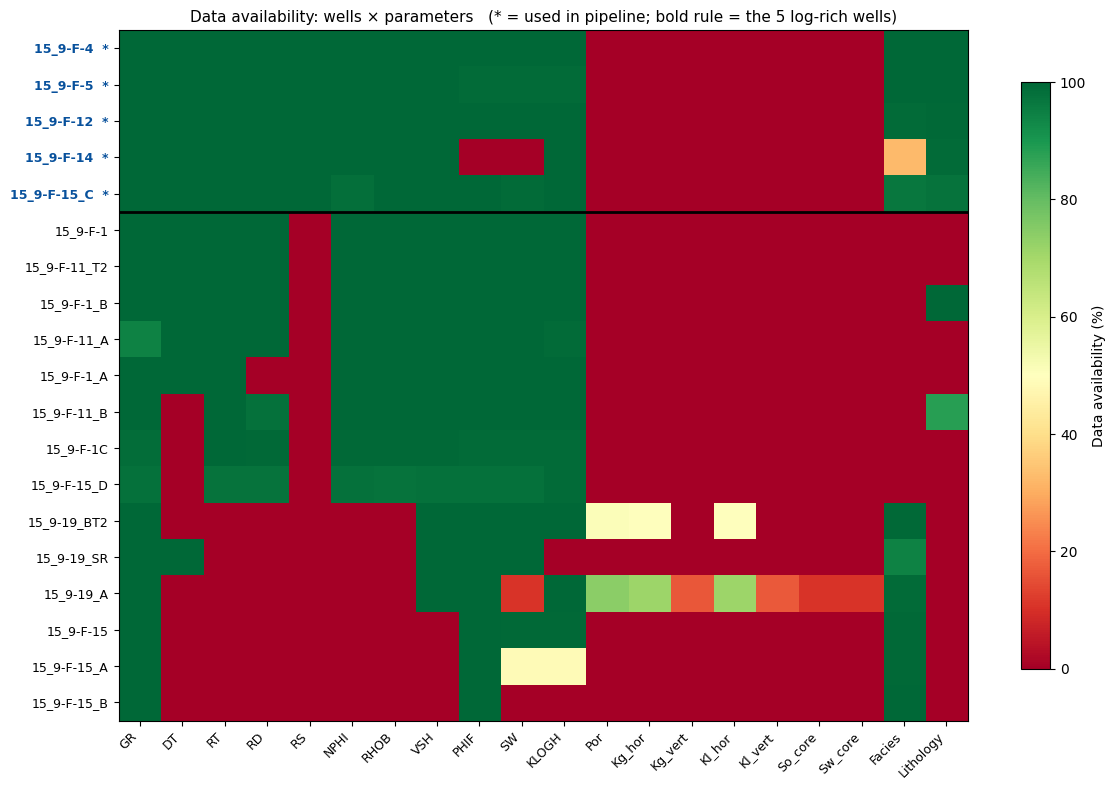

In [3]:
raw = pd.read_excel(DATA)                     # ALL rows / ALL wells (dfL above keeps only labelled rows)

LOG_COLS  = [GR, DT, RT, RD, RS, NPHI, RHOB, VSH, PHIF, SW, KLOGH, POR]
LOG_LBL   = ["GR", "DT", "RT", "RD", "RS", "NPHI", "RHOB", "VSH", "PHIF", "SW", "KLOGH", "Por"]
CORE_COLS = ["Kg, hor_Cropped", "Kg, vert_Cropped", "Kl, hor_Cropped", "Kl, vert_Cropped", "So_Core_Cropped", "Sw_Core_Cropped"]
CORE_LBL  = ["Kg_hor", "Kg_vert", "Kl_hor", "Kl_vert", "So_core", "Sw_core"]
cols   = LOG_COLS + CORE_COLS + [TARGET, LITHO]
labels = LOG_LBL + CORE_LBL + ["Facies", "Lithology"]

avail = raw.groupby(WELL)[cols].apply(lambda g: 100.0 * g.notna().mean())     # % present per well/param
log_avail = avail[LOG_COLS].mean(axis=1)
others = sorted([w for w in avail.index if w not in LOGRICH], key=lambda w: -log_avail[w])
order = [w for w in LOGRICH if w in avail.index] + others
avail = avail.loc[order]

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(avail.values, aspect="auto", cmap="RdYlGn", vmin=0, vmax=100)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(order)))
yt = ax.set_yticklabels([w + ("  *" if w in LOGRICH else "") for w in order], fontsize=9)
for t, w in zip(yt, order):
    if w in LOGRICH:
        t.set_fontweight("bold"); t.set_color("#08519c")
ax.axhline(len(LOGRICH) - 0.5, color="black", lw=2)             # rule under the 5 used wells
ax.set_title("Data availability: wells \u00d7 parameters   (* = used in pipeline; "
             "bold rule = the 5 log-rich wells)", fontsize=11)
fig.colorbar(im, ax=ax, label="Data availability (%)", shrink=0.85)
fig.tight_layout(); plt.show()

**2. Per-well facies representation.** Of the 19 wells, **11 carry a facies log**; the bar chart shows each well's facies make-up (raw 9-class scheme, fractions stacked, sample counts annotated). The 5 wells we actually use are bold and to the left of the dashed line.

Some expectations before seeing any score:

- The facies mix is **strongly imbalanced and well-dependent**. Tidal Channel (3), Tidal Bar (0) and Mouthbar (4) dominate; Offshore (2), Marsh (6) and the Tidal-Flat classes (7, 8) are rare almost everywhere. After the Step 3 merge, these rare muddy classes collapse into the single **Seal** class, which is still only ~4% of samples. We should expect low seal recall and treat seal detection as the hardest sub-task.
- Each well has a **different dominant facies** (e.g. F-12 is channel-heavy, F-15_C is more mixed). Because we evaluate blind, one well at a time, a well whose facies proportions differ most from the training pool is the hardest to predict. We expect the strongest scores on wells whose mix resembles the other four, and weaker scores where a well is idiosyncratic.
- F-15_C has by far the fewest samples (237), so its blind score is the noisiest.

These two plots together justify the modelling unit (whole wells), the 5-well selection, the facies merge, and the economic-tier evaluation used later.

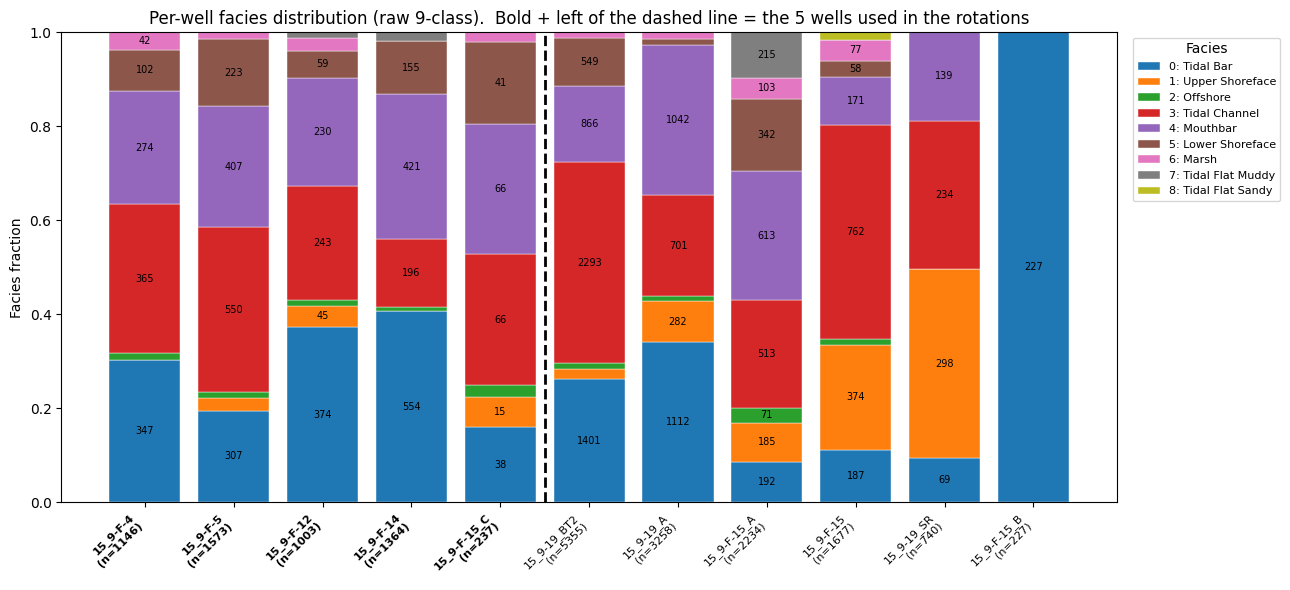

In [4]:
RAW_FACIES = {0: "Tidal Bar", 1: "Upper Shoreface", 2: "Offshore", 3: "Tidal Channel",
              4: "Mouthbar", 5: "Lower Shoreface", 6: "Marsh", 7: "Tidal Flat Muddy", 8: "Tidal Flat Sandy"}

lab = raw[raw[TARGET].notna()].copy()
lab[TARGET] = lab[TARGET].astype(int)
counts = lab.groupby([WELL, TARGET]).size().unstack(fill_value=0)
nrows = counts.sum(axis=1)
others = sorted([w for w in counts.index if w not in LOGRICH], key=lambda w: -nrows[w])
order = [w for w in LOGRICH if w in counts.index] + others
counts = counts.loc[order]
frac = counts.div(counts.sum(axis=1), axis=0)
fac_ids = sorted(counts.columns)

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(order)); bottom = np.zeros(len(order))
for f in fac_ids:
    vals = frac[f].values
    ax.bar(x, vals, bottom=bottom, color=plt.cm.tab10(f % 10),
           label=f"{f}: {RAW_FACIES[f]}", edgecolor="white", lw=0.3)
    for xi in range(len(order)):
        if vals[xi] > 0.03:
            ax.text(xi, bottom[xi] + vals[xi] / 2, str(int(counts[f].values[xi])),
                    ha="center", va="center", fontsize=7)
    bottom += vals
ax.set_xticks(x)
xt = ax.set_xticklabels([f"{w}\n(n={int(nrows[w])})" for w in order], rotation=45, ha="right", fontsize=8)
for t, w in zip(xt, order):
    if w in LOGRICH:
        t.set_fontweight("bold")
ax.axvline(len(LOGRICH) - 0.5, color="black", lw=2, ls="--")
ax.set_ylabel("Facies fraction"); ax.set_ylim(0, 1)
ax.set_title("Per-well facies distribution (raw 9-class).  Bold + left of the dashed line = the 5 wells used in the rotations")
ax.legend(title="Facies", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
fig.tight_layout(); plt.show()

### Sparse, uneven data: uncertainty that originates in the data

Across the Volve field, log coverage is **heterogeneous**. The lollipop chart below contrasts two views of each curve: the filled dot is its coverage inside the 5 log-rich wells we model, the hollow dot is its coverage field-wide (all 11 labelled wells). The gap between the two dots is the heterogeneity. Gamma-ray is everywhere, but the measured resistivity (RT/RD/RS), sonic (DT) and density/neutron curves are complete only in the log-rich wells and partial field-wide; core measurements (permeability, core saturations) are scarce everywhere; and PHIF/SW are actually lower in the log-rich set than field-wide; that dip is the F-14 gap we repair in Step 2b.

This matters for prediction quality: where curves are missing or partial, the inputs that separate two facies may simply not exist at that depth, so some labels become genuinely ambiguous. A meaningful part of the model's uncertainty therefore originates in the data itself, not in the algorithm. This is why we (a) restrict to the log-rich wells, (b) impute F-14's PHIF/SW from the curves it does have (Step 2b), and (c) report uncertainty and economic tolerance alongside raw accuracy.

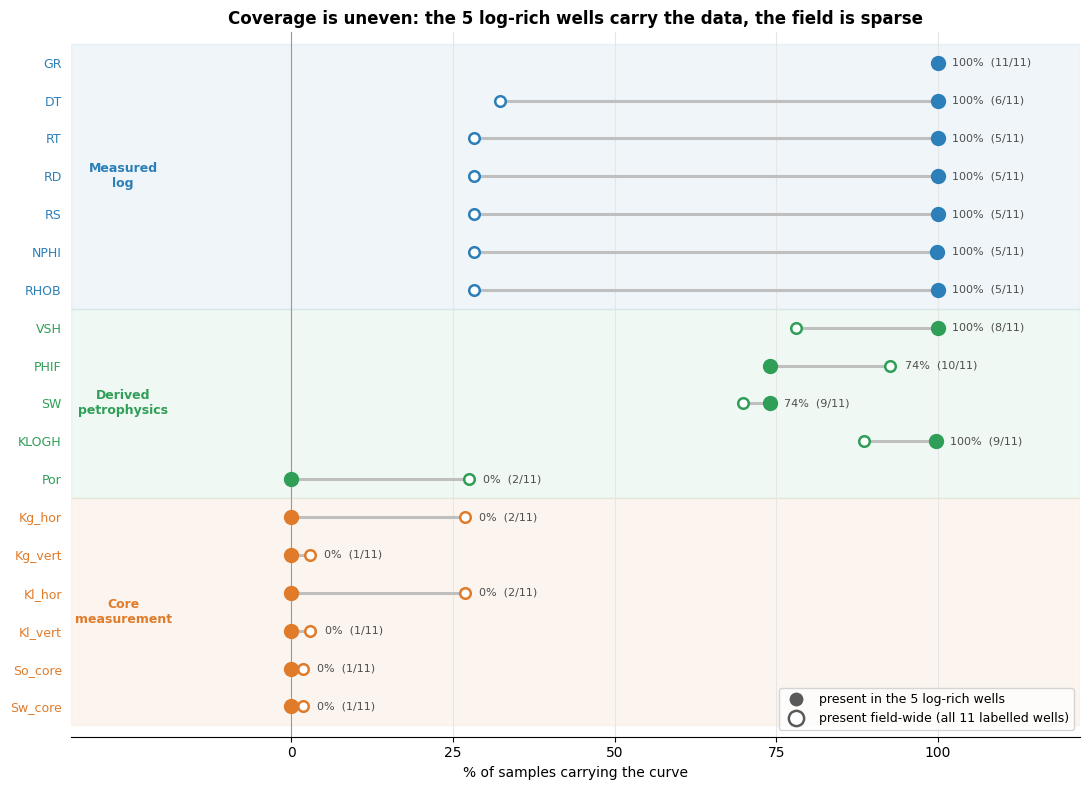

In [5]:
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

allcols = LOG_COLS + CORE_COLS
alllbl  = LOG_LBL + CORE_LBL
grp     = ["Measured log"] * 7 + ["Derived petrophysics"] * 5 + ["Core measurement"] * 6
gcolor  = {"Measured log": "#2c7fb8", "Derived petrophysics": "#2f9e57", "Core measurement": "#e07b2a"}

rich       = lab[lab[WELL].isin(LOGRICH)]                                       # the 5 wells we model
field_pct  = np.array([100.0 * lab[c].notna().mean()  for c in allcols])       # all 11 labelled wells
rich_pct   = np.array([100.0 * rich[c].notna().mean() for c in allcols])       # 5 log-rich wells
n_wells    = np.array([int(lab.groupby(WELL)[c].apply(lambda s: s.notna().any()).sum()) for c in allcols])
y = np.arange(len(allcols))[::-1]

fig, ax = plt.subplots(figsize=(11, 8))
for g in dict.fromkeys(grp):                                                   # shaded band + section label per group
    idx = [i for i, gg in enumerate(grp) if gg == g]
    ax.axhspan(y[idx[-1]] - 0.5, y[idx[0]] + 0.5, color=gcolor[g], alpha=0.07, zorder=0)
    ax.text(-26, (y[idx[0]] + y[idx[-1]]) / 2, g.replace(" ", "\n"), va="center", ha="center",
            fontsize=9, color=gcolor[g], fontweight="bold")

for yi, fp, rp, g in zip(y, field_pct, rich_pct, grp):                         # lollipop: field-wide -> log-rich
    ax.plot([fp, rp], [yi, yi], color="0.75", lw=2.2, zorder=1)
    ax.scatter(fp, yi, s=58, facecolors="white", edgecolors=gcolor[g], linewidths=1.8, zorder=2)
    ax.scatter(rp, yi, s=100, color=gcolor[g], zorder=3)
for yi, rp, nw in zip(y, rich_pct, n_wells):
    ax.text(max(rp, field_pct[list(y).index(yi)]) + 2.2, yi, f"{rp:.0f}%  ({nw}/11)",
            va="center", ha="left", fontsize=8, color="0.3")

ax.set_yticks(y); ax.set_yticklabels(alllbl, fontsize=9)
for tick, g in zip(ax.get_yticklabels(), grp):
    tick.set_color(gcolor[g])
ax.set_xlim(-34, 122); ax.set_xticks([0, 25, 50, 75, 100])
ax.set_ylim(-0.8, len(allcols) - 0.2)
ax.set_xlabel("% of samples carrying the curve")
ax.set_title("Coverage is uneven: the 5 log-rich wells carry the data, the field is sparse",
             fontsize=12, fontweight="bold")
ax.grid(axis="x", color="0.9", zorder=0); ax.set_axisbelow(True)
ax.axvline(0, color="0.6", lw=0.8)
for sp in ["top", "right", "left"]:
    ax.spines[sp].set_visible(False)
ax.tick_params(left=False)
leg = [Line2D([0], [0], marker="o", color="w", markerfacecolor="0.35", markersize=11, label="present in the 5 log-rich wells"),
       Line2D([0], [0], marker="o", color="w", markerfacecolor="white", markeredgecolor="0.35",
              markeredgewidth=1.8, markersize=11, label="present field-wide (all 11 labelled wells)")]
ax.legend(handles=leg, loc="lower right", fontsize=9, frameon=True)
fig.tight_layout(); plt.show()

### Logs overlap: facies are hard to separate by eye

Even where every curve is present, the facies are not cleanly separable in the raw logs. The cross-plots below show, for the 5 log-rich wells, the kernel-density contours of each (merged) facies in classic discrimination spaces: GR–DT, NPHI–RHOB and GR–RHOB. If facies occupied distinct regions, the coloured blobs would sit apart; instead they pile on top of one another.

A geologist cannot reliably assign a facies from a single depth's log readings, and neither can a point-wise classifier. This is the core motivation for the rest of the workflow: rather than classify each depth in isolation, we engineer multi-scale vertical-context features (Step 4) that capture the shape and texture of the log curves over geological intervals, the information a human actually uses to read a facies succession. That is what lets the model pull these overlapping clouds apart.

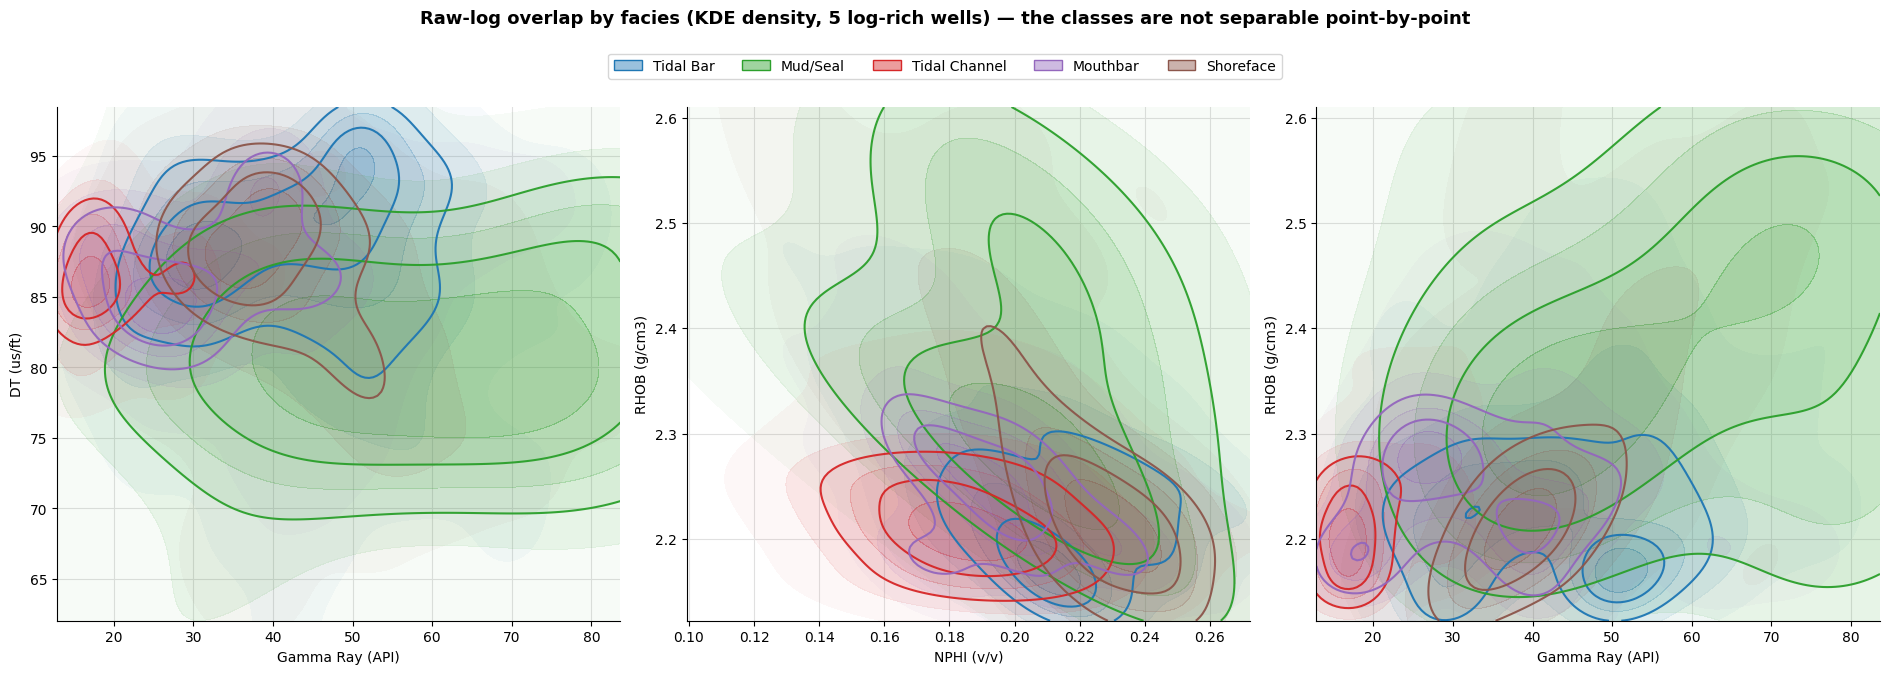

In [6]:
from scipy.stats import gaussian_kde
from matplotlib.colors import to_rgba, LinearSegmentedColormap

MERGE_MAP = {1: 5, 6: 2, 7: 2, 8: 0}                          # 9 raw facies -> 5 classes (formalized in Step 3)
M_NAME = {0: "Tidal Bar", 2: "Mud/Seal", 3: "Tidal Channel", 4: "Mouthbar", 5: "Shoreface"}
M_CLASSES = [0, 2, 3, 4, 5]
def fcol(c):
    return plt.cm.tab10(int(c) % 10)
def shade(color):                                             # transparent -> facies colour (seaborn-style graduated fill)
    r, g, b, _ = to_rgba(color)
    return LinearSegmentedColormap.from_list("s", [(r, g, b, 0.0), (r, g, b, 0.45)])

dd = raw[raw[TARGET].notna() & raw[WELL].isin(LOGRICH)].copy()
dd["_m"] = dd[TARGET].astype(int).replace(MERGE_MAP)

pairs = [(GR, "Gamma Ray (API)", DT, "DT (us/ft)"),
         (NPHI, "NPHI (v/v)", RHOB, "RHOB (g/cm3)"),
         (GR, "Gamma Ray (API)", RHOB, "RHOB (g/cm3)")]

fill_levels = np.linspace(0.05, 1.0, 7)                       # density normalised to its peak, threshold 5%
line_levels = np.linspace(0.05, 1.0, 4)[1:]
fig, axes = plt.subplots(1, 3, figsize=(19, 6.2))
for ax, (xc, xl, yc, yl) in zip(axes, pairs):
    ax.set_facecolor("white")
    xv = dd[xc].replace([np.inf, -np.inf], np.nan).dropna()
    yv = dd[yc].replace([np.inf, -np.inf], np.nan).dropna()
    xlim = np.percentile(xv, [1, 99]); ylim = np.percentile(yv, [1, 99])
    gx, gy = np.linspace(*xlim, 140), np.linspace(*ylim, 140)
    XX, YY = np.meshgrid(gx, gy); grid = np.vstack([XX.ravel(), YY.ravel()])
    for c in M_CLASSES:
        sub = dd[dd["_m"] == c]
        x, y = sub[xc].values, sub[yc].values
        m = np.isfinite(x) & np.isfinite(y)
        x, y = x[m], y[m]
        if len(x) < 50:
            continue
        try:
            ZZ = gaussian_kde(np.vstack([x, y]))(grid).reshape(XX.shape)
        except Exception:
            continue
        Zn = ZZ / ZZ.max()
        ax.contourf(XX, YY, Zn, levels=fill_levels, cmap=shade(fcol(c)))
        ax.contour(XX, YY, Zn, levels=line_levels, colors=[fcol(c)], linewidths=1.5, alpha=0.95)
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.grid(True, color="0.88"); ax.set_axisbelow(True)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)

fig.legend(handles=[mpatches.Patch(facecolor=to_rgba(fcol(c), 0.45), edgecolor=fcol(c), label=M_NAME[c]) for c in M_CLASSES],
           loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02), frameon=True, fontsize=10)
fig.suptitle("Raw-log overlap by facies (KDE density, 5 log-rich wells) \u2014 the classes are not separable point-by-point",
             y=1.08, fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

## Step 2b: Predict F-14's missing PHIF & SW (regression imputation)

Well **F-14 has no PHIF or SW at all**. Rather than leave them blank (and let the model fill a column median at fit time), we predict them from the logs F-14 does have, so PHIF and SW become real, usable features for F-14.

**How:** two `RandomForestRegressor`s (300 trees, depth 25) are trained on all other wells (rows with valid PHIF/SW), using the 9 logs F-14 shares (GR, DT, RT, RD, RS, NPHI, RHOB, VSH, KLOGH) plus one-hot lithology as predictors, then applied to F-14. We report each model's leave-one-well-out R² as a quality check: each CV fold holds out an entire well, so the score measures transfer to an unseen well, which is the actual F-14 task. A shuffled KFold would be optimistic here, because depth-adjacent (autocorrelated) samples from the same well would land in both train and validation folds.

**Leakage note:** this step maps *logs -> PHIF/SW*; it never sees the facies target, so it does not leak the quantity we ultimately predict. It is a one-time data-preparation step.

> **Reading the printed R².** The PHIF score is modest and the SW score is strongly negative. This happened because one training well (`15_9-19_A`) stores SW on a different scale (values up to ~63 instead of 0–1), which wrecks any blind-transfer score it participates in. **Appendix A2** dissects this, compares the RF imputation against direct petrophysical calculation (density porosity + Archie), and shows that the facies results downstream are essentially insensitive to the imputation route (thanks to the per-well rank normalization of Step 4).

**Methodology at a glance**

| Aspect | Choice |
|---|---|
| Task | Regression imputation: predict PHIF & SW for well F-14 (which has none) |
| Training data | All labelled wells except F-14 with valid PHIF/SW; F-14 is fully held out by construction |
| Predictors | 9 shared logs (GR, DT, RT, RD, RS, NPHI, RHOB, VSH, KLOGH) + one-hot lithology; NaNs filled with training-well medians |
| Model | `RandomForestRegressor(n_estimators=300, max_depth=25, min_samples_split=5, min_samples_leaf=2)`, one per target (PHIF, SW); hyperparameters fixed, no tuning loop |
| Rotation | None; a single fit on all training wells, applied once to F-14 |
| CV approach | `LeaveOneGroupOut` grouped by well (each fold holds out one entire well), used only to report R², the estimate of transfer to an unseen well. The final model is refit on all training wells |
| Target leakage | Facies target never used as a predictor |

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut

def impute_f14_phif_sw(data):
    """Predict F-14's missing PHIF & SW from the logs it has (+ lithology). Logs only -> no facies leakage."""
    out = data.copy()
    f14 = "15_9-F-14"
    pred_logs = [GR, DT, RT, RD, RS, NPHI, RHOB, VSH, KLOGH]
    litho_cols = []
    for v in (0.0, 2.0, 3.0, 4.0):                       # one-hot lithology as extra predictors
        col = f"_lith{int(v)}"
        out[col] = (out[LITHO] == v).astype(float)
        litho_cols.append(col)
    predictors = pred_logs + litho_cols

    tr = (out[WELL] != f14) & out[PHIF].notna() & out[SW].notna()
    te = out[WELL] == f14
    med = out.loc[tr, predictors].median()
    Xtr = out.loc[tr, predictors].fillna(med)
    Xte = out.loc[te, predictors].fillna(med)

    # leave-one-well-out CV: each fold holds out a full well, so the R2 reflects
    # transfer to an unseen well (the actual task for F-14) rather than
    # interpolation between depth-adjacent samples of known wells
    groups_tr = out.loc[tr, WELL].values
    logo = LeaveOneGroupOut()
    for tgt in (PHIF, SW):
        reg = RandomForestRegressor(n_estimators=300, max_depth=25, min_samples_split=5,
                                    min_samples_leaf=2, random_state=42, n_jobs=-1)
        ytr = out.loc[tr, tgt]
        r2 = cross_val_score(reg, Xtr, ytr, cv=logo, groups=groups_tr, scoring="r2").mean()
        reg.fit(Xtr, ytr)
        out.loc[te, tgt] = reg.predict(Xte)
        print(f"  {('PHIF' if tgt==PHIF else 'SW'):4s}: trained on {int(tr.sum())} rows "
              f"({len(np.unique(groups_tr))} wells), leave-one-well-out R2={r2:.3f}, "
              f"predicted {int(te.sum())} F-14 rows (mean={out.loc[te, tgt].mean():.4f})")
    return out.drop(columns=litho_cols)

print("Predicting F-14 PHIF & SW (RandomForestRegressor on other wells):")
dfL = impute_f14_phif_sw(dfL)
df = dfL[dfL[WELL].isin(LOGRICH)].copy()                 # refresh the 5-well view with filled F-14
print("\nF-14 PHIF/SW NaN after imputation:",
      int(dfL.loc[dfL[WELL] == '15_9-F-14', [PHIF, SW]].isna().sum().sum()))

Predicting F-14 PHIF & SW (RandomForestRegressor on other wells):


  PHIF: trained on 13138 rows (9 wells), leave-one-well-out R2=0.175, predicted 1364 F-14 rows (mean=0.2245)


  SW  : trained on 13138 rows (9 wells), leave-one-well-out R2=-12735.726, predicted 1364 F-14 rows (mean=0.2383)

F-14 PHIF/SW NaN after imputation: 0


## Step 3: Merge facies into 5 decision-useful classes

The facies follow the Hugin Formation depositional model of **Kieft et al. (2011)**: a tide-dominated transgressive system (tidal channels, tidal bars, tidal flats) passing into wave-/river-dominated regressive units (prograding mouthbars, shoreface), with offshore mudstones as the distal, fine-grained component.

The raw target has 9 facies, several of them very rare (a few hundred samples in total). Rare classes are nearly impossible to learn blind and add noise, so we merge rare or genetically-related members of Kieft et al.'s scheme:

```
1 Upper Shoreface  -> 5  Shoreface
6 Marsh            -> 2  Mud / Seal
7 Tidal Flat Muddy -> 2  Mud / Seal
8 Tidal Flat Sandy -> 0  Tidal Bar
```

That leaves **5 classes** `{0, 2, 3, 4, 5}`, each mapped to a reservoir-quality tier and an economic value weight used later for scoring:

| Class | Facies | Tier | Value |
|---|---|---|---|
| 0 | Tidal Bar | Excellent | 2.0 |
| 3 | Tidal Channel | Excellent | 2.0 |
| 4 | Mouthbar | Good | 1.5 |
| 5 | Shoreface | Good | 1.5 |
| 2 | Mud / Seal | Seal | 0.5 |

These groupings respect Kieft et al.'s (2011) facies associations: fine-grained tidal-flat-muddy / marsh / offshore deposits all act as seals (-> 2), sandy tidal-flat material is petrophysically like the tidal-bar sands (-> 0), and the shoreface members merge into one shoreface class (-> 5).

In [8]:
MERGE    = {1: 5, 6: 2, 7: 2, 8: 0}                       # -> {0,2,3,4,5}
PAY, SEAL = {0, 3, 4, 5}, {2}
TIER     = {0: "Excellent", 3: "Excellent", 4: "Good", 5: "Good", 2: "Seal"}
TIER_ORD = {"Excellent": 2, "Good": 1, "Seal": 0}
VALUE    = {0: 2.0, 3: 2.0, 4: 1.5, 5: 1.5, 2: 0.5}
CLASSES  = [0, 2, 3, 4, 5]                                # the 5 merged classes, fixed order

def merge_y(y):
    return y.replace(MERGE)

y_all = merge_y(dfL[TARGET].astype(int))   # merged labels for ALL labelled rows
y = y_all.loc[df.index]                    # merged labels for the 5 log-rich wells

print("merged class counts (5 log-rich wells):")
print(y.value_counts().sort_index().to_string())
print("\nclass -> tier -> value:")
for c in sorted(y.unique()):
    print(f"  {c}  {TIER[c]:9s}  value={VALUE[c]}")

merged class counts (5 log-rich wells):
Equinor_Facies_Cropped
0    1620
2     204
3    1420
4    1398
5     681

class -> tier -> value:
  0  Excellent  value=2.0
  2  Seal       value=0.5
  3  Excellent  value=2.0
  4  Good       value=1.5
  5  Good       value=1.5


## Step 3a: How thick are the facies, and how heterogeneous? 

Before engineering depth-context features we need to know the vertical scale of the geology we are trying to encode: the distribution of facies interval thicknesses, how variable they are (coefficient of variation), and how quickly the logs decorrelate with depth (variogram nugget/range). These numbers are what justify, or refute, the feature window choices of Step 4.

**Interval thickness (computed below, merged classes, 5 log-rich wells, ~67 cored intervals):**

| Facies | median | P10–P90 | CV |
|---|---|---|---|
| Mud/Seal | **~2.6 m** | 0.9–4.4 m | 0.55 |
| Shoreface | ~7.8 m | 1.6–20 m | 0.77 |
| Tidal Bar | ~9.5 m | 2.9–24 m | **0.96** |
| Mouthbar | ~13.7 m | 3.7–25 m | 0.69 |
| Tidal Channel | ~19.4 m | 5.6–36 m | 0.71 |

Pooled CV ≈ 0.93: thicknesses are strongly heterogeneous, spanning two orders of magnitude (sub-metre seals to >30 m channel complexes). The root cause of the heterogeneity is the bimodal architecture itself: thin heterolithic muds/seals (median 2.6 m) interbedded with thick stacked sand bodies (10–20 m): no single window size can represent both.

**Variograms (below, right panel):** the rank-GR semivariogram has an almost zero nugget (nugget/sill ≈ 0.02): the logs are vertically continuous and sample-to-sample "noise" is negligible, but the variance accumulates over metres to tens of metres: at ~1.3 m lag only ~30% of the sill is reached. The facies-indicator variograms put numbers on the two architectural scales: range ≈ 5 m for Mud/Seal, ≈ 14 m for Tidal Bar, matching the thickness table.

**Consequences for the features (Step 4):**

- An earlier version of this workflow computed GR slope/serration in sub-metre windows and degraded the model. The variogram explains why: at sub-metre lags the curve sits on the steep, low-variance part, a tiny window samples mostly within-bed variability, so derivative-type features amplify the (small but nonzero) short-lag fluctuation relative to the facies signal. The fix was to move every engineered feature to geological scales.
- The three context windows used in Step 4 are drawn on both panels: ~1.4 m sits just above the thinnest beds (only 7% of intervals are thinner, it resolves even the seals without aliasing them), ~7 m brackets the median sand body (~42% of intervals are thinner), and ~23 m spans the P90 (~88% thinner, a formation-scale trend window). The windows are not arbitrary: they tile the measured thickness distribution from its P10 to its P90.

facies intervals (5 log-rich wells): 67 total
                n  median   mean   p10    p90    std    CV
Tidal Bar      20    9.52  12.34  2.85  23.80  11.88  0.96
Mud/Seal       11    2.59   2.83  0.91   4.42   1.56  0.55
Tidal Channel  11   19.35  19.67  5.64  36.27  14.06  0.71
Mouthbar       15   13.72  14.20  3.69  24.60   9.84  0.69
Shoreface      10    7.77  10.38  1.63  19.66   7.98  0.77

pooled: median=8.2 m  CV=0.93
intervals thinner than  1.4 m (ctx9 (bed)        ):   7%
intervals thinner than  7.0 m (ctx49 (sand body) ):  42%
intervals thinner than 23.0 m (ctx151 (formation)):  88%

variogram summary (nugget = lag-1 gamma; sill = mean of last lags):
  GR (rank)                nugget/sill =  0.02   range ~  14.4 m
  indicator: Mud/Seal      nugget/sill =  0.07   range ~   4.8 m
  indicator: Tidal Bar     nugget/sill =  0.03   range ~  14.4 m


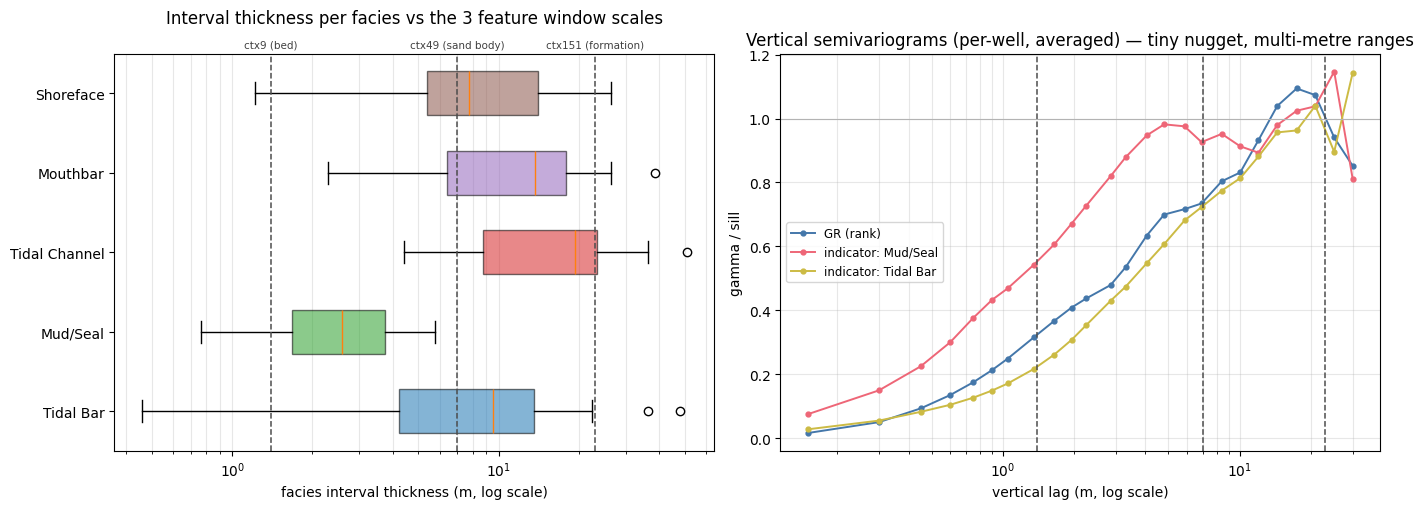

In [9]:
# Step 3a: facies interval thickness, heterogeneity (CV) and vertical variograms.

FAC_NAME = {0: "Tidal Bar", 2: "Mud/Seal", 3: "Tidal Channel", 4: "Mouthbar", 5: "Shoreface"}
WINDOW_M = {1.4: "ctx9 (bed)", 7.0: "ctx49 (sand body)", 23.0: "ctx151 (formation)"}


def facies_intervals(depths, labels, max_gap_factor=2.0):
    """Run-lengths of consecutive same-label samples -> intervals with thickness (m).
    Runs are broken at depth gaps > max_gap_factor x median step (labelled intervals
    are discontinuous). Reused by Step 10a for the scenario columns."""
    depths = np.asarray(depths, dtype=float)
    labels = np.asarray(labels)
    step = np.median(np.diff(depths)) if len(depths) > 1 else 0.15
    rows, start = [], 0
    for i in range(1, len(depths) + 1):
        if (i == len(depths) or labels[i] != labels[i - 1]
                or (depths[i] - depths[i - 1]) > max_gap_factor * step):
            rows.append({"facies": labels[start], "thickness_m": depths[i - 1] - depths[start] + step})
            start = i
    return pd.DataFrame(rows)


# --- interval thickness over the 5 log-rich wells (merged classes) ---
iv = []
for w, g in df.groupby(WELL, sort=False):
    t = facies_intervals(g[MD].values, y.loc[g.index].values)
    t["well"] = w
    iv.append(t)
iv = pd.concat(iv, ignore_index=True)

th_stats = iv.groupby("facies")["thickness_m"].agg(
    n="count", median="median", mean="mean",
    p10=lambda s: s.quantile(0.10), p90=lambda s: s.quantile(0.90), std="std")
th_stats["CV"] = th_stats["std"] / th_stats["mean"]
th_stats.index = [FAC_NAME[int(c)] for c in th_stats.index]
print(f"facies intervals (5 log-rich wells): {len(iv)} total")
print(th_stats.round(2).to_string())
print(f"\npooled: median={iv['thickness_m'].median():.1f} m  "
      f"CV={iv['thickness_m'].std()/iv['thickness_m'].mean():.2f}")
for m_w in WINDOW_M:
    print(f"intervals thinner than {m_w:4.1f} m ({WINDOW_M[m_w]:18s}): "
          f"{(iv['thickness_m'] < m_w).mean()*100:3.0f}%")


# --- vertical semivariograms (GR rank + facies indicators) ---
def semivariogram(vals, lags):
    v = np.asarray(vals, dtype=float)
    out = []
    for h in lags:
        dlt = v[h:] - v[:-h]
        dlt = dlt[~np.isnan(dlt)]
        out.append(0.5 * np.mean(dlt ** 2) if len(dlt) else np.nan)
    return np.array(out)


LAGS = np.unique(np.round(np.geomspace(1, 200, 30)).astype(int))
STEP_M = 0.15
gam = {}
gr_curves = []
for w, g in df.groupby(WELL, sort=False):
    gr_rank = g[GR].interpolate(limit_direction="both").rank(pct=True).values
    gr_curves.append(semivariogram(gr_rank, LAGS))
gam["GR (rank)"] = np.nanmean(np.vstack(gr_curves), axis=0)
for c in (2, 0):
    ind = []
    for w, g in df.groupby(WELL, sort=False):
        ind.append(semivariogram((y.loc[g.index].values == c).astype(float), LAGS))
    gam[f"indicator: {FAC_NAME[c]}"] = np.nanmean(np.vstack(ind), axis=0)

print("\nvariogram summary (nugget = lag-1 gamma; sill = mean of last lags):")
for name, gv in gam.items():
    sill = np.nanmean(gv[-5:])
    reach_idx = np.argmax(gv >= 0.95 * sill)
    print(f"  {name:24s} nugget/sill = {gv[0]/sill:5.2f}   range ~ {LAGS[reach_idx]*STEP_M:5.1f} m")

# --- figure: thickness distributions + variograms, with the 3 window scales overlaid ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]
order = CLASSES
data = [iv.loc[iv["facies"] == c, "thickness_m"].values for c in order]
bp = ax.boxplot(data, vert=False, tick_labels=[FAC_NAME[c] for c in order],
                showfliers=True, patch_artist=True, widths=0.55)
for patch, c in zip(bp["boxes"], order):
    patch.set_facecolor(plt.cm.tab10(int(c) % 10)); patch.set_alpha(0.55)
for m_w, lbl in WINDOW_M.items():
    ax.axvline(m_w, color="0.3", ls="--", lw=1.1)
    ax.text(m_w, 1.01, lbl, transform=ax.get_xaxis_transform(), rotation=0,
            fontsize=7.5, ha="center", va="bottom", color="0.25")
ax.set_xscale("log")
ax.set_xlabel("facies interval thickness (m, log scale)")
ax.set_title("Interval thickness per facies vs the 3 feature window scales", pad=22)
ax.grid(axis="x", alpha=0.3, which="both"); ax.set_axisbelow(True)

ax = axes[1]
for (name, gv), color in zip(gam.items(), ["#4477aa", "#ee6677", "#ccbb44"]):
    sill = np.nanmean(gv[-5:])
    ax.plot(LAGS * STEP_M, gv / sill, "o-", ms=3.5, lw=1.4, color=color, label=name)
for m_w in WINDOW_M:
    ax.axvline(m_w, color="0.3", ls="--", lw=1.1)
ax.axhline(1.0, color="0.7", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel("vertical lag (m, log scale)"); ax.set_ylabel("gamma / sill")
ax.set_title("Vertical semivariograms (per-well, averaged) \u2014 tiny nugget, multi-metre ranges")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

## Step 4: Feature engineering

A single log reading at one depth isn't enough; geology lives in how logs change with depth. We build a feature set of ~117 columns, grouped into families. Two design rules make everything leakage-safe (more on this in Step 4a):

- **Everything is computed per well** (`groupby(WELL)`), so a feature for one well never borrows values from another.
- **Normalization is per-well**: each log is mapped to its *own well's* distribution, so the blind well is standardized by its own statistics, not the training wells'.

### Why per-well **rank** normalization (not z-score)?

Each log is normalized with a per-well rank transform (`rank(pct=True)`): every sample is replaced by its quantile within its own well, mapping the curve to (0, 1]. A z-score assumes the log is roughly Gaussian, but several curves are strongly skewed / heavy-tailed (resistivities RT/RD/RS and permeability KLOGH are ~log-normal), so a few extreme values dominate a well's mean/std and the "same" rock ends up at different z-values in different wells. The rank transform is distribution-free: it removes per-well calibration, scale *and shape* differences, which is exactly what must transfer to a blind well.

This choice was validated blind (leave-one-well-out, all else equal):

| normalization | pooled facies acc (seeds 0 / 7 / 42) | macro-F1 | tier acc |
|---|---|---|---|
| per-well z-score | 0.552 / 0.548 / 0.555 | 0.458 | 0.642 |
| per-well rank | 0.577 / 0.577 / 0.577 | 0.493 | 0.645 |

Two checks: (1) a nested selection (choosing z-score vs rank per fold using training wells only) prefers rank in 3/5 folds and still beats the z-score pipeline pooled (0.574 vs 0.555); (2) a McNemar paired test on the pooled blind predictions gives p ≈ 1×10⁻⁵, so the improvement is statistically significant, not seed luck. (Ablations also tried and *rejected*: centered context windows −5 pp, extra ~4 m scale, rolling-range stats, serration on more logs, gradient-boosting models; none beat this configuration blind.)

| Family | # | What it is | Why it helps |
|---|---|---|---|
| **base logs (rank)** | 12 | each log rank-normalized within its well | removes per-well offset/scale/shape |
| **missingness flags** | 12 | 1/0 "was this log missing here" | lets the model react to data gaps |
| **multi-scale context** | 72 | rolling mean & std of each z-log at windows 9 / 49 / 151 (~1.4 m / 7 m / 23 m) | bed-, sand-body-, formation-scale trends; the key block (Step 4a) |
| **serration / shape** | 8 | GR path-length vs net-displacement, gradient-reversal rate, gradient std, fining/coarsening trend (windows 49/151) | clean vs interbedded / fining-up vs coarsening-up sands |
| **opposition (ND)** | 2 | rolling `-(dNPHI·dRHOB)` (windows 9/49) | neutron-density crossover cue |
| **geo-scale engineered** | 7 | meter-aware GR_Slope, GR_Serration, OppositionIndex, NTG_Slope, AI_Slope, BaseSharpness, RelPos | explicit geological shape descriptors |
| **lithology one-hot** | 4 | encoded rock-type label | small lift once data is log-complete |

### Engineered-feature definitions (formulas + windows + justification)

Notation: `z` = per-well rank-normalized log (the `q::` columns); `Δ` = first difference between adjacent samples; `w` = window in samples (≈ metres at the ~0.15 m step); `ε` guards division. Every window is computed **within each well**. Facies attributions follow Kieft et al. (2011).

**Serration / shape, on GR, windows `w` = 49 / 151 (~7 m / ~23 m):**

| Feature | Formula | Captures / justification |
|---|---|---|
| `serr_ratio{w}` | `Σ_w|ΔGR_z| / (|GR_z(d) − GR_z(d−w)| + ε)` | path length ÷ \|net displacement\|: ≈1 for smooth/monotonic, ≫1 for serrated heterolithics -> separates blocky **tidal-bar** sand from interbedded tidal-flat/channel fill |
| `serr_rev{w}` | `mean_w( 1[ sign(ΔGR_z) ≠ sign(ΔGR_z) prev ] )` | gradient-reversal rate = "spikiness" of GR |
| `serr_gstd{w}` | `std_w( ΔGR_z )` | local gradient variability |
| `shape_trend{w}` | `(GR_z(d) − GR_z(d−w)) / w` | signed trend: + = fining-up (channel), − = coarsening-up (mouthbar/shoreface) |

**Opposition (neutron–density), windows `w` = 9 / 49 (~1.4 m / ~7 m):**

| Feature | Formula | Captures / justification |
|---|---|---|
| `opp{w}::ND` | `mean_w( −(ΔNPHI_z · ΔRHOB_z) )` | neutron & density move in opposition in clean/gas sand and together in shale -> reservoir-sand vs mud discriminator |

**Geo-scale engineered, meter-aware (metres converted to samples via each well's median depth step Δz, so they are comparable across wells regardless of sampling):**

| Feature | Window | Formula | Captures / justification (Kieft 2011) |
|---|---|---|---|
| `geo_GR_Slope` | 3 m | central diff `[GR(d+h)−GR(d−h)] / [MD(d+h)−MD(d−h)]`, `h=½·win(3 m)` | GR boundary trend dGR/dMD |
| `geo_GR_Serr` | 3 m | `Σ_3m|ΔGR| / (|GR(d)−GR(d−3m)| + ε)` | metre-calibrated serration (heterolithic vs clean) |
| `geo_Opp` | 3 m | `mean_3m( −(ΔGR · ΔPor) )`, `Por = PHIF` (NPHI fallback) | GR–porosity opposition -> sand vs mud |
| `geo_NTG_Slope` | 5 m | central slope of net-to-gross proxy `1 − VSH` | upward coarsening/fining of net sand -> mouthbar/shoreface vs channel |
| `geo_AI_Slope` | 3 m | central slope of impedance proxy `AI = RHOB / DT` | acoustic-impedance contrast at bed boundaries |
| `geo_BaseSharp` | 1.5 m | `max_1.5m( |ΔGR / ΔMD| )` | sharp erosive base (tidal channel) vs gradational base (mouthbar) |
| `geo_RelPos` | peaks ≥2 m apart | fractional position between adjacent GR maxima (shale breaks), peaks from Savitzky–Golay-smoothed GR (window 41, order 2) | relative height within a sand body (0 base -> 1 top) |

**Why these windows.** Sizes span the bed scale (1.5–3 m), the sand-body scale (5–7 m) and the parasequence/formation scale (23 m), matching the Hugin Formation sand-body thicknesses described by Kieft et al. (2011). Combining shape (slopes, trend), texture (serration, gradient std) and lithology-contrast (opposition, NTG, AI) lets the model reproduce the diagnostic log motifs Kieft uses: *sharp-based fining-up* = tidal channel, *gradational coarsening-up* = mouthbar/shoreface, *thick blocky* = tidal bar, *heterolithic low-NTG* = tidal flat (merged to seal).

The two functions below build all of it. A final `assert` guarantees no leakage column leaked into the feature matrix.

In [10]:
def build_features(df):
    """All log-derived features, computed strictly within each well. Returns (X, groups)."""
    g = df.groupby(WELL, sort=False)
    def gw(s):                                    # group a Series by well (keeps row index)
        return s.groupby(df[WELL], sort=False)
    # fill small gaps within each well only (no labels, no other wells)
    interp = {c: g[c].transform(lambda s: s.interpolate(limit_direction="both")) for c in LOG_FEATURES}

    feats, groups = {}, {k: [] for k in
                         ["static_rank", "missing", "context_multi", "serration", "opposition", "lithology"]}

    # --- base logs: per-well rank (quantile) normalization + missingness flag ---
    # rank(pct=True) maps each log to its within-well CDF in (0,1]: distribution-free,
    # robust to the heavy-tailed / log-normal curves (RT, RD, RS, KLOGH) where a z-score
    # is dominated by outliers. Validated blind: +2.2 pp pooled accuracy vs z-score (Step 4 text).
    zmap = {}
    for c in LOG_FEATURES:
        z = gw(interp[c]).transform(lambda s: s.rank(pct=True))
        zmap[c] = z
        feats[f"q::{c}"] = z.values;                         groups["static_rank"].append(f"q::{c}")
        feats[f"miss::{c}"] = df[c].isna().astype(np.float32).values; groups["missing"].append(f"miss::{c}")

    # --- multi-scale context: rolling mean (trend) & std (texture) at 3 depth scales ---
    for w in (9, 49, 151):
        for c in LOG_FEATURES:
            z = zmap[c]
            feats[f"ctx{w}_mean::{c}"] = gw(z).transform(lambda s: s.rolling(w, min_periods=1).mean()).values
            feats[f"ctx{w}_std::{c}"]  = gw(z).transform(lambda s: s.rolling(w, min_periods=1).std()).values
            groups["context_multi"] += [f"ctx{w}_mean::{c}", f"ctx{w}_std::{c}"]

    # --- GR serration + fining/coarsening trend ---
    grz = zmap[GR]
    grad = gw(grz).transform(lambda s: s.diff())
    abs_grad = grad.abs()
    sign = np.sign(grad)
    rev = (sign != gw(sign).transform(lambda s: s.shift(1))).astype(float)
    for w in (49, 151):
        pathlen = gw(abs_grad).transform(lambda s: s.rolling(w, min_periods=2).sum())
        netdisp = (grz - gw(grz).transform(lambda s: s.shift(w))).abs()
        feats[f"serr_ratio{w}::GR"] = (pathlen / (netdisp + EPS)).values
        feats[f"serr_rev{w}::GR"]   = gw(rev).transform(lambda s: s.rolling(w, min_periods=2).mean()).values
        feats[f"serr_gstd{w}::GR"]  = gw(grad).transform(lambda s: s.rolling(w, min_periods=2).std()).values
        feats[f"shape_trend{w}::GR"] = ((grz - gw(grz).transform(lambda s: s.shift(w))) / w).values
        groups["serration"] += [f"serr_ratio{w}::GR", f"serr_rev{w}::GR", f"serr_gstd{w}::GR", f"shape_trend{w}::GR"]

    # --- neutron-density opposition index ---
    dnphi = gw(zmap[NPHI]).transform(lambda s: s.diff())
    drhob = gw(zmap[RHOB]).transform(lambda s: s.diff())
    opp = -(dnphi * drhob)
    for w in (9, 49):
        feats[f"opp{w}::ND"] = gw(opp).transform(lambda s: s.rolling(w, min_periods=2).mean()).values
        groups["opposition"].append(f"opp{w}::ND")

    # --- one-hot lithology ---
    for v in (0.0, 2.0, 3.0, 4.0):
        feats[f"lith::{int(v)}"] = (df[LITHO] == v).astype(np.float32).values
        groups["lithology"].append(f"lith::{int(v)}")

    X = pd.DataFrame(feats, index=df.index)
    for bad in LEAK:                                  # leakage guard
        assert not any(bad in c for c in X.columns), f"LEAK {bad}"
    return X, groups


def _win(step, meters):
    return max(5, int(round(meters / max(step, 1e-3))))


def build_geo_features(df):
    """7 meter-aware engineered features (per well), independent of sampling rate."""
    out = {k: np.full(len(df), np.nan) for k in
           ["geo_GR_Slope", "geo_GR_Serr", "geo_Opp", "geo_NTG_Slope",
            "geo_AI_Slope", "geo_BaseSharp", "geo_RelPos"]}
    for w, idx in df.groupby(WELL, sort=False).groups.items():
        sl = df.loc[idx]
        md = sl[MD].values
        step = np.median(np.diff(md)) if len(md) > 1 else 0.15
        gr = sl[GR].interpolate(limit_direction="both").values
        pos = df.index.get_indexer(idx)

        def cslope(v, meters):
            h = max(1, _win(step, meters) // 2)
            s = (np.roll(v, -h) - np.roll(v, h)) / ((np.roll(md, -h) - np.roll(md, h)) + EPS)
            s[:h] = np.nan; s[-h:] = np.nan
            return s

        def rollfun(v, meters, fun):
            n = _win(step, meters)
            return pd.Series(v).rolling(n, min_periods=2, center=True).apply(fun, raw=True).values

        out["geo_GR_Slope"][pos] = cslope(gr, 3.0)
        n3 = _win(step, 3.0)
        agr = np.abs(np.diff(gr, prepend=gr[0]))
        path = pd.Series(agr).rolling(n3, min_periods=2).sum().values
        net = np.abs(gr - pd.Series(gr).shift(n3).values)
        out["geo_GR_Serr"][pos] = path / (net + EPS)

        por = sl[PHIF].interpolate(limit_direction="both")
        if por.isna().all():
            por = sl[NPHI].interpolate(limit_direction="both")
        por = por.values
        dgr = np.diff(gr, prepend=gr[0]); dpor = np.diff(por, prepend=por[0])
        out["geo_Opp"][pos] = pd.Series(-(dgr * dpor)).rolling(n3, min_periods=2, center=True).mean().values

        vsh = sl[VSH].interpolate(limit_direction="both").values
        out["geo_NTG_Slope"][pos] = cslope(1.0 - vsh, 5.0)

        rhob = sl[RHOB].interpolate(limit_direction="both").values
        dt = sl[DT].interpolate(limit_direction="both").values
        out["geo_AI_Slope"][pos] = cslope(rhob / (dt + EPS), 3.0)

        grad = np.abs(np.diff(gr, prepend=gr[0]) / (np.diff(md, prepend=md[0] - step) + EPS))
        out["geo_BaseSharp"][pos] = rollfun(grad, 1.5, np.max)

        relpos = np.full(len(gr), 0.5)
        if len(gr) > 41:
            sm = savgol_filter(gr, 41, 2)
            peaks, _ = find_peaks(sm, distance=_win(step, 2.0))
            for a, b in zip(peaks[:-1], peaks[1:]):
                if b > a:
                    relpos[a:b] = (np.arange(a, b) - a) / (b - a)
        out["geo_RelPos"][pos] = relpos
    X = pd.DataFrame(out, index=df.index)
    return X, list(X.columns)


# Build on ALL labelled rows (correct within-well rolling at boundaries), then slice to 5 wells.
Xlog_all, groups = build_features(dfL)
Xgeo_all, geo_cols = build_geo_features(dfL)
X_all = pd.concat([Xlog_all, Xgeo_all], axis=1)
X = X_all.loc[df.index]

FULL_COLS = (groups["static_rank"] + groups["missing"] + groups["context_multi"]
             + groups["serration"] + groups["opposition"] + geo_cols + groups["lithology"])

family_sizes = {
    "base logs (rank)":     len(groups["static_rank"]),
    "missingness flags":    len(groups["missing"]),
    "multi-scale context":  len(groups["context_multi"]),
    "serration / shape":    len(groups["serration"]),
    "opposition (ND)":      len(groups["opposition"]),
    "geo-scale engineered": len(geo_cols),
    "lithology one-hot":    len(groups["lithology"]),
}
print(f"feature set: {len(FULL_COLS)} columns\n")
for k, v in family_sizes.items():
    print(f"  {k:24s} {v:3d}")

feature set: 117 columns

  base logs (rank)          12
  missingness flags         12
  multi-scale context       72
  serration / shape          8
  opposition (ND)            2
  geo-scale engineered       7
  lithology one-hot          4


## Step 4a: Multi-scale context features

These 72 features carry ~75% of the model's predictive power (the feature-importance breakdown in Step 8b confirms it), so this part of Step 4 gets a closer look: where the idea comes from, what we compute, how, and a careful argument that they introduce no data leakage.

### 1. Where it comes from: the geological motivation

A facies is not defined by a single point reading; it's defined by a vertical pattern. Following the Hugin Formation log motifs of Kieft et al. (2011):

- A **fining-upward** tidal channel shows GR gradually increasing over several metres above a sharp erosive base.
- A **coarsening-upward** mouthbar / shoreface shows the opposite (upward-decreasing GR) trend.
- A blocky **tidal bar** shows a roughly constant, low GR over a thick interval.
- A thin **shale / seal** (offshore / tidal-flat mud) is a sharp high-GR spike.

A model that only sees the value at one depth cannot tell these apart; they can all pass through the same instantaneous GR value. The discriminating information is the shape and texture of the curve around that depth, and crucially at different vertical scales:

| Window | samples | ≈ metres | geological scale it captures |
|---|---|---|---|
| short | 9 | ~1.4 m | a single bed / lamina set |
| medium | 49 | ~7 m | an individual sand body |
| long | 151 | ~23 m | a parasequence / formation trend |

The window sizes are informed by the Hugin Formation sand-body thicknesses reported by Kieft et al. (2011). By giving the model all three scales, the RandomForest can pick whichever scale best separates a given facies pair: fine scale for thin beds, coarse scale for stacked bodies.

### 2. What we compute

For each of the 12 logs, at each of the 3 windows, we compute two summaries of the per-well rank-normalized curve:

- **rolling mean**: the local trend (is the curve high/low/rising here at this scale?)
- **rolling standard deviation**: the local texture / heterogeneity (is it smooth/blocky or spiky/interbedded?)

That's `12 logs × 3 windows × 2 stats = 72 features`, named like `ctx49_mean::GR...` and `ctx151_std::RHOB...`.

### 3. How we did it

The exact code, lifted from `build_features` above. Note the `groupby(WELL)` wrapper `gw(...)`, which makes every rolling window reset at well boundaries:

```python
for w in (9, 49, 151):                       # the three depth scales
    for c in LOG_FEATURES:                    # all 12 logs
        z = zmap[c]                           # per-well rank-normalized log
        feats[f"ctx{w}_mean::{c}"] = gw(z).transform(lambda s: s.rolling(w, min_periods=1).mean())
        feats[f"ctx{w}_std::{c}"]  = gw(z).transform(lambda s: s.rolling(w, min_periods=1).std())
```

`min_periods=1` means edges of a well are still filled (using as many samples as are available), so we don't drop rows at the top/bottom of each well.

### 4. Leakage checks

Three independent guarantees:

1. **No labels touch the features.** Every multi-scale feature is a function of *logs only* (`zmap` → rolling stats). The target is never read while building features. The `assert ... LEAK` guard in `build_features` enforces that no target-derived column slips in.

2. **No cross-well leakage.** Every operation is wrapped in `groupby(WELL)`. A rolling window for a row in the blind well only ever averages other rows of the same blind well; it cannot reach into a training well, and vice-versa. So when we hold out a well in Step 7, its features were computed in complete isolation from the training wells.

3. **Normalization is per-well, not fit-on-train.** The rank transform uses each well's *own* empirical distribution (its CDF). We do not fit a global scaler on the training wells and apply it to the blind well, so no training-set statistics leak into the blind well's features. (This also makes the features robust to per-well tool/calibration differences and to differences in distribution shape; see the "Why rank" box in Step 4.)

**A note on "future" samples.** The rolling windows are not causal: a centered/trailing window at depth *d* uses samples both above and below *d* within the same well. That is acceptable because this is not a forecasting task. At prediction time we already possess the entire log curve of the blind well (logging happens before facies interpretation); we are labelling existing depths, not predicting the future from the past. Using the whole curve's shape is what a geologist does by eye anyway. The only thing we must never see is the blind well's labels, and we never do.

> **In one line:** features are functions of logs, computed and normalized within each well; labels are used only to fit the model on the training wells. That is what makes the blind-well evaluation leakage-free.

The plot below makes the three scales concrete on one well.

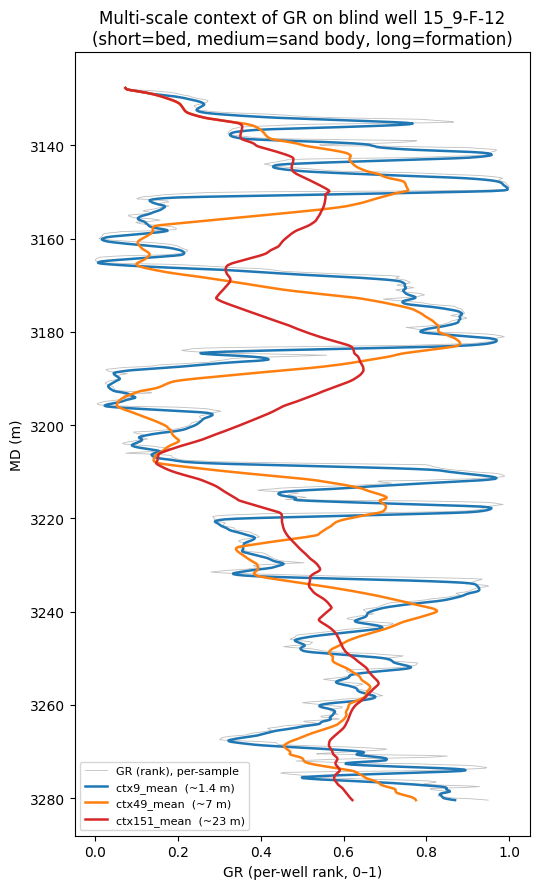

In [11]:
# Illustrate the 3 scales: per-sample GR (rank) vs its rolling means at 9 / 49 / 151 samples, one well.
wviz = "15_9-F-12"
m = dfL[WELL] == wviz
md = dfL.loc[m, MD].values
meters = {9: 1.4, 49: 7, 151: 23}
colors = {9: "#1f77b4", 49: "#ff7f0e", 151: "#d62728"}

fig, ax = plt.subplots(figsize=(5.5, 9))
ax.plot(X_all.loc[m, f"q::{GR}"].values, md, color="0.75", lw=0.6, label="GR (rank), per-sample")
for w in (9, 49, 151):
    ax.plot(X_all.loc[m, f"ctx{w}_mean::{GR}"].values, md, color=colors[w], lw=1.8,
            label=f"ctx{w}_mean  (~{meters[w]} m)")
ax.invert_yaxis()
ax.set_xlabel("GR (per-well rank, 0\u20131)"); ax.set_ylabel("MD (m)")
ax.set_title(f"Multi-scale context of GR on blind well {wviz}\n(short=bed, medium=sand body, long=formation)")
ax.legend(fontsize=8, loc="best")
fig.tight_layout(); plt.show()

## Step 4b: Do the features actually differentiate the facies?

Step 2a showed that *raw single-depth logs* cannot separate the facies (the KDE overlap plot). The whole premise of Step 4 is that the *engineered* features can. This section shows that directly, per facies and per confused pair, with each feature tied to the diagnostic log motif of Kieft et al. (2011) it was designed to carry.

**How each pair is told apart (the professor's "Tidal Channel vs Tidal Bar" question, answered feature by feature):**

| Pair | Kieft's motif | Carrying feature | Separability (AUC, computed below) |
|---|---|---|---|
| Tidal Channel vs Tidal Bar | different *cleanliness level*: in these wells the channel fills are the cleanest, lowest-GR sands (sharp-based, sand-filled), while the bars carry mud drapes and reactivation surfaces (higher, more spread-out GR) | static rank-GR / VSH and their short context means | **~0.94** nearly resolved by cleanliness alone |
| Mouthbar vs Shoreface | both coarsen upward, but at different scale/steepness of the GR trend | `shape_trend151` (formation-scale fining/coarsening) | **~0.83** the trend feature is the single best separator |
| Tidal Bar vs Shoreface | thick blocky bar vs trended shoreface | `shape_trend151`, long-window resistivity context | ~0.80 |
| Mud/Seal vs Shoreface | impermeable mud vs reservoir sand | rank-KLOGH, long GR/VSH context | ~0.81 |
| Tidal Bar vs Mouthbar | the *hardest* pair: two clean-sand bodies | body-scale context (ctx49/151) only | **~0.69** genuinely ambiguous |

**Reading the violins (below):** the per-class distributions make the motifs visible — `shape_trend` sits *negative* for Tidal Channel (fining-up: GR increases upward from the sharp base) and *positive* for Mouthbar/Shoreface (coarsening-up), exactly Kieft's signature; `serr_ratio` peaks in the channel fill (serrated above the clean base) ; `BaseSharp` flags the sharp-bounded thin muds/seals; and the rank-GR violin shows the cleanliness ladder that resolves channel-vs-bar — channel fill lowest GR, bars intermediate with a wide mud-draped spread, seals highest.

**And the residual confusion is explained, not mysterious:** the one pair without a strong single-feature discriminator — Tidal Bar vs Mouthbar (best AUC ~0.69, body-scale context) — is precisely the dominant off-diagonal cell of the Step 8 confusion matrices, and the pair the Step 11 discrimination experts target. The feature set differentiates everything Kieft's model says is log-distinguishable; what remains confused is the pair that shares the same clean-sand motif at single-well scale.

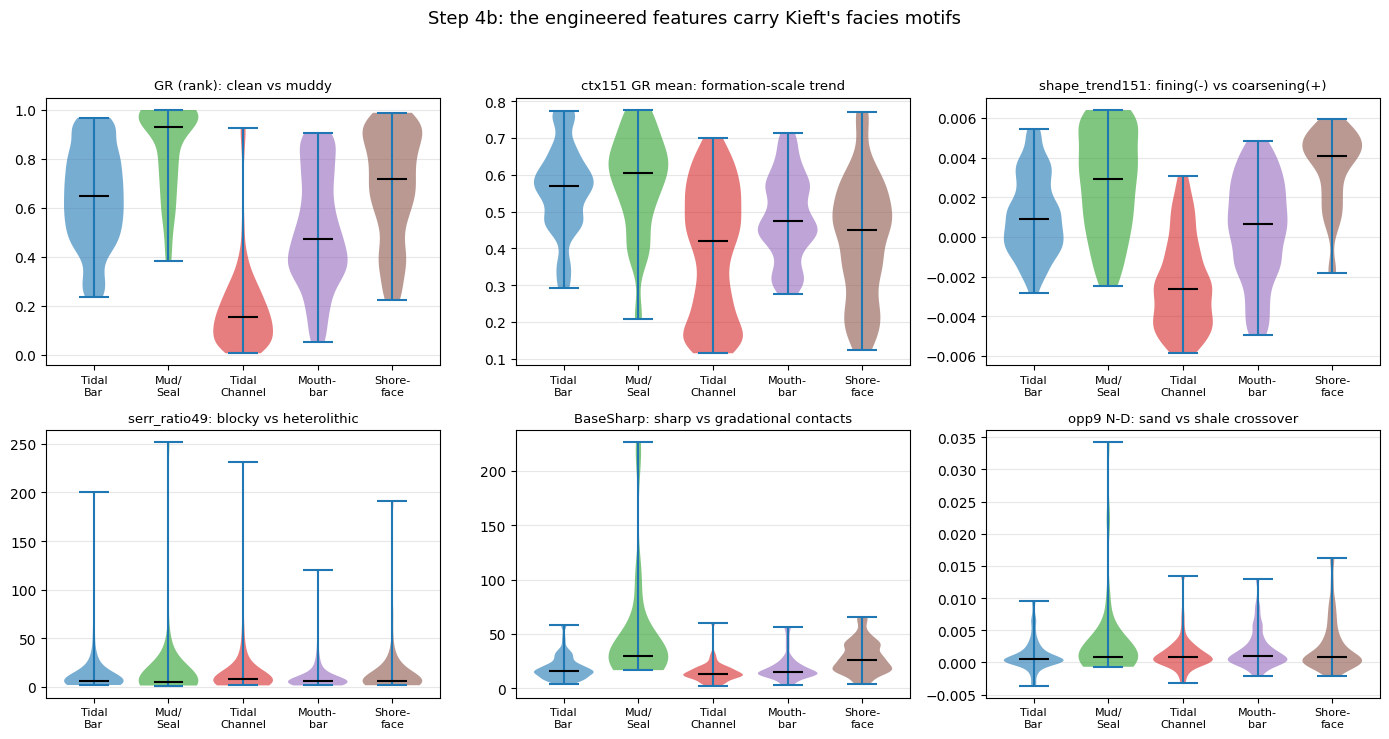

top-5 single-feature AUC discriminators per facies pair (blind separability of one feature):



  Tidal Channel vs Tidal Bar:
    0.937  q::GR_Cropped _Combined_Final, API
    0.937  q::VSH_Cropped _Combined_Final, v/v
    0.935  ctx9_mean::VSH_Cropped _Combined_Final, v/v
    0.935  ctx9_mean::GR_Cropped _Combined_Final, API
    0.928  ctx9_mean::KLOGH_Cropped _Combined_Final



  Tidal Bar vs Mouthbar:
    0.689  ctx151_std::RT_Cropped _Combined_Final, ohm.m
    0.684  ctx49_mean::GR_Cropped _Combined_Final, API
    0.684  ctx49_mean::VSH_Cropped _Combined_Final, v/v
    0.683  ctx49_mean::KLOGH_Cropped _Combined_Final
    0.676  q::GR_Cropped _Combined_Final, API



  Mouthbar vs Shoreface:
    0.829  shape_trend151::GR
    0.725  ctx151_mean::RD_Cropped _Combined_Final, ohm.m
    0.717  geo_BaseSharp
    0.714  q::VSH_Cropped _Combined_Final, v/v
    0.714  q::GR_Cropped _Combined_Final, API



  Tidal Bar vs Shoreface:
    0.801  shape_trend151::GR
    0.758  ctx151_mean::RT_Cropped _Combined_Final, ohm.m
    0.744  ctx151_mean::SW_Cropped _Combined_Final
    0.743  serr_ratio151::GR
    0.738  ctx151_mean::GR_Cropped _Combined_Final, API



  Mud/ Seal vs Shoreface:
    0.805  q::KLOGH_Cropped _Combined_Final
    0.776  ctx9_mean::KLOGH_Cropped _Combined_Final
    0.770  ctx151_mean::GR_Cropped _Combined_Final, API
    0.770  ctx151_mean::VSH_Cropped _Combined_Final, v/v
    0.756  q::PHIF_Cropped _Combined_Final


In [12]:
# Step 4b: per-class distributions of the motif features + best single-feature
# discriminators for the confused pairs (single-feature ROC-AUC, folded to >= 0.5).
from sklearn.metrics import roc_auc_score

_nm = {0: "Tidal\nBar", 2: "Mud/\nSeal", 3: "Tidal\nChannel", 4: "Mouth-\nbar", 5: "Shore-\nface"}
MOTIF_FEATS = [
    (f"q::{GR}",               "GR (rank): clean vs muddy"),
    (f"ctx151_mean::{GR}",     "ctx151 GR mean: formation-scale trend"),
    ("shape_trend151::GR",     "shape_trend151: fining(-) vs coarsening(+)"),
    ("serr_ratio49::GR",       "serr_ratio49: blocky vs heterolithic"),
    ("geo_BaseSharp",          "BaseSharp: sharp vs gradational contacts"),
    ("opp9::ND",               "opp9 N-D: sand vs shale crossover"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for ax, (col, title) in zip(axes.ravel(), MOTIF_FEATS):
    data, labs = [], []
    for c in CLASSES:
        v = X.loc[(y == c).values, col].dropna().values
        # clip tails for readability (distributions, not outliers, are the message)
        lo, hi = np.percentile(v, [2, 98])
        data.append(np.clip(v, lo, hi))
        labs.append(_nm[c])
    vp = ax.violinplot(data, showmedians=True, widths=0.8)
    for body, c in zip(vp["bodies"], CLASSES):
        body.set_facecolor(plt.cm.tab10(int(c) % 10)); body.set_alpha(0.6)
    vp["cmedians"].set_color("black")
    ax.set_xticks(range(1, len(CLASSES) + 1)); ax.set_xticklabels(labs, fontsize=8)
    ax.set_title(title, fontsize=9.5)
    ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)
fig.suptitle("Step 4b: the engineered features carry Kieft's facies motifs", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# --- best single-feature discriminators for the key pairs ---
PAIRS_4B = [(3, 0), (0, 4), (4, 5), (0, 5), (2, 5)]
print("top-5 single-feature AUC discriminators per facies pair (blind separability of one feature):")
for a, b in PAIRS_4B:
    m = y.isin([a, b]).values
    yy = (y[m] == b).astype(int).values
    aucs = {}
    for col in FULL_COLS:
        v = X.loc[m, col].values
        ok = ~np.isnan(v)
        if ok.sum() < 100 or len(np.unique(yy[ok])) < 2:
            continue
        auc = roc_auc_score(yy[ok], v[ok])
        aucs[col] = max(auc, 1 - auc)
    top = sorted(aucs.items(), key=lambda kv: -kv[1])[:5]
    pa, pb = _nm[a].replace("\n", " ").replace("- ", ""), _nm[b].replace("\n", " ").replace("- ", "")
    print(f"\n  {pa} vs {pb}:")
    for col, v in top:
        print(f"    {v:.3f}  {col}")

## Step 5: The model

**Classifier:** `RandomForestClassifier` (800 trees, `max_depth=25`, `class_weight="balanced"`), wrapped with a median imputer (RF can't take NaNs). RF beat gradient-boosting alternatives (HGB, LightGBM, XGBoost; all re-tested blind, all ≥6 pp worse) and every RF+boosting soft-vote blend on this task; `class_weight="balanced"` partially counters the class imbalance (seal is rare). 800 trees instead of 400 is pure variance reduction (+0.5 pp blind, no tuning risk: a forest can't overfit by adding trees); deeper hyperparameter changes (depth, leaf size, `max_features`) were all tried blind and none beat this default.

**Vertical probability smoothing:** the model classifies each 0.15 m sample independently, so raw predictions "flicker" sample-to-sample, producing geologically-unrealistic 1-sample beds. Real beds are metres thick. So before the final `argmax`, we smooth the predicted probabilities along depth with a centered rolling mean (~1.4 m window). This makes the facies log blocky *and* nudges accuracy up by removing isolated misclassifications inside otherwise-correct beds. It uses no labels, so it is leakage-free.

In [13]:
def make_model():
    return make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(n_estimators=800, max_depth=25, min_samples_leaf=2,
                               max_features="sqrt", class_weight="balanced",
                               random_state=42, n_jobs=-1))

def smooth(proba, win=9):
    """Centered rolling-mean of class probabilities along depth (~1.4 m)."""
    return pd.DataFrame(proba).rolling(win, min_periods=1, center=True).mean().values

print(make_model())

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=25,
                                        min_samples_leaf=2, n_estimators=800,
                                        n_jobs=-1, random_state=42))])


## Step 6: Blind-well evaluation

The test unit is a whole well, never random rows. For each of the 5 wells we:

1. **train** on the other 4 wells,
2. **predict** the held-out ("blind") well it never saw,
3. drop any feature that is constant in the training fold,
4. **smooth** the predicted probabilities along depth, then `argmax` to a label,
5. record facies accuracy and tier accuracy, and collect predictions for pooled scoring.

```
for well W in the 5 wells:
    train on (all wells except W)  ->  predict W  ->  smooth  ->  score
```

**Methodology at a glance**

| Aspect | Choice |
|---|---|
| Task | 5-class facies classification per ~0.15 m depth sample |
| Rotation | Leave-one-well-out over the 5 log-rich wells (5 folds; the blind well contributes zero samples to training) |
| Model | `Pipeline(SimpleImputer(median) -> RandomForestClassifier(n_estimators=800, max_depth=25, min_samples_leaf=2, max_features="sqrt", class_weight="balanced"))`; fixed hyperparameters from Step 5, no tuning inside the rotation (so no inner CV is needed and nothing can leak from the blind well) |
| Features | All ~117 engineered columns (`FULL_COLS`), minus any column constant within the training fold |
| Post-processing | Centered rolling mean (window 9 ≈ 1.4 m) over class probabilities along depth, then `argmax`; label-free, hence leakage-free |
| Metrics | Per-well facies accuracy + tier accuracy; predictions pooled across the 5 blind wells for the global scores in Step 7 |
| Why no shuffled KFold | Logs are depth-autocorrelated within a well, so a pooled/shuffled split would put near-neighbour samples on both sides and inflate accuracy. Holding out whole wells matches the deployment scenario: predicting a well never seen before |

In [14]:
def tier_acc(y_true, y_pred):
    tt = np.array([TIER_ORD[TIER[v]] for v in y_true])
    tp = np.array([TIER_ORD[TIER[v]] for v in y_pred])
    return float(np.mean(tt == tp))

rows = []
y_true_all, y_pred_all = [], []
per_well = {}

for well in LOGRICH:
    te = (df[WELL] == well).values
    tr = ~te
    valid = [c for c in FULL_COLS if X.loc[tr, c].nunique(dropna=True) >= 2]   # drop constant cols

    model = make_model()
    model.fit(np.asarray(X.loc[tr, valid]), y[tr])
    classes = model.steps[-1][1].classes_

    proba_raw = model.predict_proba(np.asarray(X.loc[te, valid]))  # kept unsmoothed for Appendix D3/E1
    proba = smooth(proba_raw)
    pred = classes[np.argmax(proba, axis=1)]
    truth = y[te].values

    rows.append({"well": well, "n": int(te.sum()),
                 "facies_acc": accuracy_score(truth, pred),
                 "tier_acc": tier_acc(truth, pred)})
    y_true_all.extend(truth.tolist()); y_pred_all.extend(pred.tolist())
    per_well[well] = {"truth": truth, "pred": pred, "proba_raw": proba_raw, "classes": classes}
    print(f"done blind well {well:12s} n={int(te.sum()):4d}  acc={rows[-1]['facies_acc']:.3f}")

y_true_all = np.array(y_true_all); y_pred_all = np.array(y_pred_all)
print("\nall folds complete.")

done blind well 15_9-F-4     n=1146  acc=0.697


done blind well 15_9-F-5     n=1573  acc=0.593


done blind well 15_9-F-12    n=1003  acc=0.598


done blind well 15_9-F-14    n=1364  acc=0.468


done blind well 15_9-F-15_C  n= 237  acc=0.536

all folds complete.


## Step 7: Results

Two views:

- **Per-well + pooled accuracy**: raw facies accuracy and the more lenient tier accuracy.
- **Economic / reservoir metrics**, what matters for a drilling/completion decision: net-pay vs seal accuracy, reservoir recall (did we capture the pay?), critical pay↔seal error rate (catastrophic swaps), within-1-tier accuracy, and value-weighted F1.

In [15]:
def economic_report(yt, yp):
    pay_t, pay_p = np.isin(yt, list(PAY)), np.isin(yp, list(PAY))
    seal_t, seal_p = np.isin(yt, list(SEAL)), np.isin(yp, list(SEAL))
    tt = np.array([TIER_ORD[TIER[v]] for v in yt])
    tp = np.array([TIER_ORD[TIER[v]] for v in yp])
    labs = sorted(set(yt) | set(yp))
    f1s = f1_score(yt, yp, labels=labs, average=None, zero_division=0)
    vw = sum(f * VALUE.get(l, 1.0) for f, l in zip(f1s, labs)) / sum(VALUE.get(l, 1.0) for l in labs)
    return {
        "net_reservoir_binacc": float(np.mean(pay_t == pay_p)),
        "reservoir_recall":     float(np.mean(pay_p[pay_t])),
        "seal_recall":          float(np.mean(seal_p[seal_t])) if seal_t.any() else float("nan"),
        "seal_precision":       float(np.mean(seal_t[seal_p])) if seal_p.any() else float("nan"),
        "critical_payseal_err": float(np.mean((pay_t & seal_p) | (seal_t & pay_p))),
        "tier_exact":           float(np.mean(tt == tp)),
        "tier_adjacent":        float(np.mean(np.abs(tt - tp) <= 1)),
        "macro_f1":             float(f1_score(yt, yp, average="macro", zero_division=0)),
        "value_weighted_f1":    float(vw),
    }

res = pd.DataFrame(rows)
pooled_facies = accuracy_score(y_true_all, y_pred_all)
pooled_tier = tier_acc(y_true_all, y_pred_all)

print("Per-well blind accuracy (RandomForest, merged 5-class, smoothed)")
print(res.to_string(index=False))
print(f"\nmean facies acc = {res['facies_acc'].mean():.3f}   mean tier acc = {res['tier_acc'].mean():.3f}")
print(f"pooled facies acc = {pooled_facies:.3f}   pooled tier acc = {pooled_tier:.3f}")

print("\nEconomic / reservoir metrics (pooled over all 5 blind wells):")
for k, v in economic_report(y_true_all, y_pred_all).items():
    print(f"  {k:24s} {v:.3f}")

Per-well blind accuracy (RandomForest, merged 5-class, smoothed)
       well    n  facies_acc  tier_acc
   15_9-F-4 1146    0.697208  0.732112
   15_9-F-5 1573    0.593134  0.652257
  15_9-F-12 1003    0.598205  0.666999
  15_9-F-14 1364    0.468475  0.557918
15_9-F-15_C  237    0.535865  0.683544

mean facies acc = 0.579   mean tier acc = 0.659
pooled facies acc = 0.582   pooled tier acc = 0.649

Economic / reservoir metrics (pooled over all 5 blind wells):
  net_reservoir_binacc     0.958
  reservoir_recall         0.987
  seal_recall              0.221
  seal_precision           0.413
  critical_payseal_err     0.042
  tier_exact               0.649
  tier_adjacent            0.984
  macro_f1                 0.501
  value_weighted_f1        0.554


## Step 8: Diagnostics

### 8a. Confusion matrices (pooled, row-normalized)

Two confusion matrices over all blind predictions: facies (5 classes) and tier (Excellent / Good / Seal). Row-normalized = each row sums to 100% (recall per true class). Watch for: Tidal Channel recognised well; the Tidal Bar / Mouthbar / Shoreface trio confusing with each other; and Seal (class 2) under-detected.

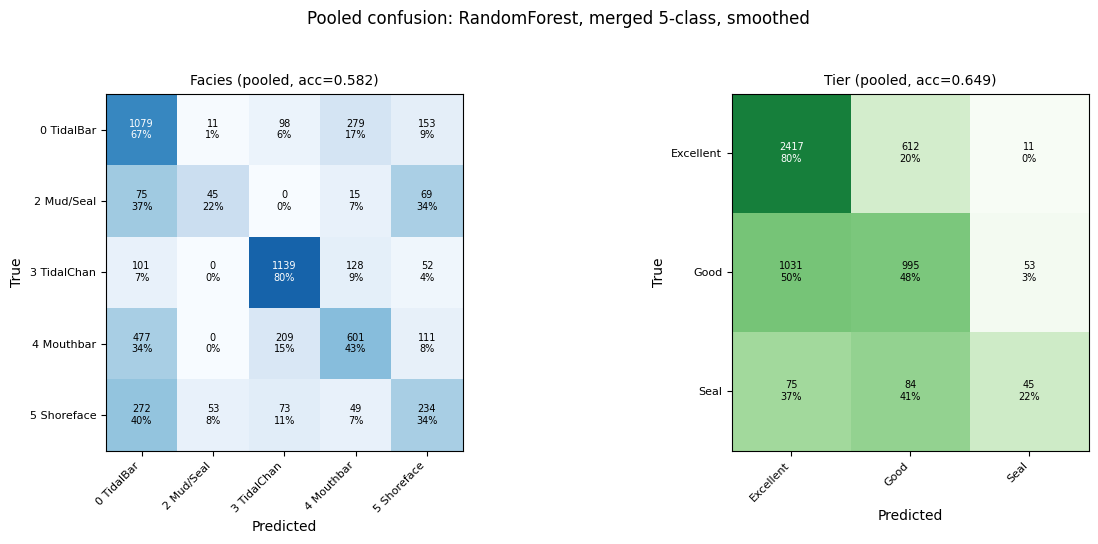

In [16]:
def plot_cm(ax, cm, labels, title, cmap):
    cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cmn, cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title, fontsize=10)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{cm[i,j]}\n{cmn[i,j]*100:.0f}%", ha="center", va="center",
                    color="white" if cmn[i, j] > 0.5 else "black", fontsize=7)

FAC = [0, 2, 3, 4, 5]
FAC_NAMES = ["0 TidalBar", "2 Mud/Seal", "3 TidalChan", "4 Mouthbar", "5 Shoreface"]
cm_fac = confusion_matrix(y_true_all, y_pred_all, labels=FAC)

TIERS = ["Excellent", "Good", "Seal"]
TIDX = {t: i for i, t in enumerate(TIERS)}
tt = np.array([TIDX[TIER[v]] for v in y_true_all])
tp = np.array([TIDX[TIER[v]] for v in y_pred_all])
cm_tier = confusion_matrix(tt, tp, labels=[0, 1, 2])

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
plot_cm(ax[0], cm_fac, FAC_NAMES, f"Facies (pooled, acc={pooled_facies:.3f})", "Blues")
plot_cm(ax[1], cm_tier, TIERS, f"Tier (pooled, acc={pooled_tier:.3f})", "Greens")
fig.suptitle("Pooled confusion: RandomForest, merged 5-class, smoothed", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

### 8a. Per-well confusion matrices (facies and tier)

The pooled matrix above hides per-well behaviour. Below, each blind well gets its own row-normalized confusion matrix: facies (5 classes) on the left, economic tier (Excellent / Good / Seal) on the right. Rows = true class, columns = predicted, so the diagonal is per-class recall. This is where you can see, well by well, which facies get confused (e.g. the Tidal Bar ↔ Mouthbar ↔ Shoreface trio) and whether errors stay within the same economic tier.

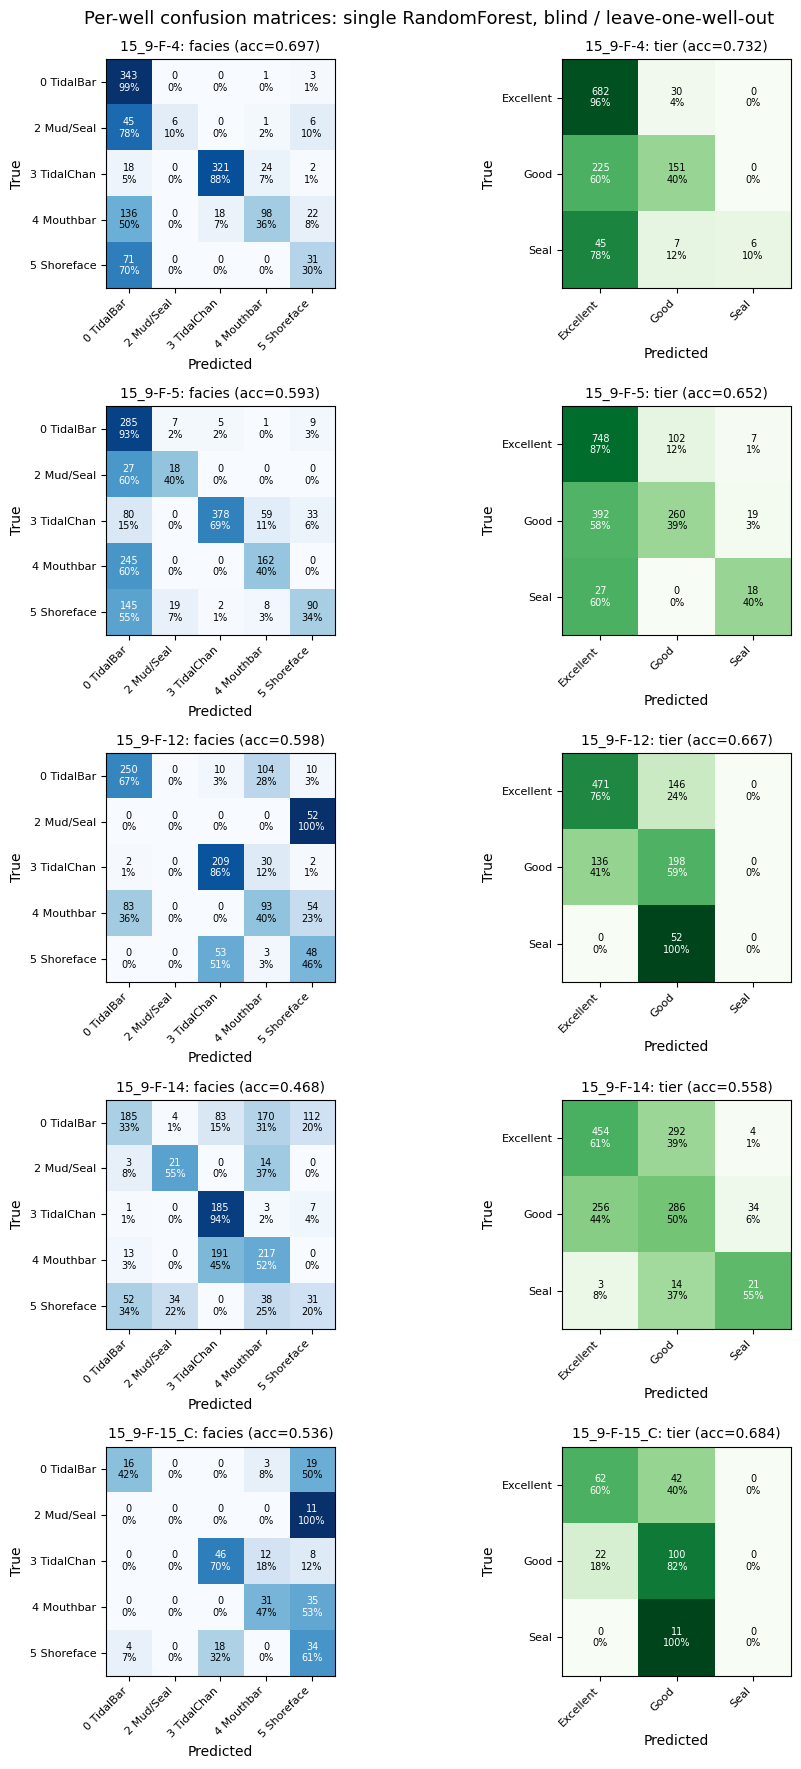

In [17]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(len(LOGRICH), 2, figsize=(10, 3.6 * len(LOGRICH)))
for r, well in enumerate(LOGRICH):
    t, p = per_well[well]["truth"], per_well[well]["pred"]

    cm_f = confusion_matrix(t, p, labels=CLASSES)
    plot_cm(axes[r, 0], cm_f, FAC_NAMES, f"{well}: facies (acc={accuracy_score(t, p):.3f})", "Blues")

    tt = [TIER_ORD[TIER[v]] for v in t]
    tp = [TIER_ORD[TIER[v]] for v in p]
    cm_t = confusion_matrix(tt, tp, labels=[2, 1, 0])              # Excellent, Good, Seal
    plot_cm(axes[r, 1], cm_t, TIERS, f"{well}: tier (acc={accuracy_score(tt, tp):.3f})", "Greens")

fig.suptitle("Per-well confusion matrices: single RandomForest, blind / leave-one-well-out", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.99]); plt.show()

### 8b. Feature importance: confirming the multi-scale features (Step 4a)

We refit RF on each fold, average the impurity importances, and sum them by family. This is the evidence behind the multi-scale context features of Step 4a: that block dominates the model's decisions. Practical takeaway: if you add only one thing to a simpler pipeline, add rolling mean/std of the logs at 2–3 geological window sizes.

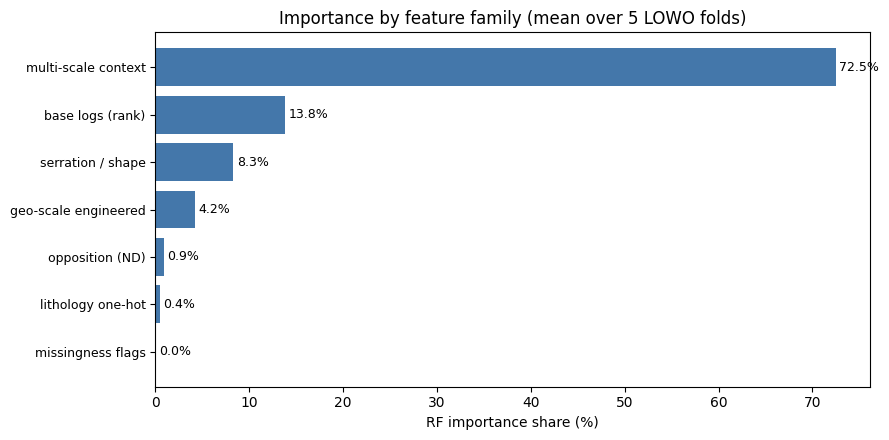

multi-scale context     72.5%
base logs (rank)        13.8%
serration / shape        8.3%
geo-scale engineered     4.2%
opposition (ND)          0.9%
lithology one-hot        0.4%
missingness flags        0.0%


In [18]:
FAMILY = {}
for c in groups["static_rank"]:   FAMILY[c] = "base logs (rank)"
for c in groups["missing"]:       FAMILY[c] = "missingness flags"
for c in groups["context_multi"]: FAMILY[c] = "multi-scale context"
for c in groups["serration"]:     FAMILY[c] = "serration / shape"
for c in groups["opposition"]:    FAMILY[c] = "opposition (ND)"
for c in geo_cols:                FAMILY[c] = "geo-scale engineered"
for c in groups["lithology"]:     FAMILY[c] = "lithology one-hot"

imp = pd.Series(0.0, index=FULL_COLS)
for well in LOGRICH:
    te = (df[WELL] == well).values; tr = ~te
    valid = [c for c in FULL_COLS if X.loc[tr, c].nunique(dropna=True) >= 2]
    m = make_model(); m.fit(np.asarray(X.loc[tr, valid]), y[tr])
    s = pd.Series(0.0, index=FULL_COLS); s.loc[valid] = m.steps[-1][1].feature_importances_
    imp += s
imp = imp / imp.sum()

fam_imp = imp.groupby(FAMILY).sum().sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(range(len(fam_imp)), fam_imp.values * 100, color="#4477aa")
ax.set_yticks(range(len(fam_imp))); ax.set_yticklabels(fam_imp.index, fontsize=9)
ax.set_xlabel("RF importance share (%)")
ax.set_title("Importance by feature family (mean over 5 LOWO folds)")
for i, v in enumerate(fam_imp.values):
    ax.text(v * 100 + 0.4, i, f"{v*100:.1f}%", va="center", fontsize=9)
fig.tight_layout(); plt.show()

print(fam_imp.sort_values(ascending=False).apply(lambda v: f"{v*100:.1f}%").to_string())

### 8c. Learning curve: does the classifier actually learn from the data?

A standard check ("error curve"): hold the blind well fixed and vary the amount of training data. Here the natural unit is whole wells, so for each blind fold we train on every subset of 1, 2, 3 and 4 of the remaining wells and score blind accuracy.

**What it shows (computed below):**

- **Blind accuracy rises monotonically with training wells**: mean 0.44 → 0.48 → 0.51 → 0.58 for 1 → 4 wells, and every individual fold improves from k=1 to k=4. The classifier is genuinely learning transferable structure from additional wells, not memorising — its blind performance is *data-limited*.
- **Train accuracy stays ≈ 1.0 and flat.** That is the expected behaviour of a deep RandomForest (an interpolating ensemble), not evidence of harmful overfitting; for forests the informative curve is the *test* one. The large train–test gap quantifies the well-to-well distribution shift (each well has its own facies mix and log character), which is exactly why the evaluation must be leave-one-well-out (Step 6).
- **The spread across folds narrows with k** (std 0.13 at one training well → 0.085 at four): more wells make the blind score less dependent on *which* wells were available.
- **Implication for data breadth**: the curve has not flattened at k=4 — more log-rich wells would very likely keep paying. That is the strongest argument that the current ~0.58 is bounded by the 5-well dataset, not by the method (see also Appendix A1 for the wells-vs-logs trade-off).

blind 15_9-F-4: 15 subset fits done (61s)


blind 15_9-F-5: 15 subset fits done (117s)


blind 15_9-F-12: 15 subset fits done (177s)


blind 15_9-F-14: 15 subset fits done (237s)


blind 15_9-F-15_C: 15 subset fits done (306s)

mean accuracy vs number of training wells:
  test_acc        train_acc       
      mean    std      mean    std
k                                 
1    0.439  0.133     1.000  0.001
2    0.481  0.130     0.999  0.001
3    0.513  0.120     0.999  0.000
4    0.579  0.085     0.999  0.000


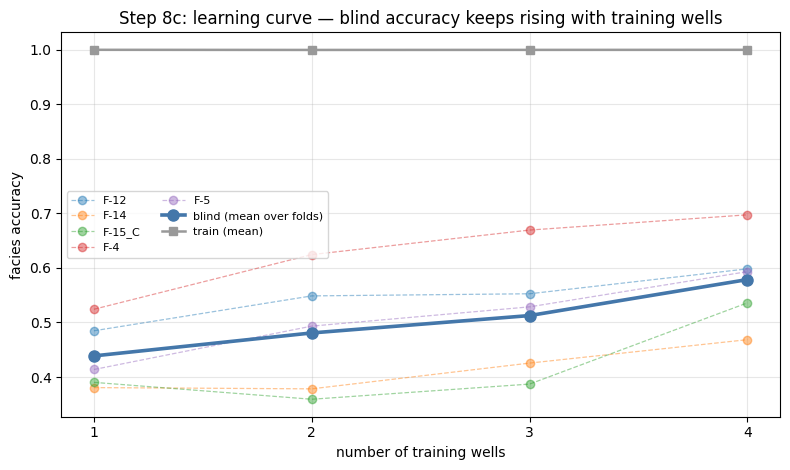

In [19]:
# Step 8c: learning curve over the number of training wells.
# For each blind well, train on every subset of k = 1..4 of the other wells
# (15 subsets per fold, 75 RF fits total, ~6 min) and score blind vs train accuracy.
from itertools import combinations
import time as _t

_t0 = _t.time()
lc_rows = []
for blind in LOGRICH:
    te = (df[WELL] == blind).values
    others = [w for w in LOGRICH if w != blind]
    for k in (1, 2, 3, 4):
        for combo in combinations(others, k):
            tr = df[WELL].isin(combo).values
            valid = [c for c in FULL_COLS if X.loc[tr, c].nunique(dropna=True) >= 2]
            m = make_model()
            m.fit(np.asarray(X.loc[tr, valid]), y[tr])
            classes = m.steps[-1][1].classes_
            proba = smooth(m.predict_proba(np.asarray(X.loc[te, valid])))
            pred = classes[np.argmax(proba, axis=1)]
            lc_rows.append({"blind": blind, "k": k,
                            "test_acc": accuracy_score(y[te].values, pred),
                            "train_acc": accuracy_score(y[tr].values,
                                                        m.predict(np.asarray(X.loc[tr, valid])))})
    print(f"blind {blind}: 15 subset fits done ({_t.time()-_t0:.0f}s)")

lc = pd.DataFrame(lc_rows)
lc_mean = lc.groupby("k")[["test_acc", "train_acc"]].mean()
print("\nmean accuracy vs number of training wells:")
print(lc.groupby("k")[["test_acc", "train_acc"]].agg(["mean", "std"]).round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4.8))
for blind, g in lc.groupby("blind"):
    gm = g.groupby("k")["test_acc"].mean()
    ax.plot(gm.index, gm.values, "o--", lw=0.9, alpha=0.45, label=blind.replace("15_9-", ""))
ax.plot(lc_mean.index, lc_mean["test_acc"], "o-", color="#4477aa", lw=2.6, ms=8,
        label="blind (mean over folds)")
ax.plot(lc_mean.index, lc_mean["train_acc"], "s-", color="#999999", lw=1.8,
        label="train (mean)")
ax.set_xticks([1, 2, 3, 4])
ax.set_xlabel("number of training wells")
ax.set_ylabel("facies accuracy")
ax.set_title("Step 8c: learning curve \u2014 blind accuracy keeps rising with training wells")
ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); plt.show()

## Step 9: Multi-scenario ensemble

A single RandomForest is one "view" of the data. An ensemble of models trained on different feature views and tuned for different objectives is more robust because the members make decorrelated errors, which we average into a single, steadier prediction.

**Design.** Kept deliberately small: a large ensemble built from many overlapping feature subsets is highly redundant, so we use only a few genuinely complementary views.

- **6 feature views**, complementary lenses on our feature set rather than 19 overlapping subsets:
  1. **FULL**: all ~117 features (our anchor model)
  2. **Context**: base rank-logs + multi-scale context (the trend/texture lens)
  3. **Engineered**: base rank-logs + serration + opposition + geo + lithology (*no* context; ≈ the classic petrophysical/engineered model)
  4. **BedScale**: base rank-logs + ctx9 + short-window serration + GR_Slope/BaseSharpness/GR_Serration (thin-bed resolution)
  5. **BodyScale**: base rank-logs + ctx49/151 + shape-trend + NTG_Slope/RelPos/AI_Slope (sand-body / parasequence resolution)
  6. **Lean**: a compact curated set (z + 2-scale context of the most informative logs + NTG/RelPos), ≈ a forward-selection model
- **2 optimization metrics**: `custom_sand` (reservoir value-weighted F1) and `f1_weighted` (balanced). In practice these two tend to agree, but keeping both leaves room to experiment with the trade-off.
- **6 × 2 = 12 models** per blind well.
- **Per scenario:** `GridSearchCV` over a small grid (4 combos) with GroupKFold(4) on the 4 training wells (leave-one-well-out *within* training, no leakage), tuned on that scenario's metric.
- **Soft voting:** average the 12 probability vectors (equal weights) -> depth-smooth -> argmax. Plus uncertainty: prediction entropy, model-agreement %, top1−top2 margin.

We compare the ensemble against the single-RandomForest baseline from Step 7.

> **Outcome, stated up front:** with the rank-normalized features the single FULL model already absorbs what the views used to add, and the soft-vote ensemble comes out ~1 pp *below* the single RF on pooled facies accuracy. We keep this step because (a) the comparison itself is informative, and (b) the ensemble produces the per-sample uncertainty signals (model agreement, entropy, margin) and the scenario realizations of Step 10, which a single model cannot provide.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import make_scorer

# --- the 6 complementary feature views ---
ctx9   = [c for c in groups["context_multi"] if c.startswith("ctx9_")]
ctx49  = [c for c in groups["context_multi"] if c.startswith("ctx49_")]
ctx151 = [c for c in groups["context_multi"] if c.startswith("ctx151_")]
serr_short = [c for c in groups["serration"] if "49" in c]                 # short-window texture
serr_trend = [c for c in groups["serration"] if c.startswith("shape_trend")]
LEAN_LOGS = [GR, VSH, RT, RD, RHOB, KLOGH, NPHI]
lean_cols = ([f"q::{c}" for c in LEAN_LOGS]
             + [f"ctx9_mean::{c}" for c in LEAN_LOGS]
             + [f"ctx151_mean::{c}" for c in LEAN_LOGS]
             + ["geo_NTG_Slope", "geo_RelPos"])

VIEWS = {
    "FULL":      FULL_COLS,
    "Context":   groups["static_rank"] + groups["context_multi"],
    "Engineered": groups["static_rank"] + groups["serration"] + groups["opposition"] + geo_cols + groups["lithology"],
    "BedScale":  groups["static_rank"] + ctx9 + serr_short + ["geo_GR_Slope", "geo_BaseSharp", "geo_GR_Serr"],
    "BodyScale": groups["static_rank"] + ctx49 + ctx151 + serr_trend + ["geo_NTG_Slope", "geo_RelPos", "geo_AI_Slope"],
    "Lean":      lean_cols,
}

# --- the 2 optimization metrics ---
def custom_sand_score(y_true, y_pred):
    """Reservoir value-weighted F1 (per-class F1 weighted by economic VALUE * support)."""
    labs = sorted(set(y_true) | set(y_pred))
    f1s = f1_score(y_true, y_pred, labels=labs, average=None, zero_division=0)
    w = np.array([VALUE.get(l, 1.0) for l in labs])
    cnt = np.array([np.sum(np.asarray(y_true) == l) for l in labs])
    den = np.sum(w * cnt)
    return float(np.sum(f1s * w * cnt) / den) if den > 0 else 0.0

SCORERS = {
    "custom_sand": make_scorer(custom_sand_score, greater_is_better=True),
    "f1_weighted": make_scorer(f1_score, average="weighted", zero_division=0),
}

# --- small HP grid (4 combos) tuned per scenario ---
GRID = {"rf__n_estimators": [300], "rf__max_depth": [25],
        "rf__min_samples_leaf": [2, 3], "rf__max_features": ["sqrt", "log2"]}

def grid_pipe():
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("rf", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1))])

CI = {c: i for i, c in enumerate(CLASSES)}   # CLASSES defined with the facies merge
def aligned_proba(est, Xa):
    """predict_proba mapped into a fixed [0,2,3,4,5] column order."""
    p = est.predict_proba(Xa)
    out = np.zeros((Xa.shape[0], len(CLASSES)))
    for j, c in enumerate(est.classes_):
        out[:, CI[c]] = p[:, j]
    return out

print(f"{len(VIEWS)} views x {len(SCORERS)} metrics = {len(VIEWS)*len(SCORERS)} models per blind well")
for v, cols in VIEWS.items():
    print(f"  {v:10s} {len(cols):3d} cols")

6 views x 2 metrics = 12 models per blind well
  FULL       117 cols
  Context     84 cols
  Engineered  33 cols
  BedScale    43 cols
  BodyScale   65 cols
  Lean        23 cols


### Run the ensemble rotation

For each blind well: train the 12 scenarios on the other 4 wells (each tuned by `GridSearchCV` + `GroupKFold(4)`), average their probabilities, smooth, and predict. This is heavier than the single model (≈960 RF fits over the whole rotation), so it takes a few minutes.

**Methodology at a glance**

| Aspect | Choice |
|---|---|
| Outer rotation | Leave-one-well-out over the 5 log-rich wells, identical to Step 6, so the ensemble and the single-RF baseline are compared on the same blind folds |
| Ensemble members | 6 feature views x 2 optimization metrics = 12 RF pipelines per blind well (`SimpleImputer(median) -> RandomForestClassifier(class_weight="balanced")`) |
| Inner CV (tuning) | `GridSearchCV` per member over a small grid (`min_samples_leaf` {2,3} x `max_features` {sqrt, log2}; 300 trees, depth 25 fixed) with `GroupKFold(4)` grouped by well on the 4 training wells; every inner validation fold is a whole held-out well, and the blind well is never touched |
| OOF predictions | `cross_val_predict` with the same `GroupKFold(4)` produces out-of-fold predictions per view on the training wells; consumed by Step 11 (pair experts), never by the blind-well scoring |
| Aggregation | Probabilities aligned to the fixed class order, equal-weight soft vote over the 12 members -> depth smoothing (window 9) -> `argmax` |
| Uncertainty signals | Prediction entropy, member-agreement %, top1−top2 probability margin, per sample; reused in Step 10 scenarios |
| Leakage guarantees | Blind well excluded from member training, tuning, and OOF; smoothing is label-free; all inner splits are well-grouped |

In [21]:
import time
from sklearn.model_selection import cross_val_predict
ens_rows, eyt, eyp = [], [], []
ens_detail = {}
t0 = time.time()

for well in LOGRICH:
    te = (df[WELL] == well).values
    tr = ~te
    groups_tr = df.loc[tr, WELL].values
    n_splits = min(4, df.loc[tr, WELL].nunique())
    gkf = GroupKFold(n_splits=n_splits)

    ytr = np.asarray(y[tr])
    model_probs, model_args, model_view = [], [], []
    oof_view = {}
    for vname, vcols in VIEWS.items():
        valid = [c for c in vcols if X.loc[tr, c].nunique(dropna=True) >= 2]
        Xtr, Xte = np.asarray(X.loc[tr, valid]), np.asarray(X.loc[te, valid])
        # out-of-fold predictions on the training wells (the blind well is never used here);
        # Step 11 uses these to find which view best separates each confused pair.
        oof_view[vname] = cross_val_predict(grid_pipe(), Xtr, ytr, groups=groups_tr, cv=gkf)
        for mname, scorer in SCORERS.items():
            gs = GridSearchCV(grid_pipe(), GRID, scoring=scorer, cv=gkf, n_jobs=1)
            gs.fit(Xtr, ytr, groups=groups_tr)
            pr = aligned_proba(gs.best_estimator_, Xte)
            model_probs.append(pr)
            model_args.append(np.argmax(pr, axis=1))
            model_view.append(vname)

    P = smooth(np.mean(model_probs, axis=0))                 # equal soft-vote + depth smoothing
    ens_arg = np.argmax(P, axis=1)
    pred = np.array(CLASSES)[ens_arg]
    truth = y[te].values

    entropy = -np.sum(P * np.log(P + 1e-10), axis=1)
    agreement = np.mean([(ma == ens_arg) for ma in model_args], axis=0)
    sp = np.sort(P, axis=1); margin = sp[:, -1] - sp[:, -2]

    ens_rows.append({"well": well, "n": int(te.sum()),
                     "facies_acc": accuracy_score(truth, pred), "tier_acc": tier_acc(truth, pred),
                     "agreement": float(agreement.mean()), "entropy": float(entropy.mean()),
                     "margin": float(margin.mean())})
    eyt.extend(truth.tolist()); eyp.extend(pred.tolist())
    ens_detail[well] = {"md": df.loc[te, MD].values, "proba": P, "truth": truth,
                        "pred": pred, "entropy": entropy, "agreement": agreement,
                        "mprobs": np.array(model_probs), "mview": model_view,
                        "oof_view": oof_view, "ytr": ytr}
    print(f"{well:12s} ens acc={ens_rows[-1]['facies_acc']:.3f}  tier={ens_rows[-1]['tier_acc']:.3f}  "
          f"agree={agreement.mean()*100:.0f}%  ({time.time()-t0:.0f}s elapsed)")

ens = pd.DataFrame(ens_rows)
eyt, eyp = np.array(eyt), np.array(eyp)
print(f"\nrotation done in {time.time()-t0:.0f}s")

15_9-F-4     ens acc=0.699  tier=0.731  agree=81%  (326s elapsed)


15_9-F-5     ens acc=0.597  tier=0.652  agree=83%  (610s elapsed)


15_9-F-12    ens acc=0.586  tier=0.646  agree=78%  (921s elapsed)


15_9-F-14    ens acc=0.441  tier=0.530  agree=77%  (1215s elapsed)


15_9-F-15_C  ens acc=0.494  tier=0.662  agree=71%  (1558s elapsed)

rotation done in 1558s


In [22]:
# Ensemble vs single-RandomForest baseline (Step 7)
cmp = (res[["well", "facies_acc", "tier_acc"]]
       .merge(ens[["well", "facies_acc", "tier_acc", "agreement"]], on="well", suffixes=("_single", "_ens")))
print("Per-well: single RF vs 12-model ensemble")
print(cmp.to_string(index=False))

ens_pooled_f = accuracy_score(eyt, eyp)
ens_pooled_t = tier_acc(eyt, eyp)
print(f"\npooled facies  single={pooled_facies:.3f}  ensemble={ens_pooled_f:.3f}  (delta {ens_pooled_f-pooled_facies:+.3f})")
print(f"pooled tier    single={pooled_tier:.3f}  ensemble={ens_pooled_t:.3f}  (delta {ens_pooled_t-pooled_tier:+.3f})")
print(f"mean facies    single={res['facies_acc'].mean():.3f}  ensemble={ens['facies_acc'].mean():.3f}")
print(f"mean tier      single={res['tier_acc'].mean():.3f}  ensemble={ens['tier_acc'].mean():.3f}")

print("\nEnsemble economic / reservoir metrics (pooled):")
for k, v in economic_report(eyt, eyp).items():
    print(f"  {k:24s} {v:.3f}")
print("\nMean model agreement per well (ensemble confidence):")
print(ens[["well", "agreement", "entropy", "margin"]].to_string(index=False))

Per-well: single RF vs 12-model ensemble
       well  facies_acc_single  tier_acc_single  facies_acc_ens  tier_acc_ens  agreement
   15_9-F-4           0.697208         0.732112        0.698953      0.731239   0.806428
   15_9-F-5           0.593134         0.652257        0.596949      0.652257   0.825281
  15_9-F-12           0.598205         0.666999        0.586241      0.646062   0.781904
  15_9-F-14           0.468475         0.557918        0.441349      0.530059   0.772911
15_9-F-15_C           0.535865         0.683544        0.493671      0.662447   0.714135

pooled facies  single=0.582  ensemble=0.572  (delta -0.010)
pooled tier    single=0.649  ensemble=0.637  (delta -0.012)
mean facies    single=0.579  ensemble=0.563
mean tier      single=0.659  ensemble=0.644

Ensemble economic / reservoir metrics (pooled):
  net_reservoir_binacc     0.959
  reservoir_recall         0.989
  seal_recall              0.206
  seal_precision           0.429
  critical_payseal_err     0.041
  

### Ensemble well panels: inputs vs outputs (per well)

A five-panel depth log per blind well, so the predictions can be *interpreted against the inputs that produced them*:

1. **GR (rank)** and 2. **VSH (rank)**: two key input tracks exactly as the model sees them (per-well rank-normalized). Read the facies motifs directly: low blocky GR = clean sand (bar), upward-increasing GR = fining-up (channel fill), upward-decreasing = coarsening-up (mouthbar/shoreface), sharp high-GR spikes = muds/seals.
3. **Facies proportions**: the 12-model averaged probability for each of the 5 classes, stacked to 1.0 down the well. Wide single-colour bands = confident, blended bands = ambiguous.
4. **Uncertainty**: normalized prediction entropy (red) and model disagreement `1 − agreement` (blue). Spikes flag depths where the committee is split — they line up with the transitional/serrated stretches of the GR/VSH tracks, not with the clean blocky intervals.
5. **True vs ensemble**: side-by-side colour strips of the cored truth (left) and the ensemble prediction (right), with the blind accuracy for that well.

Plotted against measured depth (MD, m), one figure per blind well.

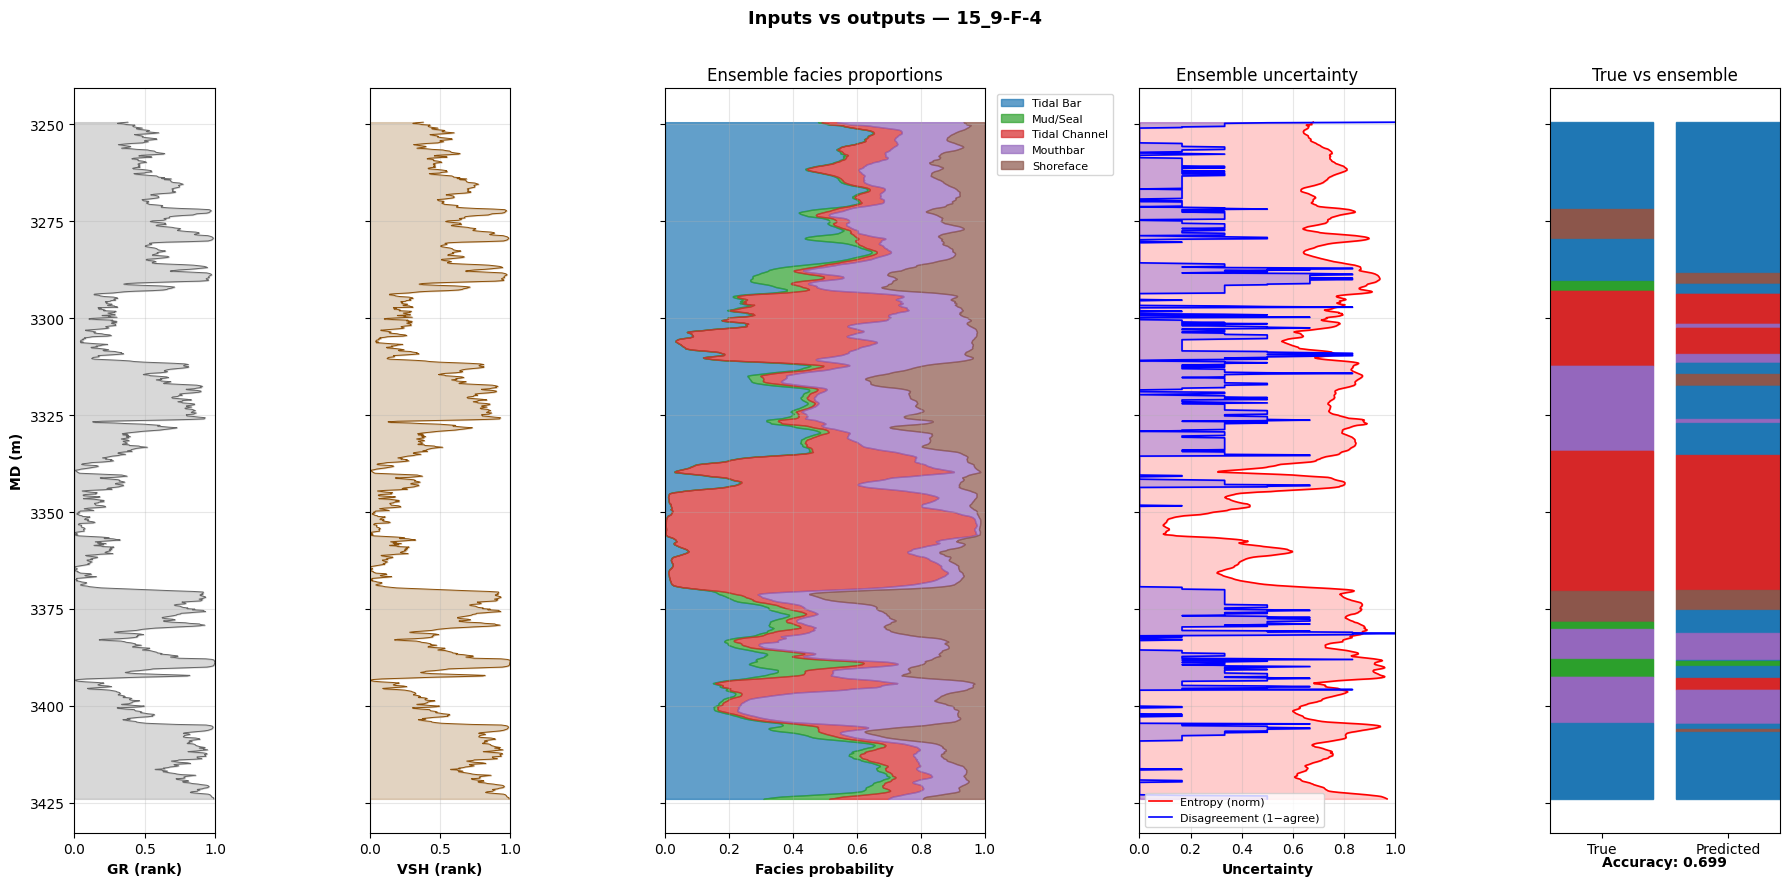

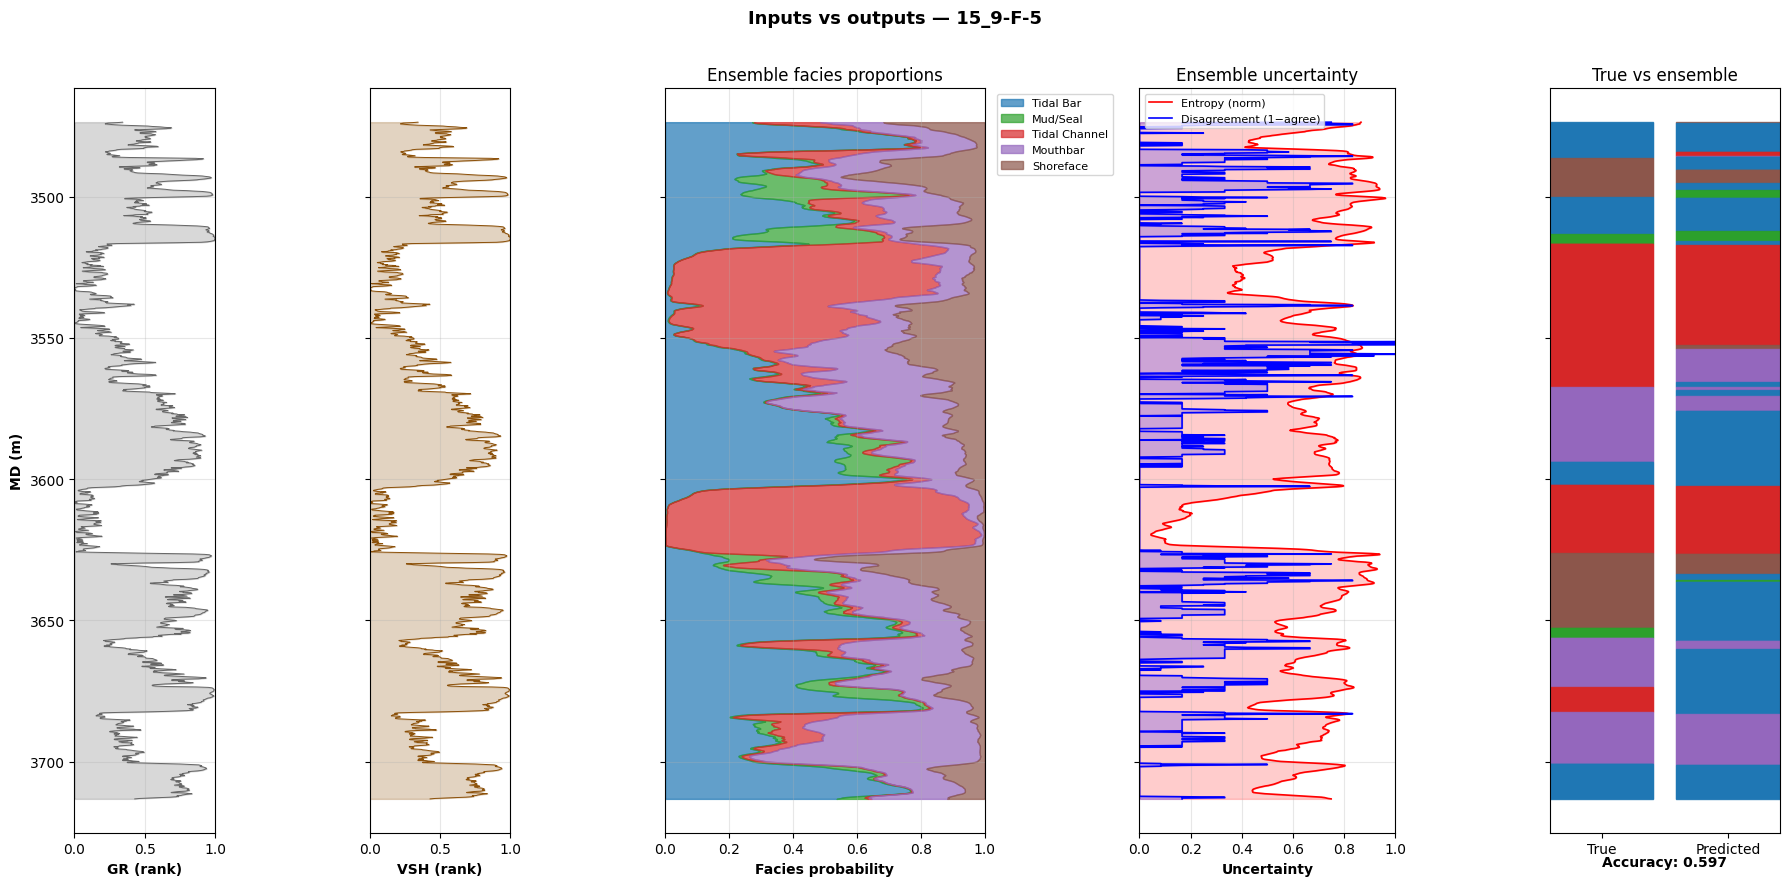

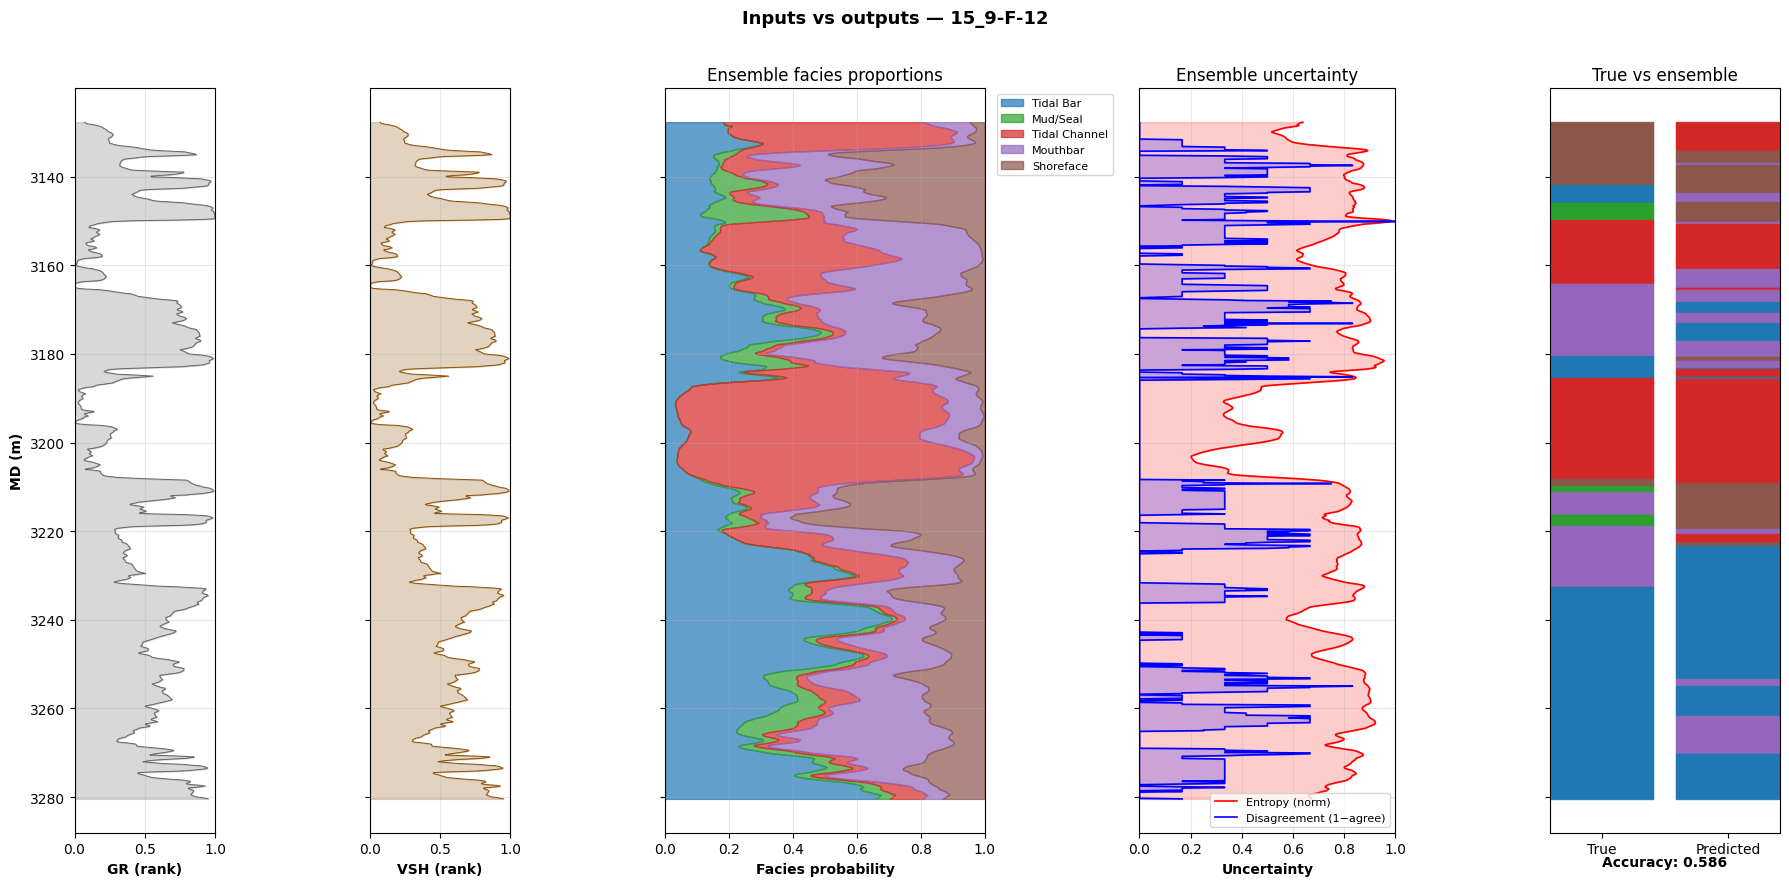

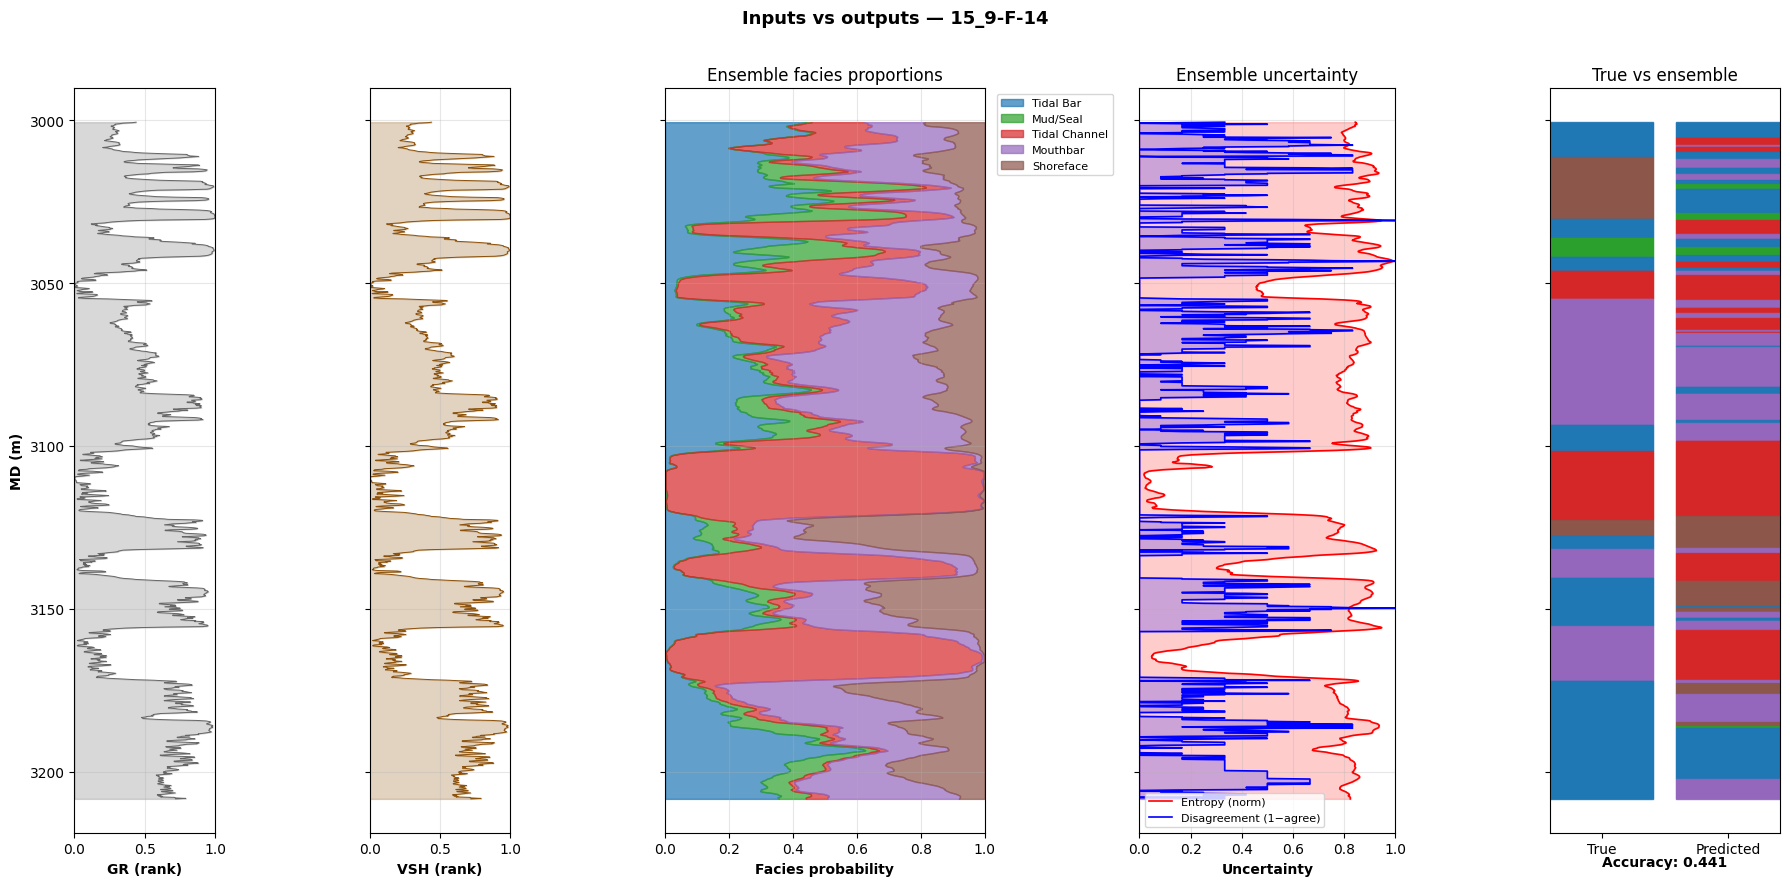

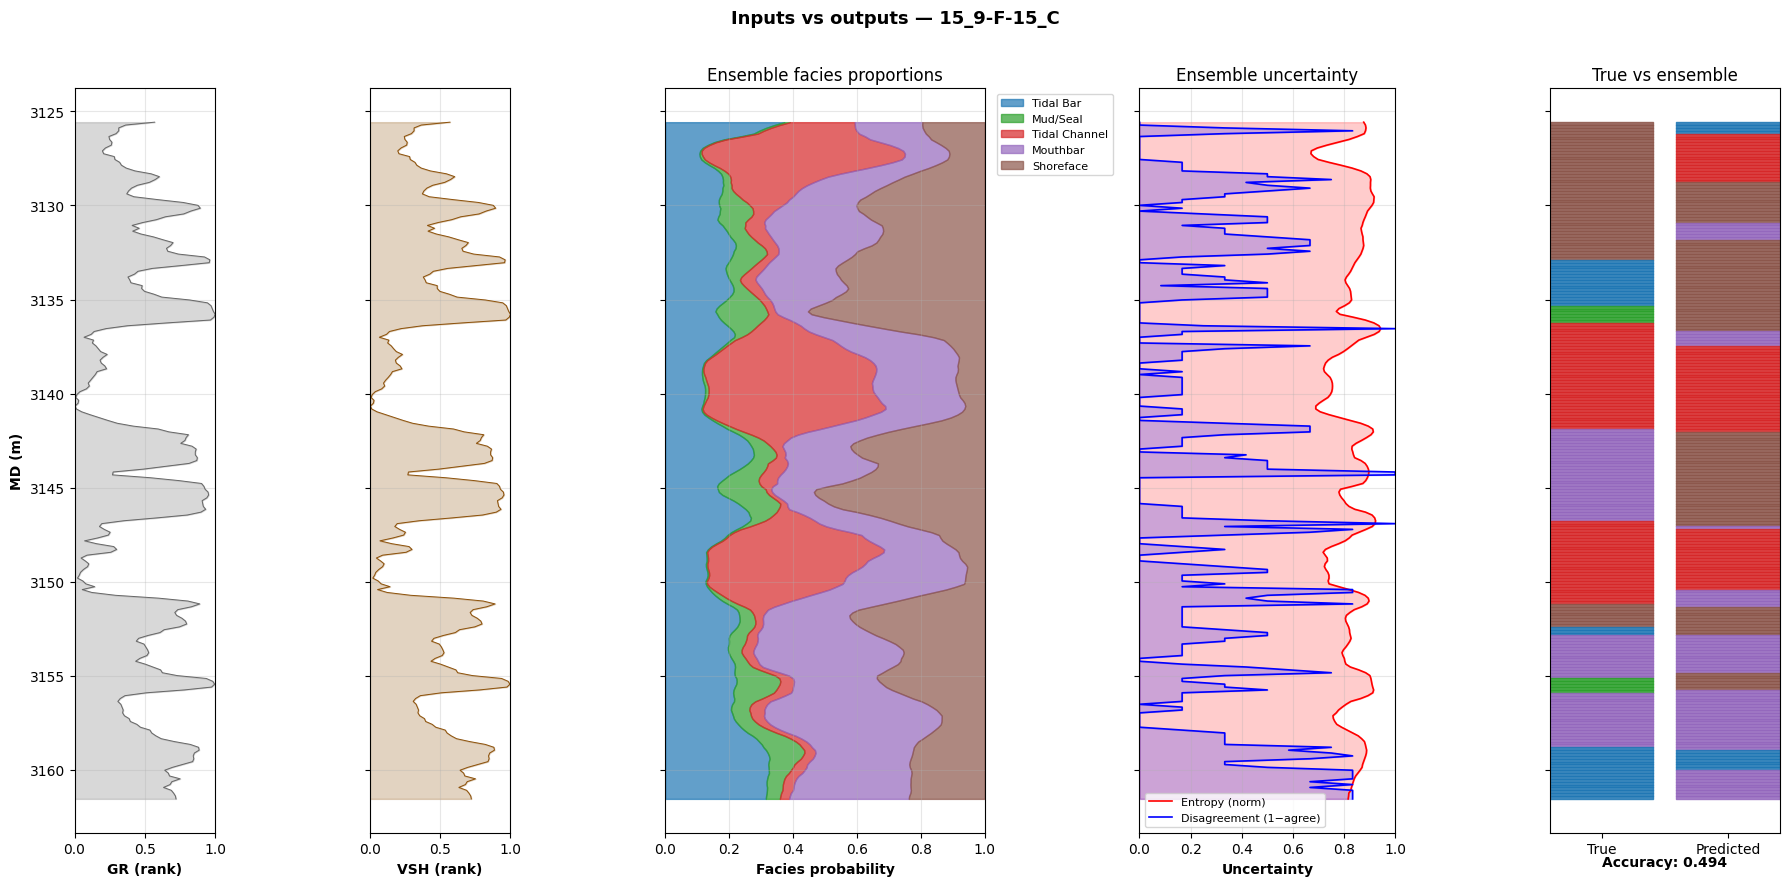

In [23]:
FACIES_LABEL = {0: "Tidal Bar", 2: "Mud/Seal", 3: "Tidal Channel", 4: "Mouthbar", 5: "Shoreface"}
def facies_color(c):
    return plt.cm.tab10(int(c) % 10)                 # stable per-class colour
max_ent = np.log(len(CLASSES))

for well in LOGRICH:
    d = ens_detail[well]
    depth, P, truth, pred = d["md"], d["proba"], d["truth"], d["pred"]
    entropy_norm = d["entropy"] / max_ent
    disagreement = 1.0 - d["agreement"]
    te_w = (df[WELL] == well).values                      # input tracks: the model's actual inputs

    fig, axes = plt.subplots(1, 5, figsize=(18, 9), sharey=True,
                             gridspec_kw={"width_ratios": [0.55, 0.55, 1.25, 1.0, 0.9]})

    # Panels 1-2: input log tracks (per-well rank, what the model actually sees)
    for ax, col, name, color in [(axes[0], f"q::{GR}", "GR (rank)", "#666666"),
                                 (axes[1], f"q::{VSH}", "VSH (rank)", "#8c510a")]:
        ax.plot(X.loc[te_w, col].values, depth, color=color, lw=0.7)
        ax.fill_betweenx(depth, 0, X.loc[te_w, col].values, color=color, alpha=0.25)
        ax.set_xlim(0, 1); ax.set_xlabel(name, fontweight="bold")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("MD (m)", fontweight="bold")
    axes[0].invert_yaxis()

    # Panel 3: stacked facies proportions
    ax = axes[2]; bottom = np.zeros(len(depth))
    for j, c in enumerate(CLASSES):
        ax.fill_betweenx(depth, bottom, bottom + P[:, j], alpha=0.7,
                         label=FACIES_LABEL[c], color=facies_color(c))
        bottom += P[:, j]
    ax.set_xlabel("Facies probability", fontweight="bold")
    ax.set_title("Ensemble facies proportions")
    ax.set_xlim(0, 1)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

    # Panel 4: uncertainty (entropy + disagreement)
    ax = axes[3]
    ax.plot(entropy_norm, depth, "r-", lw=1.2, label="Entropy (norm)")
    ax.fill_betweenx(depth, 0, entropy_norm, alpha=0.2, color="red")
    ax.plot(disagreement, depth, "b-", lw=1.2, label="Disagreement (1\u2212agree)")
    ax.fill_betweenx(depth, 0, disagreement, alpha=0.2, color="blue")
    ax.set_xlabel("Uncertainty", fontweight="bold")
    ax.set_title("Ensemble uncertainty")
    ax.set_xlim(0, 1); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Panel 5: true vs predicted colour strips
    ax = axes[4]
    for i in range(len(depth) - 1):
        seg = [depth[i], depth[i + 1]]
        ax.fill_betweenx(seg, 0.00, 0.45, color=facies_color(truth[i]), alpha=0.85)
        ax.fill_betweenx(seg, 0.55, 1.00, color=facies_color(pred[i]),  alpha=0.85)
    ax.set_xticks([0.225, 0.775]); ax.set_xticklabels(["True", "Predicted"])
    ax.set_xlim(0, 1); ax.set_title("True vs ensemble")
    ax.text(0.5, -0.045, f"Accuracy: {accuracy_score(truth, pred):.3f}",
            transform=ax.transAxes, ha="center", fontweight="bold")

    fig.suptitle(f"Inputs vs outputs \u2014 {well}", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

## Step 10: Alternative conditioning scenarios (P1 / P2 / P3)

A single "most-likely" log throws away the model's uncertainty. For geostatistical conditioning (and for honest interpretation) it is more useful to carry **several plausible realizations** of the facies column. We extract three scenarios from the ensemble's averaged probabilities by ranking, at every depth, the Top-1 / Top-2 / Top-3 most probable facies:

- **P1 (most probable):** Top-1 everywhere. This is the standard prediction (same labels as Step 9).
- **P2 (alternative):** keep Top-1 where the model is confident, but fall back to the Top-2 facies wherever Top-1 probability `< 0.6`. The "what else is plausible here?" realization.
- **P3 (extreme):** as P2, but drop to the Top-3 facies wherever Top-1 probability `< 0.4`. The most divergent realization, used to explore the tails.

The thresholds (0.6 / 0.4) are the defaults used here. In the plots below, depths where the alternative was actually triggered are drawn at full opacity and confident (Top-1) depths are faded, so you can see *where* the scenarios disagree. P2/P3 accuracies are shown with their change versus P1. They are expected to be ≤ P1 (we are deliberately swapping in less-likely labels); the point is to bracket uncertainty, not to beat P1. One figure per well, F-5 included as the example.

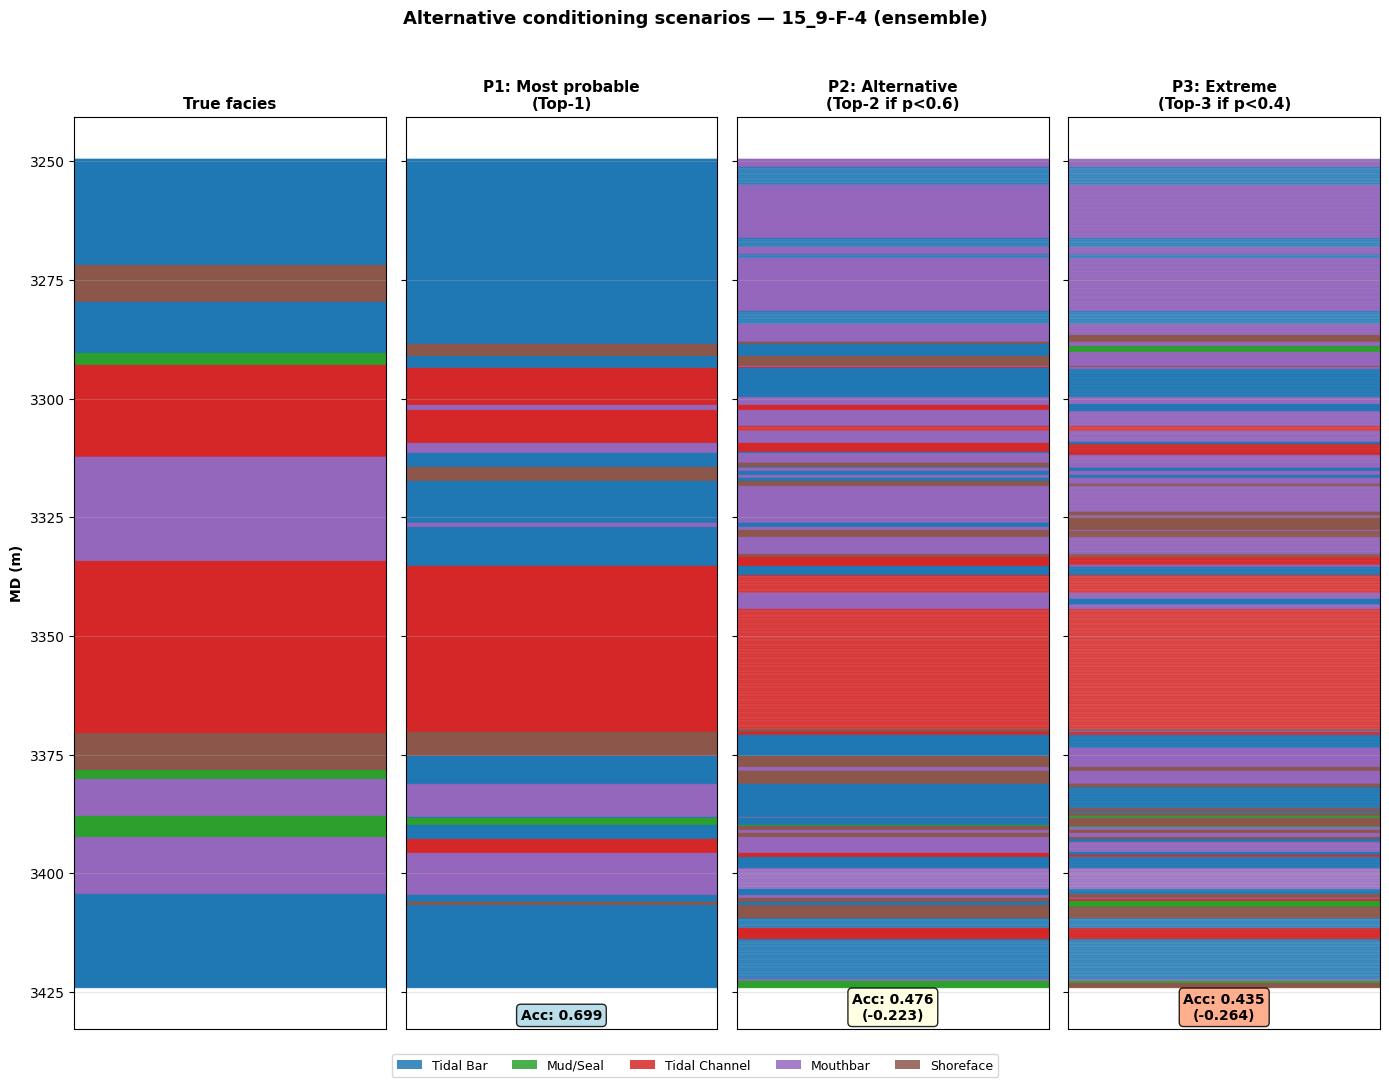

15_9-F-4     P1=0.699 | P2=0.476 (-0.223) | P3=0.435 (-0.264)  | alternative triggered: P2 68% of depths, P3-extreme 22%


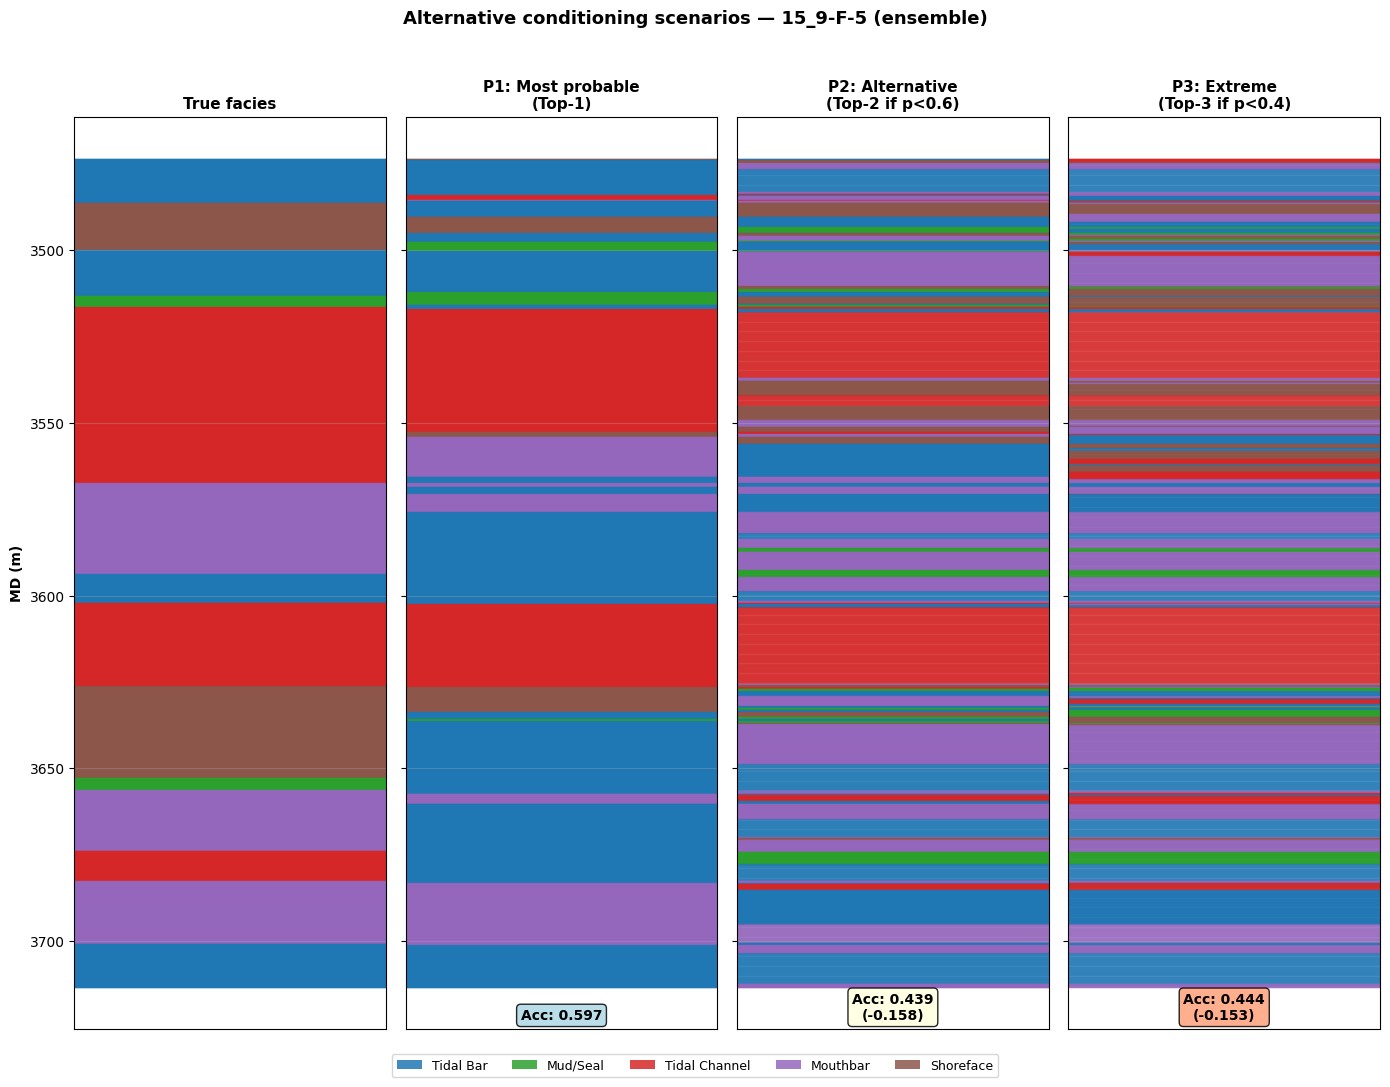

15_9-F-5     P1=0.597 | P2=0.439 (-0.158) | P3=0.444 (-0.153)  | alternative triggered: P2 64% of depths, P3-extreme 17%


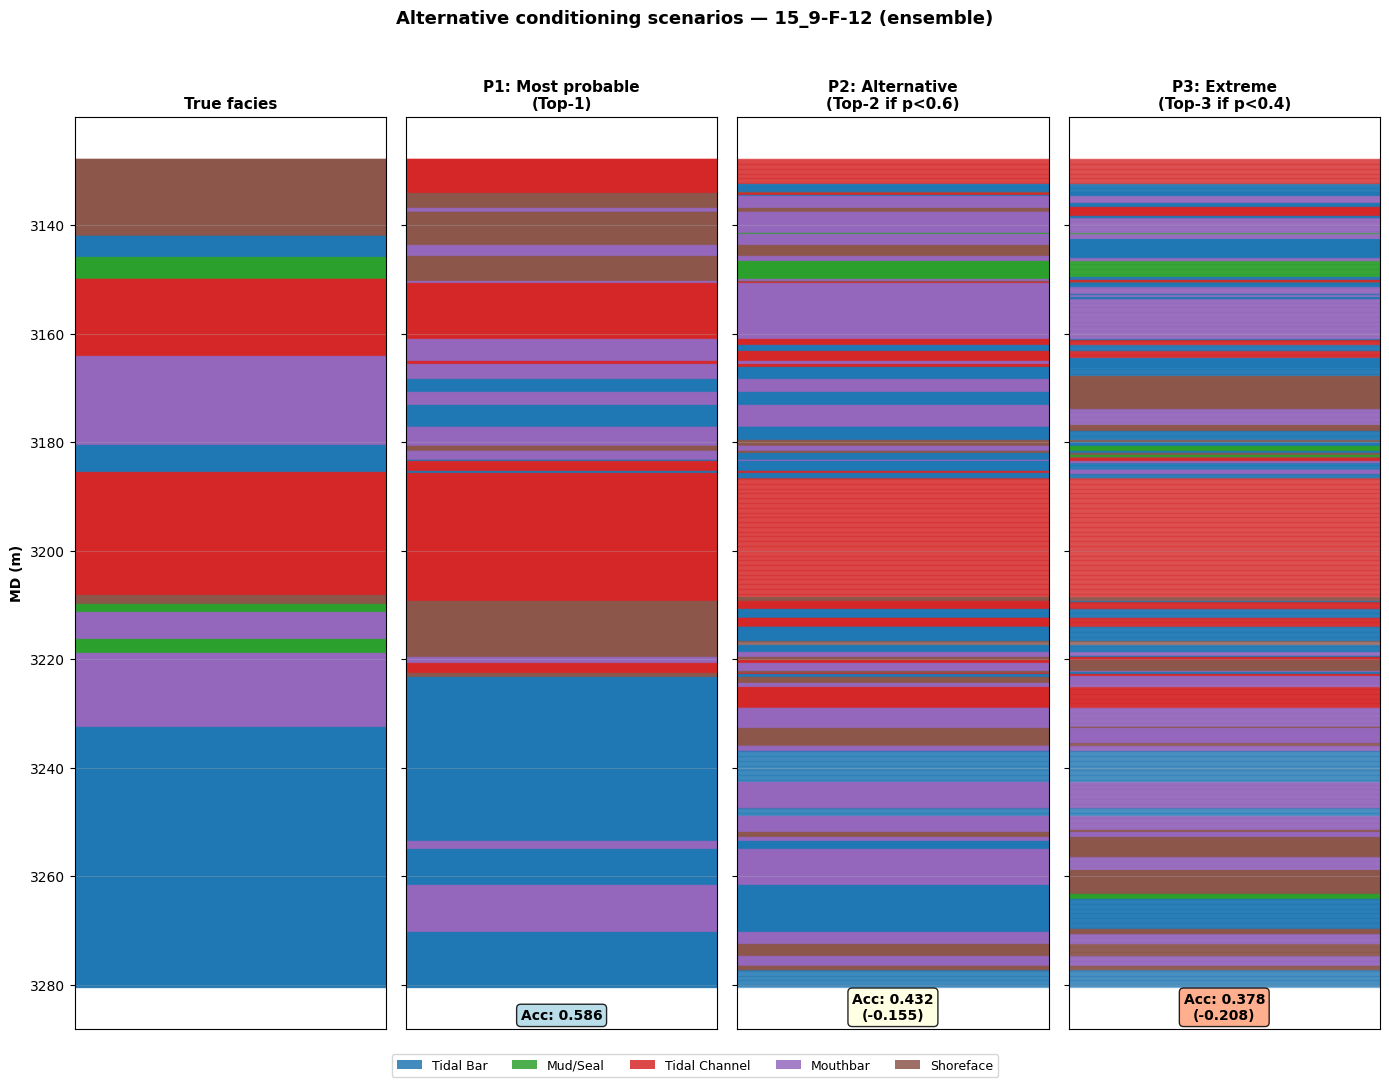

15_9-F-12    P1=0.586 | P2=0.432 (-0.155) | P3=0.378 (-0.208)  | alternative triggered: P2 75% of depths, P3-extreme 28%


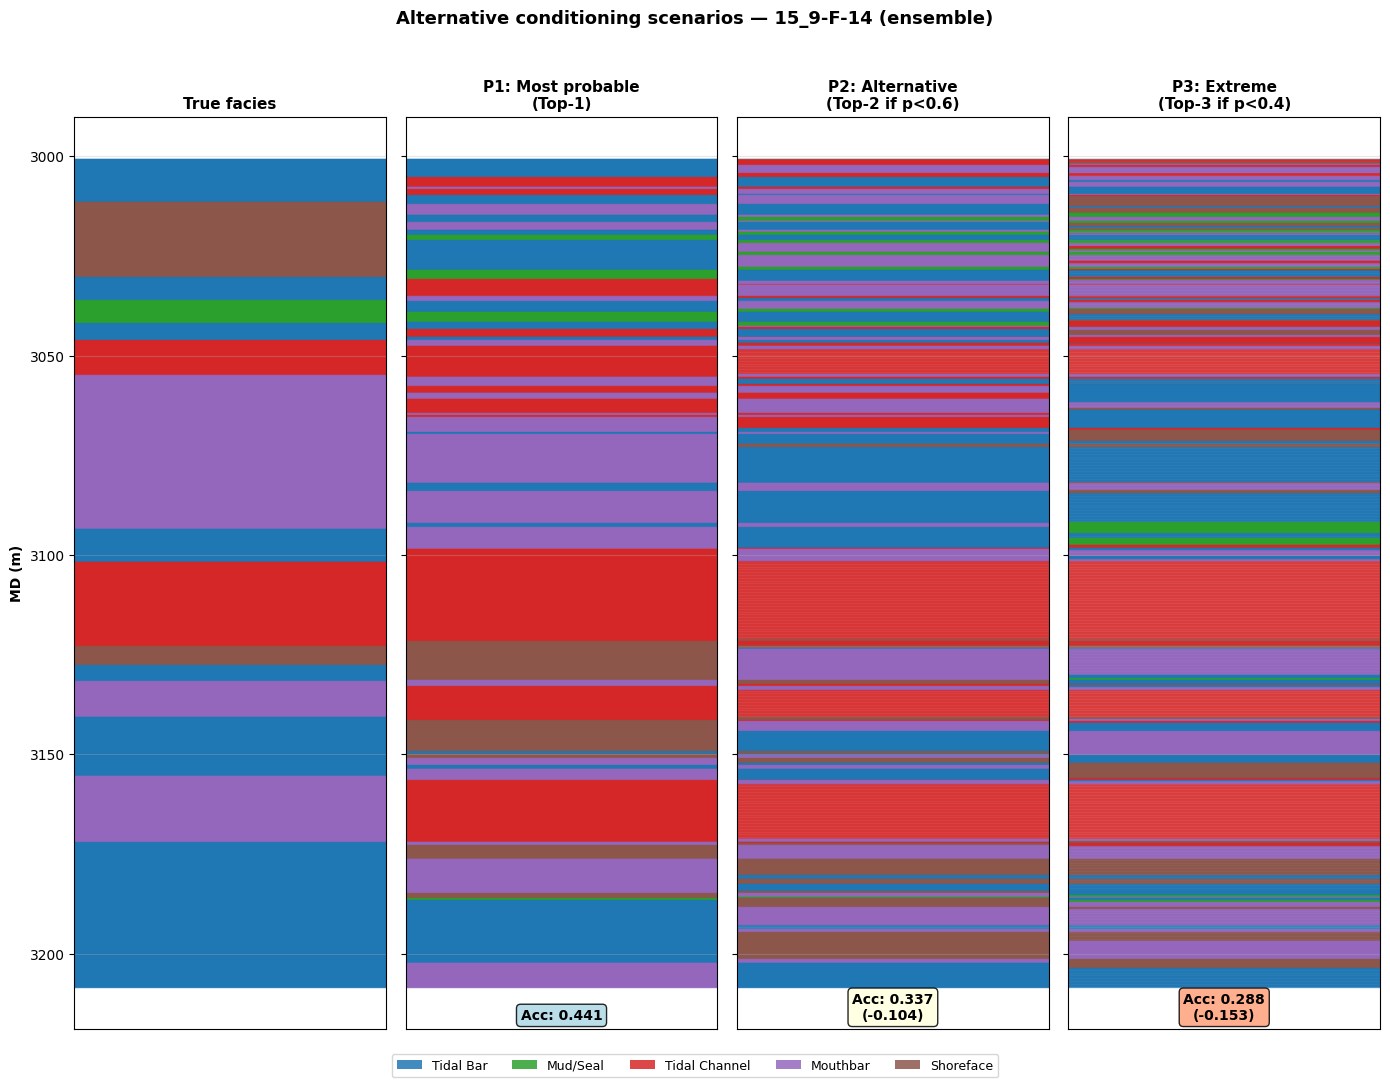

15_9-F-14    P1=0.441 | P2=0.337 (-0.104) | P3=0.288 (-0.153)  | alternative triggered: P2 77% of depths, P3-extreme 37%


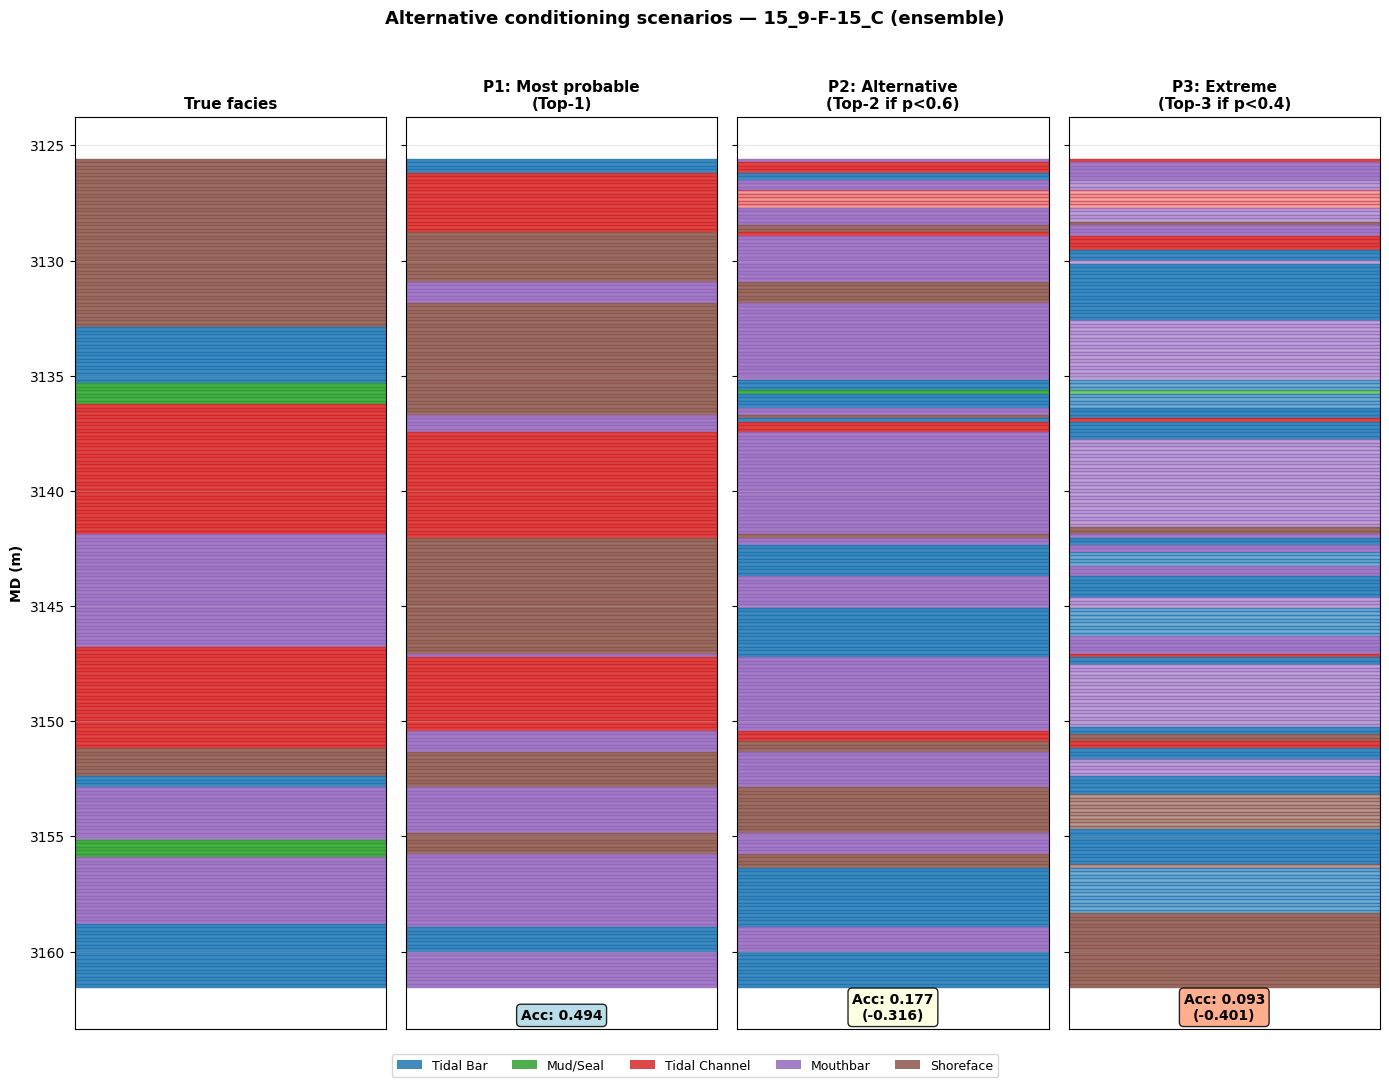

15_9-F-15_C  P1=0.494 | P2=0.177 (-0.316) | P3=0.093 (-0.401)  | alternative triggered: P2 98% of depths, P3-extreme 47%


In [24]:
import matplotlib.patches as mpatches

TH_P2, TH_P3 = 0.6, 0.4                       # Top-2 below 0.6, Top-3 below 0.4
classes_arr = np.array(CLASSES)

for well in LOGRICH:
    d = ens_detail[well]
    depth, P, truth = d["md"], d["proba"], d["truth"]

    order = np.argsort(P, axis=1)[:, ::-1]              # columns ranked by descending probability
    top_facies = classes_arr[order]                     # facies labels ranked per depth (n x 5)
    p1 = np.take_along_axis(P, order, axis=1)[:, 0]     # Top-1 probability
    t1, t2, t3 = top_facies[:, 0], top_facies[:, 1], top_facies[:, 2]

    P1 = t1
    P2 = np.where(p1 < TH_P2, t2, t1)
    P3 = np.where(p1 < TH_P3, t3, np.where(p1 < TH_P2, t2, t1))
    used2_p2 = p1 < TH_P2
    used3_p3 = p1 < TH_P3
    used2_p3 = (p1 >= TH_P3) & (p1 < TH_P2)

    a1, a2, a3 = (accuracy_score(truth, P1), accuracy_score(truth, P2), accuracy_score(truth, P3))

    fig, axes = plt.subplots(1, 4, figsize=(14, 11), sharey=True)
    panels = [
        ("True facies", truth, None, "white"),
        ("P1: Most probable\n(Top-1)", P1, f"Acc: {a1:.3f}", "lightblue"),
        (f"P2: Alternative\n(Top-2 if p<{TH_P2})", P2, f"Acc: {a2:.3f}\n({a2 - a1:+.3f})", "lightyellow"),
        (f"P3: Extreme\n(Top-3 if p<{TH_P3})", P3, f"Acc: {a3:.3f}\n({a3 - a1:+.3f})", "lightsalmon"),
    ]
    for k, (title, col, note, boxc) in enumerate(panels):
        ax = axes[k]
        for i in range(len(depth) - 1):
            if k == 2:        # P2: fade confident (Top-1) depths
                al = 0.85 if used2_p2[i] else 0.45
            elif k == 3:      # P3: full / mid / faded for Top-3 / Top-2 / Top-1
                al = 0.85 if used3_p3[i] else (0.6 if used2_p3[i] else 0.4)
            else:
                al = 0.85
            ax.fill_betweenx([depth[i], depth[i + 1]], 0, 1, color=facies_color(col[i]), alpha=al)
        ax.set_title(title, fontweight="bold", fontsize=11)
        ax.set_xlim(0, 1); ax.set_xticks([]); ax.grid(True, alpha=0.3, axis="y")
        if note:
            ax.text(0.5, 0.01, note, transform=ax.transAxes, ha="center", fontweight="bold",
                    bbox=dict(boxstyle="round", facecolor=boxc, alpha=0.85))
    axes[0].set_ylabel("MD (m)", fontweight="bold"); axes[0].invert_yaxis()

    handles = [mpatches.Patch(facecolor=facies_color(c), label=FACIES_LABEL[c], alpha=0.85) for c in CLASSES]
    fig.legend(handles=handles, loc="center", bbox_to_anchor=(0.5, 0.03), ncol=5, frameon=True, fontsize=9)
    fig.suptitle(f"Alternative conditioning scenarios \u2014 {well} (ensemble)",
                 fontsize=13, fontweight="bold", y=0.99)
    fig.tight_layout(rect=[0, 0.05, 1, 0.97]); plt.show()

    print(f"{well:12s} P1={a1:.3f} | P2={a2:.3f} ({a2 - a1:+.3f}) | P3={a3:.3f} ({a3 - a1:+.3f})  "
          f"| alternative triggered: P2 {used2_p2.mean()*100:.0f}% of depths, P3-extreme {used3_p3.mean()*100:.0f}%")

## Step 10a: The scenarios as alternative depositional architectures

P1/P2/P3 are extracted by a probability rule, so it is fair to ask: **are they geologically meaningful alternatives**, or just noise around P1? This section reads them as depositional scenarios in the sense of Kieft et al. (2011), using three summaries computed below: facies proportions, bed-thickness statistics, and vertical facies-transition matrices, each compared with the cored truth.

**What an "alternative depo scenario" means here.** Kieft et al.'s Hugin model has two end-member systems sharing the same log space: a transgressive, tide-dominated** family (tidal bars, tidal channels, heterolithic tidal flats) and a regressive, wave/river-dominated family (prograding mouthbars, shoreface). Most of the model's uncertainty (Step 8: the Tidal Bar ↔ Mouthbar ↔ Shoreface confusion) is exactly the ambiguity between these two families: a sand with weak trends can be read as either. The P2/P3 rule ("where Top-1 probability is low, take the next-most-probable facies") therefore swaps labels almost exclusively within the sandy trio and toward the mud/seal class, i.e. it re-reads ambiguous intervals as the other depositional family. That is precisely the prior-scenario logic the conceptual model allows:

- **P1. Most-likely architecture**: the base-case reading.
- **P2. Alternative family reading**: confident intervals unchanged; ambiguous sands re-assigned to the competing end-member (a bar re-read as a mouthbar is a switch from a tide-dominated to a wave-dominated interpretation of the same clean-sand motif).
- **P3. Extreme / heterolithic reading**: ambiguous intervals pushed to the third candidate; architecturally this is the thin-bedded, most heterogeneous member of the family, useful as the downside case for connectivity.

**What the summaries show (computed below).**

1. **Proportions** shift exactly along the two-family axis, not to arbitrary classes: P2/P3 move volume from the tidal sands (Tidal Bar 38% → ~28–30%, Channel 29% → ~24%) into Mouthbar (20% → ~32–34%) and into Mud/Seal (1.8% → 3–4%). Notably, for Tidal Bar and Mud/Seal the alternative scenarios land closer to the cored truth (30.4% and 3.8%) than P1 does. The alternatives correct P1's known bias of over-calling tidal sand and under-calling seal, which is what a useful downside scenario should do.
2. **Bed thickness** decreases monotonically P1 → P2 → P3 (more, thinner intervals): the alternative scenarios are progressively more interbedded versions of the same column. Note the deliberate consequence for geomodelling: P1 brackets the thick-bedded/connected end, P3 the thin-bedded/compartmentalised end of the architecture space. (All predicted columns are thinner-bedded than the cored truth — sample-wise classification fragments beds; the Step 5 smoothing reduces but does not remove this.)
3. **Transitions** concentrate in the same cells as the truth: Mouthbar ↔ Tidal Bar contacts and Channel → Mouthbar successions dominate every column, in the same rank order as the cored record. The scenarios multiply the number of contacts (consequence of the thinner beds) but preserve *which* contacts are common — they respect the succession logic of the depositional model rather than shuffling facies randomly.

> For conditioning a static model, this gives the three realizations a geological identity: **P1 = tide-dominated base case, P2 = wave/river-shifted alternative, P3 = heterolithic downside** — not three arbitrary samples of classifier noise.

pooled facies proportions (%):
               truth    P1    P2    P3
Tidal Bar       30.4  38.0  29.8  27.6
Mud/Seal         3.8   1.8   3.0   4.0
Tidal Channel   26.7  29.4  23.5  24.1
Mouthbar        26.3  19.8  33.6  31.5
Shoreface       12.8  11.0  10.0  12.8

interval statistics (pooled over the 5 wells):
             truth      P1      P2      P3
n_intervals  67.00  153.00  372.00  465.00
median_m      8.23    2.44    1.07    0.76
mean_m       12.11    5.30    2.18    1.74


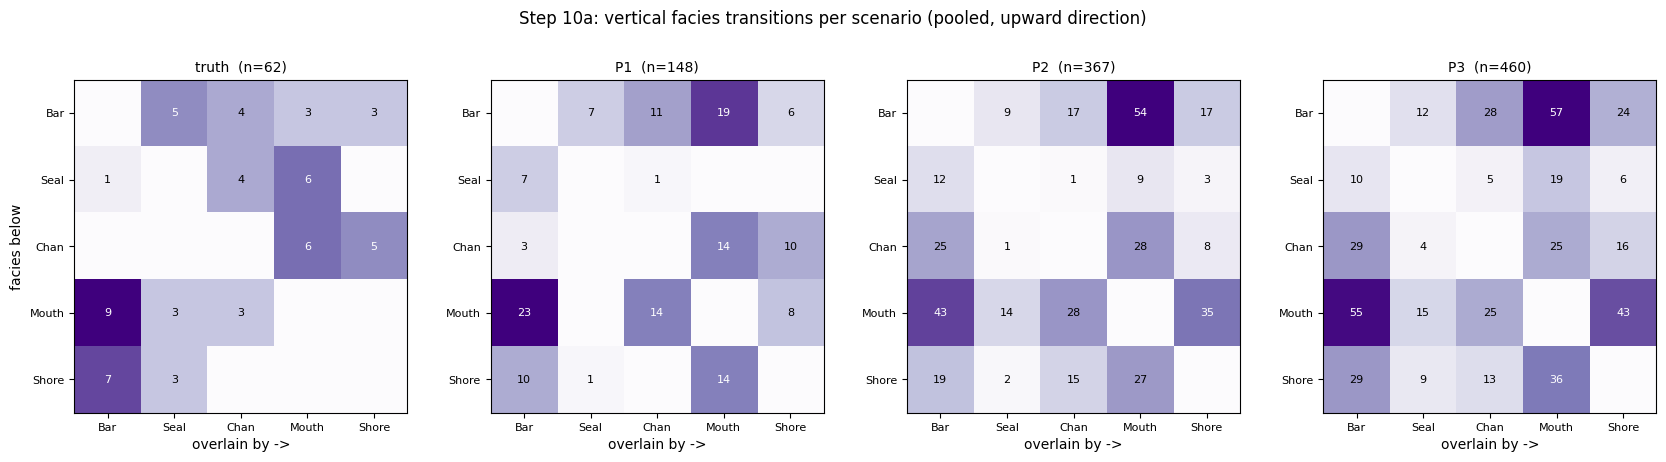

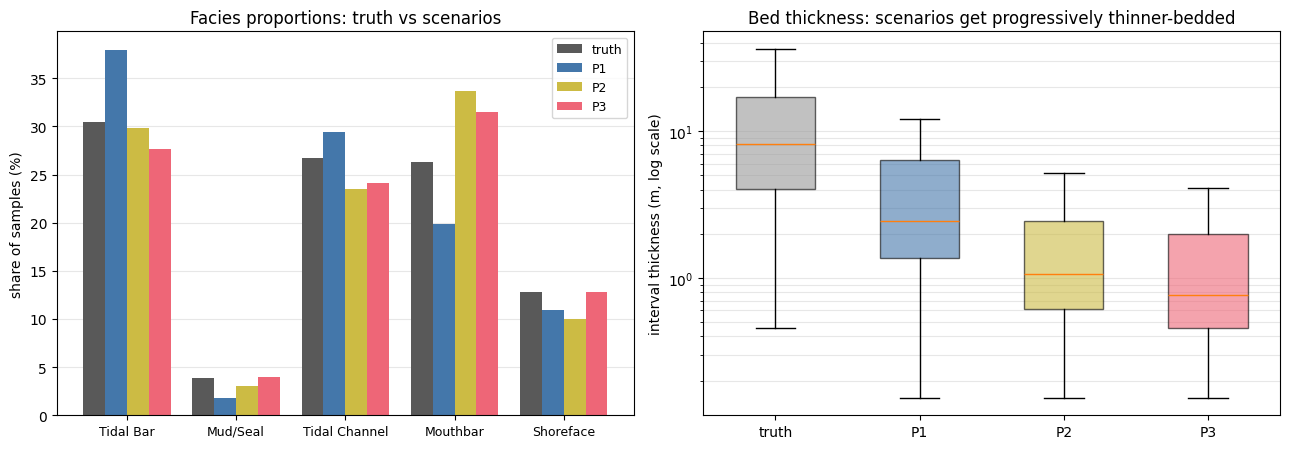

In [25]:
# Step 10a: what do P1/P2/P3 look like as depositional architectures?
# Rebuild the three scenario columns from the ensemble probabilities (same rule as Step 10),
# then compare facies proportions, bed thickness and facies transitions against the cored truth.

scen_cols = {"truth": {}, "P1": {}, "P2": {}, "P3": {}}
for well in LOGRICH:
    dd = ens_detail[well]
    P = dd["proba"]
    order = np.argsort(P, axis=1)[:, ::-1]
    topf = classes_arr[order]
    p1 = np.take_along_axis(P, order, axis=1)[:, 0]
    t1, t2, t3 = topf[:, 0], topf[:, 1], topf[:, 2]
    scen_cols["truth"][well] = dd["truth"]
    scen_cols["P1"][well] = t1
    scen_cols["P2"][well] = np.where(p1 < TH_P2, t2, t1)
    scen_cols["P3"][well] = np.where(p1 < TH_P3, t3, np.where(p1 < TH_P2, t2, t1))

SCEN = ["truth", "P1", "P2", "P3"]

# --- (1) pooled facies proportions per scenario ---
prop = {}
for s in SCEN:
    allv = np.concatenate([scen_cols[s][w] for w in LOGRICH])
    prop[s] = pd.Series(allv).value_counts(normalize=True).reindex(CLASSES).fillna(0) * 100
prop = pd.DataFrame(prop)
prop.index = [FACIES_LABEL[c] for c in CLASSES]
print("pooled facies proportions (%):")
print(prop.round(1).to_string())

# --- (2) interval thickness per scenario (facies_intervals from Step 3a) ---
th_rows = {}
scen_intervals = {}
for s in SCEN:
    ivs = []
    for w in LOGRICH:
        md_w = df.loc[df[WELL] == w, MD].values
        ivs.append(facies_intervals(md_w, scen_cols[s][w]))
    ivs = pd.concat(ivs, ignore_index=True)
    scen_intervals[s] = ivs
    th_rows[s] = {"n_intervals": len(ivs),
                  "median_m": ivs["thickness_m"].median(),
                  "mean_m": ivs["thickness_m"].mean()}
print("\ninterval statistics (pooled over the 5 wells):")
print(pd.DataFrame(th_rows).round(2).to_string())

# --- (3) facies transition matrices ---
def transition_counts(labels):
    T = pd.DataFrame(0, index=CLASSES, columns=CLASSES)
    a = np.asarray(labels)
    for i, j in zip(a[:-1], a[1:]):
        if i != j:
            T.loc[i, j] += 1
    return T

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
short = {0: "Bar", 2: "Seal", 3: "Chan", 4: "Mouth", 5: "Shore"}
for ax, s in zip(axes, SCEN):
    T = sum(transition_counts(scen_cols[s][w]) for w in LOGRICH)
    Tn = T.values / max(T.values.sum(), 1)
    ax.imshow(Tn, cmap="Purples", vmin=0, vmax=Tn.max())
    ax.set_xticks(range(5)); ax.set_xticklabels([short[c] for c in CLASSES], fontsize=8)
    ax.set_yticks(range(5)); ax.set_yticklabels([short[c] for c in CLASSES], fontsize=8)
    for i in range(5):
        for j in range(5):
            if T.values[i, j]:
                ax.text(j, i, T.values[i, j], ha="center", va="center", fontsize=8,
                        color="white" if Tn[i, j] > 0.55 * Tn.max() else "black")
    ax.set_title(f"{s}  (n={T.values.sum()})", fontsize=10)
    ax.set_xlabel("overlain by ->")
axes[0].set_ylabel("facies below")
fig.suptitle("Step 10a: vertical facies transitions per scenario (pooled, upward direction)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

# --- proportions + thickness figure ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
xx = np.arange(len(CLASSES)); wdt = 0.2
for k, s in enumerate(SCEN):
    ax.bar(xx + (k - 1.5) * wdt, prop[s].values, wdt,
           label=s, color=["0.35", "#4477aa", "#ccbb44", "#ee6677"][k])
ax.set_xticks(xx); ax.set_xticklabels([FACIES_LABEL[c] for c in CLASSES], fontsize=9)
ax.set_ylabel("share of samples (%)")
ax.set_title("Facies proportions: truth vs scenarios")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)

ax = axes[1]
data = [scen_intervals[s]["thickness_m"].values for s in SCEN]
bp = ax.boxplot(data, tick_labels=SCEN, showfliers=False, widths=0.55, patch_artist=True)
for patch, c in zip(bp["boxes"], ["0.6", "#4477aa", "#ccbb44", "#ee6677"]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_yscale("log")
ax.set_ylabel("interval thickness (m, log scale)")
ax.set_title("Bed thickness: scenarios get progressively thinner-bedded")
ax.grid(axis="y", alpha=0.3, which="both"); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

## Step 11: Discrimination experts (pair-aware re-weighting)

The ensemble in Step 9 gives every one of its 12 members an equal vote. But the members are built from different feature views, and a view that captures bed-scale texture may separate *Tidal Channel vs Mouthbar* far better than a view built for body-scale trends, even if, averaged over all facies, the two views score the same. Equal voting throws that specialisation away exactly where it matters: on the most-confused pairs.

Step 11 puts it back. The procedure is deliberately leakage-free:

1. **Find the confused pairs.** From the baseline ensemble's pooled confusion matrix we take the handful of facies pairs that are mixed up most often.
2. **Identify the experts, on training wells only.** For each blind-well rotation we already hold out-of-fold predictions for every feature view on the four training wells (computed in Step 9; the blind well is never involved). For each confused pair `(A, B)` we score each view by how cleanly it separates that pair, `score = pair_accuracy · (1 − confusion_rate)`, and keep the top-3 expert views. Out-of-fold scoring is essential here: in-sample a depth-25 random forest separates everything perfectly, so it could not tell the views apart.
3. **Defer to the experts on the blind well.** For each depth, if the ensemble's two most-likely facies form a confused pair, we recompute that sample's probabilities using only the expert views for that pair (an exclusive re-weighting); everywhere else the equal vote stands.

We then compare the discrimination-weighted prediction against the equal-vote baseline: overall, per well, and on the confused pairs themselves.

In [26]:
# --- 1. most-confused (unordered) facies pairs, from the baseline ensemble ---
cm_pool = confusion_matrix(eyt, eyp, labels=CLASSES)
conf = {(a, b): int(cm_pool[i, j] + cm_pool[j, i])
        for i, a in enumerate(CLASSES) for j, b in enumerate(CLASSES) if a < b}
TOP_PAIRS = [p for p, _ in sorted(conf.items(), key=lambda kv: kv[1], reverse=True)[:5]]
PAIR_SET  = set(TOP_PAIRS)
view_list = list(VIEWS)
TOPK = 3                                                    # expert views kept per confused pair

def disc_score(oof_pred, ytr, a, b):
    """How cleanly a view's out-of-fold predictions separate facies a vs b on the training wells."""
    m = np.isin(ytr, [a, b])
    if m.sum() < 10:
        return np.nan
    yt, yp = ytr[m], oof_pred[m]
    cab = np.sum((yt == a) & (yp == b)) + np.sum((yt == b) & (yp == a))
    return float(np.mean(yt == yp) * (1 - cab / m.sum()))

# --- 2. per well: rank expert views (training-only) and re-weight the blind prediction ---
disc_sum = np.zeros((len(view_list), len(TOP_PAIRS))); disc_cnt = np.zeros_like(disc_sum)
perwell_acc, bp_all, dp_all, tr_all = {}, [], [], []
for well in LOGRICH:
    d = ens_detail[well]
    mprobs, mview, oof, ytr = d["mprobs"], np.array(d["mview"]), d["oof_view"], d["ytr"]
    avg = mprobs.mean(axis=0)                               # equal-vote baseline (unsmoothed)

    experts = {}
    for pj, (a, b) in enumerate(TOP_PAIRS):
        ranked = []
        for vi, v in enumerate(view_list):
            s = disc_score(oof[v], ytr, a, b)
            if not np.isnan(s):
                disc_sum[vi, pj] += s; disc_cnt[vi, pj] += 1; ranked.append((v, s))
        ranked.sort(key=lambda t: t[1], reverse=True)
        experts[(a, b)] = [v for v, _ in ranked[:TOPK]]

    final = avg.copy()
    for i in range(avg.shape[0]):
        order = np.argsort(avg[i])[::-1]
        pair = tuple(sorted((CLASSES[order[0]], CLASSES[order[1]])))
        if pair in PAIR_SET and experts[pair]:
            keep = np.isin(mview, experts[pair])
            if keep.any():
                final[i] = mprobs[keep, i, :].mean(axis=0)

    bpred = np.array(CLASSES)[np.argmax(smooth(avg),   axis=1)]
    dpred = np.array(CLASSES)[np.argmax(smooth(final), axis=1)]
    perwell_acc[well] = (accuracy_score(d["truth"], bpred), accuracy_score(d["truth"], dpred))
    bp_all.append(bpred); dp_all.append(dpred); tr_all.append(d["truth"])

bp_all, dp_all, tr_all = np.concatenate(bp_all), np.concatenate(dp_all), np.concatenate(tr_all)
disc_mat = np.divide(disc_sum, disc_cnt, out=np.zeros_like(disc_sum), where=disc_cnt > 0)
base_acc, disc_acc = accuracy_score(tr_all, bp_all), accuracy_score(tr_all, dp_all)

print("most-confused pairs (baseline off-diagonal counts):")
for p in TOP_PAIRS:
    print(f"  {FACIES_LABEL[p[0]]:13s} vs {FACIES_LABEL[p[1]]:13s}  n={conf[p]}")
print(f"\npooled facies accuracy:  baseline {base_acc:.3f}  ->  discrimination {disc_acc:.3f}  ({(disc_acc-base_acc)*100:+.2f} pp)")
print(f"pooled tier  accuracy:  baseline {tier_acc(tr_all, bp_all):.3f}  ->  discrimination {tier_acc(tr_all, dp_all):.3f}")

most-confused pairs (baseline off-diagonal counts):
  Tidal Bar     vs Mouthbar       n=765
  Tidal Bar     vs Shoreface      n=484
  Tidal Channel vs Mouthbar       n=368
  Tidal Bar     vs Tidal Channel  n=209
  Mouthbar      vs Shoreface      n=136

pooled facies accuracy:  baseline 0.572  ->  discrimination 0.573  (+0.06 pp)
pooled tier  accuracy:  baseline 0.637  ->  discrimination 0.645


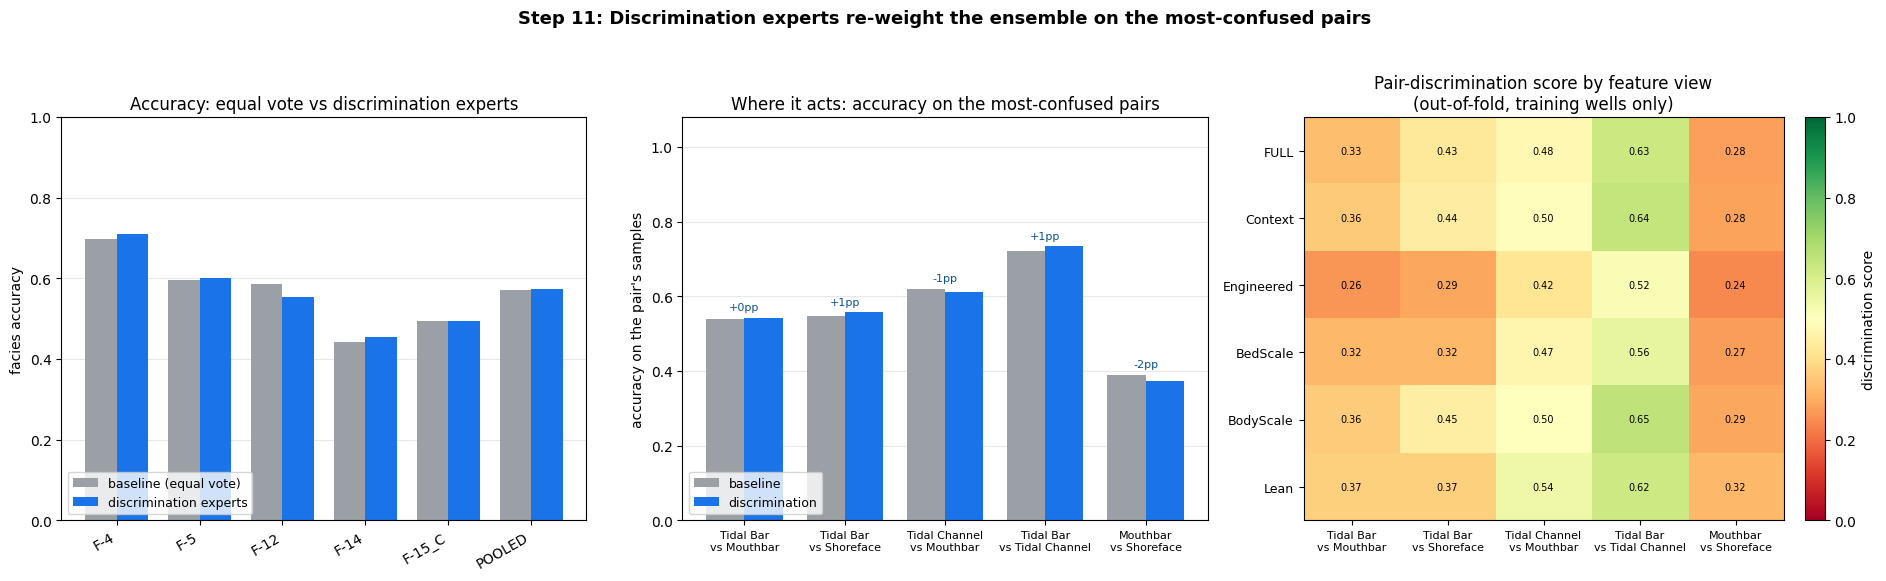

In [27]:
pair_lbl = [f"{FACIES_LABEL[a]}\nvs {FACIES_LABEL[b]}" for a, b in TOP_PAIRS]
W = 0.38
fig, axes = plt.subplots(1, 3, figsize=(19, 5.6))

# (1) per-well + pooled accuracy
ax = axes[0]
wells = LOGRICH + ["POOLED"]
bvals = [perwell_acc[w][0] for w in LOGRICH] + [base_acc]
dvals = [perwell_acc[w][1] for w in LOGRICH] + [disc_acc]
xx = np.arange(len(wells))
ax.bar(xx - W/2, bvals, W, label="baseline (equal vote)", color="#9aa0a6")
ax.bar(xx + W/2, dvals, W, label="discrimination experts", color="#1a73e8")
ax.set_xticks(xx); ax.set_xticklabels([s.replace("15_9-", "") for s in wells], rotation=30, ha="right")
ax.set_ylabel("facies accuracy"); ax.set_ylim(0, 1); ax.legend(fontsize=9, loc="lower left")
ax.set_title("Accuracy: equal vote vs discrimination experts")
ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)

# (2) accuracy on the confused-pair samples (truth in pair), pooled
ax = axes[1]
pb, pd_ = [], []
for (a, b) in TOP_PAIRS:
    m = np.isin(tr_all, [a, b])
    pb.append(accuracy_score(tr_all[m], bp_all[m]))
    pd_.append(accuracy_score(tr_all[m], dp_all[m]))
xx = np.arange(len(TOP_PAIRS))
ax.bar(xx - W/2, pb, W, label="baseline", color="#9aa0a6")
ax.bar(xx + W/2, pd_, W, label="discrimination", color="#1a73e8")
for i, (a, b) in enumerate(TOP_PAIRS):
    ax.text(i, max(pb[i], pd_[i]) + 0.02, f"{(pd_[i]-pb[i])*100:+.0f}pp", ha="center", fontsize=8, color="#0b5394")
ax.set_xticks(xx); ax.set_xticklabels(pair_lbl, fontsize=8)
ax.set_ylabel("accuracy on the pair's samples"); ax.set_ylim(0, 1.08); ax.legend(fontsize=9, loc="lower left")
ax.set_title("Where it acts: accuracy on the most-confused pairs")
ax.grid(axis="y", alpha=0.3); ax.set_axisbelow(True)

# (3) which view is the expert for which pair (out-of-fold, training wells)
ax = axes[2]
im = ax.imshow(disc_mat, aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(TOP_PAIRS))); ax.set_xticklabels(pair_lbl, fontsize=8)
ax.set_yticks(range(len(view_list))); ax.set_yticklabels(view_list, fontsize=9)
for vi in range(len(view_list)):
    for pj in range(len(TOP_PAIRS)):
        ax.text(pj, vi, f"{disc_mat[vi, pj]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Pair-discrimination score by feature view\n(out-of-fold, training wells only)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="discrimination score")

fig.suptitle("Step 11: Discrimination experts re-weight the ensemble on the most-confused pairs",
             fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout(); plt.show()

## Summary

End to end, the pipeline is:

```
raw logs -> keep labelled + 5 log-rich wells -> merge to 5 classes
        -> engineer ~117 features, rank-normalized per well (multi-scale context is the key block)
        -> RandomForest 800 trees (leave-one-well-out) -> depth-smooth probabilities -> prediction
        -> [optional] 12-model ensemble (6 views x 2 metrics, soft vote)
```

**What we get:** pooled facies acc ~0.58 (single RF), pooled tier acc ~0.65, macro-F1 ~0.50, ~99% of net pay captured, only ~4% catastrophic pay↔seal swaps, ~98% of samples within one quality tier.

**Why it works:** the multi-scale depth-context features encode the bed-to-formation-scale Hugin facies motifs of Kieft et al. (2011) that a single-depth log can't, with no leakage (computed and normalized strictly within each well, labels never used). Per-well rank normalization (Step 4) is what makes those features transfer between wells: it removes calibration and distribution-shape differences, lifting blind accuracy by +2.2 pp over z-scores (consistent across seeds; McNemar p ≈ 1×10⁻⁵; confirmed by nested selection on training wells only).

**What the ensemble is for (Step 9):** with the rank-normalized features the single FULL model already beats the 12-model soft vote on raw accuracy (~0.58 vs ~0.57): the views' errors are no longer decorrelated enough to pay for the dilution. The ensemble's remaining value is uncertainty quantification: per-sample model agreement / entropy / margin, and the P1/P2/P3 scenario realizations of Step 10 used for geostatistical conditioning.

**Known weak spot & next step:** Seal (class 2) is under-detected because it's rare (~4% of rows; recall ~0.22). Two tested knobs can trade accuracy for seal detection, both re-measured under this final configuration in Appendix E1: a nested-tuned seal-probability threshold (+12 pp seal recall for −0.2 pp accuracy, macro-F1 actually improves 0.501 → 0.510) and HMM decoding with a training-well transition matrix (seal recall ~0.66, but facies accuracy drops ~6 pp and the critical pay↔seal error quadruples, because the balanced RF probabilities double-count the class prior). Neither is enabled by default; the threshold knob is the recommended dial when seal detection matters more than per-sample accuracy.

# Appendix: side experiments and alternatives considered

The main pipeline above is the end result of many comparisons. This appendix collects the experiments that did not make it into the main workflow but answer the natural "did you try ...?" questions. Each entry states the question, the setup (what changes relative to the main pipeline), and the result. Entries A1, A2, D3 and E1 are executed live in this notebook (their code cells run after the main pipeline and reuse its fitted state); B, C, D1 and D2 are documentary, their headline numbers come from the old (v5) experiment ledger and the recorded outputs of earlier workflow versions, quoted in the text.

Index:

- **A. Data variants**: A1 wide-and-shallow (GR+PHIF on 10 training wells vs the full pipeline, blind F-4), A2 F-14 imputation — RF regression vs direct petrophysical calculation
- **B. Model alternatives**: B1 gradient boosting and blends, B2 hyperparameter sensitivity
- **C. Ensemble design history**: C1 the old 19 feature combinations, C2 the old 3 optimization metrics (with the recorded 57-model evidence)
- **D. Feature ablations**: D1 rank vs z-score, D2 rejected feature variants, D3 smoothing window (measured)
- **E. Validation and imbalance checks**: E1 seal-recall knobs (measured under the final config)

Nothing in this appendix feeds the main results; it is documentation of the search space.

## A. Data variants

### A1. Wide-and-shallow: 2 logs (GR, PHIF) vs the full pipeline, head-to-head on blind F-4

**Question.** The main pipeline trades well count for log richness (5 wells, 12 logs). Is the opposite trade better: use only the two curves that exist on *all* 11 labelled wells (GR, PHIF) and put every labelled well into training?

**Setup.** One clean head-to-head fold instead of a full rotation: blind well F-4, scored twice.

- **Wide-and-shallow**: train on the 10 other labelled wells (~17.7k rows) using only GR+PHIF-derived features — 2 rank-logs, 2 missingness flags, 12 multi-scale context features (2 logs × 3 windows × 2 stats), the 8 GR serration/shape features, and the 5 GR/PHIF-based geo features (GR_Slope, GR_Serr, Opp, BaseSharp, RelPos) — 29 columns. NTG/AI slopes and the ND opposition need VSH/RHOB/DT, so they are dropped; lithology is absent on the log-poor wells, so it is not used either. Same model, smoothing and scoring as the main pipeline. (F-14's PHIF in the training pool is the Step 2b imputation; one caveat acknowledged.)
- **Main pipeline**: the F-4 fold of Step 6 (117 features, 4 log-rich training wells), reused as-is.

**Why it matters.** More wells means more facies-proportion diversity in training (10 wells instead of 4), but each sample carries far less information. This bounds how much of the score comes from the log suite vs from the well count.

In [ ]:
# A1: wide-and-shallow on blind F-4 — only GR+PHIF-derived features, trained on the
# 10 other labelled wells. Because every feature in Step 4 is computed per log and per
# well, the GR/PHIF features of X_all (built on all 11 labelled wells) are identical
# whether or not other logs exist, so we can simply select the relevant columns.
A1_BLIND = "15_9-F-4"
A1_LOGS = [GR, PHIF]

a1_cols = ([f"q::{c}" for c in A1_LOGS] + [f"miss::{c}" for c in A1_LOGS]
           + [f"ctx{w}_{s}::{c}" for w in (9, 49, 151) for s in ("mean", "std") for c in A1_LOGS]
           + groups["serration"]                                   # GR-based
           + ["geo_GR_Slope", "geo_GR_Serr", "geo_Opp",            # GR / GR x PHIF based
              "geo_BaseSharp", "geo_RelPos"])                      # (NTG/AI need VSH/RHOB/DT -> excluded)

a1_te = (dfL[WELL] == A1_BLIND).values
a1_tr = ~a1_te
print(f"A1 feature set: {len(a1_cols)} columns (vs {len(FULL_COLS)} in the main pipeline)")
print(f"train: {dfL.loc[a1_tr, WELL].nunique()} wells, {int(a1_tr.sum())} rows "
      f"(vs 4 wells, {int((df[WELL] != A1_BLIND).sum())} rows) | blind: {A1_BLIND}, {int(a1_te.sum())} rows")

a1_valid = [c for c in a1_cols if X_all.loc[a1_tr, c].nunique(dropna=True) >= 2]
a1_model = make_model()
a1_model.fit(np.asarray(X_all.loc[a1_tr, a1_valid]), y_all[a1_tr])
a1_classes = a1_model.steps[-1][1].classes_
a1_proba = smooth(a1_model.predict_proba(np.asarray(X_all.loc[a1_te, a1_valid])))
a1_pred = a1_classes[np.argmax(a1_proba, axis=1)]
a1_truth = y_all[a1_te].values

a1_cmp = pd.DataFrame({
    "A1: GR+PHIF, 10 wells": {"facies_acc": accuracy_score(a1_truth, a1_pred),
                              "tier_acc": tier_acc(a1_truth, a1_pred),
                              **economic_report(a1_truth, a1_pred)},
    "main: 117 feats, 4 wells": {"facies_acc": accuracy_score(per_well[A1_BLIND]["truth"], per_well[A1_BLIND]["pred"]),
                                 "tier_acc": tier_acc(per_well[A1_BLIND]["truth"], per_well[A1_BLIND]["pred"]),
                                 **economic_report(per_well[A1_BLIND]["truth"], per_well[A1_BLIND]["pred"])},
})
print(f"\nblind {A1_BLIND}: wide-and-shallow vs the main workflow")
print(a1_cmp.round(3).to_string())

A1 feature set: 29 columns (vs 117 in the main pipeline)
train: 10 wells, 17668 rows (vs 4 wells, 4177 rows) | blind: 15_9-F-4, 1146 rows



blind 15_9-F-4: wide-and-shallow vs the main workflow
                      A1: GR+PHIF, 10 wells  main: 117 feats, 4 wells
facies_acc                            0.565                     0.697
tier_acc                              0.579                     0.732
net_reservoir_binacc                  0.955                     0.955
reservoir_recall                      1.000                     1.000
seal_recall                           0.103                     0.103
seal_precision                        1.000                     1.000
critical_payseal_err                  0.045                     0.045
tier_exact                            0.579                     0.732
tier_adjacent                         0.969                     0.961
macro_f1                              0.461                     0.536
value_weighted_f1                     0.529                     0.619


**A1 verdict.** Log richness beats well count, decisively. With 2.5× more training wells but only 2 curves, blind F-4 accuracy drops **0.697 → 0.565 facies (−13 pp)** and **0.732 → 0.579 tier (−15 pp)**; macro-F1 0.536 → 0.461. Interestingly, the *binary* economics survive: net-pay vs seal accuracy (~0.96), reservoir recall (1.00) and the critical pay↔seal error (~4.5%) are identical — GR+PHIF context is enough to tell pay from seal, but not to resolve *which* sand body (Tidal Bar vs Mouthbar vs Shoreface) it is. The 5-well / 12-log trade of the main pipeline is the right one for facies work; the 2-log model remains a usable pay-flagging fallback for log-poor wells.

### A2. F-14 imputation: RF regression vs direct petrophysical calculation

**Question.** Step 2b fills F-14's missing PHIF/SW with a RandomForest regression on the other wells. But F-14 has a complete set of measured logs (RHOB, NPHI, RT, RD, GR, DT — 100% coverage on its labelled interval), so both curves can also be calculated directly from physics, with no learned model:

- **PHIF** from bulk density: density porosity \( \phi_D = (\rho_{ma} - \rho_b) / (\rho_{ma} - \rho_f) \), which is *linear in RHOB* — so fitting `PHIF ~ a + b·RHOB` on the wells where PHIF is known is exactly the density-porosity equation with field-calibrated effective matrix/fluid densities.
- **SW** from resistivity via **Archie's law** \( S_w^n = a R_w / (\phi^m R_t) \), linearized as `ln SW = b0 + b1·ln RT + b2·ln PHIF` and fitted on the wells where SW is known (recovering effective exponents `n`, `m`).

Which route is better — and does the choice matter for the facies model?

**Setup.** Two validations, both blind:

1. **Direct quality** (next cell): leave-one-well-out over the 4 wells that *have* true PHIF/SW (F-4, F-5, F-12, F-15_C) — calibrate each route on 3 wells, predict the held-out one, score R²/RMSE against the truth. The RF route is run two ways: exactly as Step 2b, and with its SW training pool restricted to physically valid values `0 < SW ≤ 1` (the reason becomes obvious in the results).
2. **Downstream effect** (second cell): the full 5-fold facies rotation re-run with F-14's PHIF/SW filled by each route (RF as in the main pipeline, physics-calculated, and not filled at all).

In [ ]:
# A2 validation 1 (direct): blind quality of each imputation route on the 4 wells
# where true PHIF/SW exist. Routes: notebook RF regression (as-is and with a cleaned
# SW training pool) vs physics (density porosity + linearized Archie).
from sklearn.metrics import r2_score, mean_squared_error

A2_KNOWN = ["15_9-F-4", "15_9-F-5", "15_9-F-12", "15_9-F-15_C"]
A2_F14 = "15_9-F-14"

# dfL was overwritten by Step 2b; restore the pre-imputation state for this experiment
a2_dfL_raw = dfL.copy()
a2_f14m = (a2_dfL_raw[WELL] == A2_F14).values
a2_dfL_raw.loc[a2_f14m, [PHIF, SW]] = np.nan


def a2_fit_density_porosity(train):
    """PHIF ~ a + b*RHOB == density porosity with field-calibrated rho_ma / rho_f."""
    m = train[PHIF].notna() & train[RHOB].notna()
    A = np.column_stack([np.ones(int(m.sum())), train.loc[m, RHOB].values])
    a, b = np.linalg.lstsq(A, train.loc[m, PHIF].values, rcond=None)[0]
    rho_ma = -a / b
    rho_f = rho_ma + 1.0 / b
    return (a, b), (rho_ma, rho_f)


def a2_density_porosity(coef, data):
    a, b = coef
    return np.clip(a + b * data[RHOB].values, 0.0, 0.4)


def a2_fit_archie(train):
    """ln SW = b0 + b1 ln RT + b2 ln PHIF, on physically valid rows only."""
    m = (train[SW].notna() & (train[SW] > 0) & (train[SW] <= 1)
         & train[RT].notna() & (train[RT] > 0)
         & train[PHIF].notna() & (train[PHIF] > 0))
    yv = np.log(train.loc[m, SW].values)
    A = np.column_stack([np.ones(int(m.sum())),
                         np.log(train.loc[m, RT].values),
                         np.log(train.loc[m, PHIF].values)])
    beta = np.linalg.lstsq(A, yv, rcond=None)[0]
    n_exp = -1.0 / beta[1]
    m_exp = -beta[2] * n_exp
    return beta, (n_exp, m_exp)


def a2_archie(beta, rt, phif):
    rt = np.clip(rt, 1e-3, None)
    phif = np.clip(phif, 1e-3, None)
    return np.clip(np.exp(beta[0] + beta[1] * np.log(rt) + beta[2] * np.log(phif)), 0.0, 1.0)


def a2_rf_impute(data, holdout, clean_sw=False):
    """The Step 2b regressor, parameterized by held-out well; optionally restrict the
    SW training pool to physically valid values (0 < SW <= 1)."""
    out = data.copy()
    pred_logs = [GR, DT, RT, RD, RS, NPHI, RHOB, VSH, KLOGH]
    lcols = []
    for v in (0.0, 2.0, 3.0, 4.0):
        col = f"_lith{int(v)}"
        out[col] = (out[LITHO] == v).astype(float)
        lcols.append(col)
    predictors = pred_logs + lcols
    tr = (out[WELL] != holdout) & (out[WELL] != A2_F14) & out[PHIF].notna() & out[SW].notna()
    if clean_sw:
        tr &= (out[SW] > 0) & (out[SW] <= 1)
    te = out[WELL] == holdout
    med = out.loc[tr, predictors].median()
    Xtr = out.loc[tr, predictors].fillna(med)
    Xte = out.loc[te, predictors].fillna(med)
    res = {}
    for tgt in (PHIF, SW):
        reg = RandomForestRegressor(n_estimators=300, max_depth=25, min_samples_split=5,
                                    min_samples_leaf=2, random_state=42, n_jobs=-1)
        reg.fit(Xtr, out.loc[tr, tgt])
        res[tgt] = pd.Series(reg.predict(Xte), index=out.index[te])
    return res


a2_rows = []
for w in A2_KNOWN:
    train = a2_dfL_raw[a2_dfL_raw[WELL].isin(A2_KNOWN) & (a2_dfL_raw[WELL] != w)]
    test = a2_dfL_raw[a2_dfL_raw[WELL] == w]

    coef, _ = a2_fit_density_porosity(train)
    beta, _ = a2_fit_archie(train)

    mP = (test[PHIF].notna() & test[RHOB].notna()).values
    mS = (test[SW].notna() & test[RT].notna() & test[RHOB].notna()).values
    phys_phif = a2_density_porosity(coef, test[mP])
    phys_sw = a2_archie(beta, test.loc[mS, RT].values, a2_density_porosity(coef, test[mS]))

    rf = a2_rf_impute(a2_dfL_raw, w)                      # as in Step 2b
    rfc = a2_rf_impute(a2_dfL_raw, w, clean_sw=True)      # cleaned SW pool

    a2_rows.append({
        "well": w,
        "PHIF_r2_rf":   r2_score(test.loc[mP, PHIF], rf[PHIF][mP]),
        "PHIF_r2_phys": r2_score(test.loc[mP, PHIF], phys_phif),
        "SW_r2_rf":       r2_score(test.loc[mS, SW], rf[SW][mS]),
        "SW_r2_rf_clean": r2_score(test.loc[mS, SW], rfc[SW][mS]),
        "SW_r2_phys":     r2_score(test.loc[mS, SW], phys_sw),
        "SW_rmse_rf":   np.sqrt(mean_squared_error(test.loc[mS, SW], rf[SW][mS])),
        "SW_rmse_phys": np.sqrt(mean_squared_error(test.loc[mS, SW], phys_sw)),
    })

a2_v1 = pd.DataFrame(a2_rows)
print("Blind (leave-one-well-out) imputation quality on the 4 known wells:")
print(a2_v1.round(3).to_string(index=False))

# --- F-14 application: calibrate on all 4 known wells, predict F-14 ---
a2_coef, (a2_rho_ma, a2_rho_f) = a2_fit_density_porosity(a2_dfL_raw[a2_dfL_raw[WELL].isin(A2_KNOWN)])
a2_beta, (a2_n, a2_m) = a2_fit_archie(a2_dfL_raw[a2_dfL_raw[WELL].isin(A2_KNOWN)])
print(f"\nphysics calibration on the 4 known wells:")
print(f"  density porosity: rho_ma={a2_rho_ma:.3f} g/cc, rho_f={a2_rho_f:.3f} g/cc (effective, absorbs shale)")
print(f"  Archie (linearized): n~{a2_n:.2f}, m~{a2_m:.2f}")

a2_phys_phif_f14 = a2_density_porosity(a2_coef, a2_dfL_raw[a2_f14m])
a2_phys_sw_f14 = a2_archie(a2_beta, a2_dfL_raw.loc[a2_f14m, RT].values, a2_phys_phif_f14)
a2_rf14_clean = a2_rf_impute(a2_dfL_raw, A2_F14, clean_sw=True)

print(f"\nF-14 predicted means by route:")
print(f"  PHIF: RF (Step 2b) {dfL.loc[a2_f14m, PHIF].mean():.4f} | physics {a2_phys_phif_f14.mean():.4f}")
print(f"  SW:   RF (Step 2b) {dfL.loc[a2_f14m, SW].mean():.4f} | physics {a2_phys_sw_f14.mean():.4f}"
      f" | RF clean pool {a2_rf14_clean[SW].mean():.4f}")

Blind (leave-one-well-out) imputation quality on the 4 known wells:
       well  PHIF_r2_rf  PHIF_r2_phys  SW_r2_rf  SW_r2_rf_clean  SW_r2_phys  SW_rmse_rf  SW_rmse_phys
   15_9-F-4       0.497         0.080  -814.219           0.750       0.721       6.601         0.122
   15_9-F-5       0.936         0.677   -41.720           0.787       0.544       1.274         0.132
  15_9-F-12       0.828         0.785   -38.417           0.969       0.864       0.998         0.059
15_9-F-15_C       0.977         0.773    -0.775           0.846       0.888       0.353         0.089

physics calibration on the 4 known wells:
  density porosity: rho_ma=2.882 g/cc, rho_f=0.035 g/cc (effective, absorbs shale)
  Archie (linearized): n~2.40, m~1.11



F-14 predicted means by route:
  PHIF: RF (Step 2b) 0.2245 | physics 0.2255
  SW:   RF (Step 2b) 0.2383 | physics 0.1150 | RF clean pool 0.1350


**Reading validation 1 (table above).**

- **PHIF: the RF regression wins.** Blind R² 0.50–0.98 vs 0.08–0.79 for density porosity. Expected: the RF sees 9 logs + lithology; the physics route sees one linear relation in RHOB. (The fitted "fluid density" ≈ 0.04 g/cc is not a real fluid — the two coefficients absorb shale and lithology effects, which is exactly the model's limitation.)
- **SW: the as-is RF is the one that fails.** Its blind R² is dramatically negative on every held-out well. The culprit is visible in the data: well `15_9-19_A` carries SW on a different scale (values up to ~63 instead of 0–1) and sits inside the training pool, so the regressor learns to emit wild values. This also explains the negative leave-one-well-out R² printed by Step 2b itself. Archie, fitted only on physically valid rows, transfers fine (R² 0.54–0.89); and simply *cleaning the RF's training pool* to `0 < SW ≤ 1` restores the RF to parity (R² 0.75–0.97).
- **For F-14 the routes disagree most about SW**: mean ~0.24 (RF as-is) vs ~0.12 (Archie) vs ~0.14 (clean-pool RF). The two trustworthy routes agree; the pipeline's as-is value is roughly doubled by the polluted pool.

So: does any of this matter for the *facies* task? Validation 2 re-runs the full blind rotation with each route feeding F-14's PHIF/SW.

In [ ]:
# A2 validation 2 (downstream): does the imputation route change the facies results?
# The RF-imputation arm is the main pipeline itself (Step 6/7). Here we re-run the same
# 5-fold rotation twice more: F-14's PHIF/SW from physics, and not filled at all
# (the pipeline's median imputer takes over). Each arm rebuilds features (~2 min).

def a2_rotation(dfL_variant, tag):
    df_v = dfL_variant[dfL_variant[WELL].isin(LOGRICH)].copy()
    y_v = merge_y(dfL_variant[TARGET].astype(int)).loc[df_v.index]
    Xlog_v, groups_v = build_features(dfL_variant)
    Xgeo_v, geo_cols_v = build_geo_features(dfL_variant)
    X_v = pd.concat([Xlog_v, Xgeo_v], axis=1).loc[df_v.index]
    cols_v = (groups_v["static_rank"] + groups_v["missing"] + groups_v["context_multi"]
              + groups_v["serration"] + groups_v["opposition"] + geo_cols_v + groups_v["lithology"])
    yt, yp, per = [], [], {}
    for well in LOGRICH:
        te = (df_v[WELL] == well).values
        tr = ~te
        valid = [c for c in cols_v if X_v.loc[tr, c].nunique(dropna=True) >= 2]
        m = make_model()
        m.fit(np.asarray(X_v.loc[tr, valid]), y_v[tr])
        classes = m.steps[-1][1].classes_
        proba = smooth(m.predict_proba(np.asarray(X_v.loc[te, valid])))
        pred = classes[np.argmax(proba, axis=1)]
        truth = y_v[te].values
        per[well] = accuracy_score(truth, pred)
        yt.extend(truth); yp.extend(pred)
    yt, yp = np.array(yt), np.array(yp)
    row = {"variant": tag, "pooled_facies": accuracy_score(yt, yp), "pooled_tier": tier_acc(yt, yp),
           "macro_f1": economic_report(yt, yp)["macro_f1"],
           "F14_facies": per["15_9-F-14"]}
    print(f"{tag:22s} pooled facies={row['pooled_facies']:.3f}  tier={row['pooled_tier']:.3f}  "
          f"macroF1={row['macro_f1']:.3f}  F-14={row['F14_facies']:.3f}")
    return row

# arm 1: RF imputation = the main pipeline (reuse Step 6/7, no recompute)
a2_rows = [{"variant": "RF imputation (main)", "pooled_facies": pooled_facies,
            "pooled_tier": pooled_tier,
            "macro_f1": economic_report(y_true_all, y_pred_all)["macro_f1"],
            "F14_facies": accuracy_score(per_well["15_9-F-14"]["truth"], per_well["15_9-F-14"]["pred"])}]
print(f"{'RF imputation (main)':22s} pooled facies={a2_rows[0]['pooled_facies']:.3f}  "
      f"tier={a2_rows[0]['pooled_tier']:.3f}  macroF1={a2_rows[0]['macro_f1']:.3f}  "
      f"F-14={a2_rows[0]['F14_facies']:.3f}")

# arm 2: physics-calculated PHIF/SW for F-14
a2_dfL_phys = a2_dfL_raw.copy()
a2_dfL_phys.loc[a2_f14m, PHIF] = a2_phys_phif_f14
a2_dfL_phys.loc[a2_f14m, SW] = a2_phys_sw_f14
a2_rows.append(a2_rotation(a2_dfL_phys, "physics calculated"))

# arm 3: no fill (F-14 PHIF/SW stay NaN; the median imputer inside the pipeline handles them)
a2_rows.append(a2_rotation(a2_dfL_raw, "no fill (median)"))

a2_downstream = pd.DataFrame(a2_rows)
print()
print(a2_downstream.round(3).to_string(index=False))

RF imputation (main)   pooled facies=0.582  tier=0.649  macroF1=0.501  F-14=0.468


physics calculated     pooled facies=0.578  tier=0.648  macroF1=0.497  F-14=0.458


no fill (median)       pooled facies=0.581  tier=0.651  macroF1=0.516  F-14=0.462

             variant  pooled_facies  pooled_tier  macro_f1  F14_facies
RF imputation (main)          0.582        0.649     0.501       0.468
  physics calculated          0.578        0.648     0.497       0.458
    no fill (median)          0.581        0.651     0.516       0.462


**A2 verdict.**

1. **Direct quality**: for PHIF the RF regression is the better imputer (blind R² 0.50–0.98 vs 0.08–0.79 for density porosity) — it exploits all 9 logs + lithology instead of one linear physics relation. For SW the roles flip: the as-is RF transfers terribly (negative blind R², poisoned by the unit-mismatch well), while Archie is robust (R² 0.54–0.89); cleaning the RF's training pool to `0 < SW ≤ 1` restores parity (R² 0.75–0.97). On F-14 the three routes disagree materially about SW: RF-as-is says ~0.24 mean, physics ~0.12, clean-pool RF ~0.14 — the dirty pool roughly doubles the predicted water saturation.
2. **Downstream**: the facies rotation barely notices (pooled 0.578–0.582 across all three variants; F-14 itself 0.458–0.468). This is the per-well rank normalization at work: features see each well's ordering of values, not their absolute scale, so even a mis-scaled imputation produces nearly the same ranked feature. The imputation route matters if PHIF/SW are consumed *quantitatively* (volumetrics, saturation-height), not for this classifier.
3. **Adopted**: Step 2b stays as-is for the facies task (it is not worse downstream, and PHIF — where RF wins — is the more important feature). For any quantitative reuse of the imputed curves, switch SW to the Archie route or filter the training pool to `0 < SW ≤ 1`.

## B. Model alternatives

### B1. Gradient boosting and RF+boosting blends

**Question.** Why RandomForest and not XGBoost / LightGBM / HistGradientBoosting, which usually win on tabular data?

**Setup.** Same features, same leave-one-well-out rotation, same depth smoothing; only the classifier swapped. Each boosting model tuned with its own small grid (GroupKFold by well on the training wells). Also tested: soft-vote blends of RF with each boosting model.

**Headline from Step 5:** all boosting variants came out ≥6 pp worse on pooled blind facies accuracy, and no RF+boosting blend beat the plain RF. The likely reason: boosting fits the training wells' idiosyncrasies more aggressively, which hurts transfer to a well with a different facies mix; the bagged forest is the lower-variance choice for 4-wells-train / 1-well-test.


### B2. Hyperparameter sensitivity

**Question.** How sensitive is the result to the RF settings, and why 800 trees?

**Setup.** Blind re-runs of the main rotation varying one knob at a time around the default (`n_estimators` 400 vs 800, `max_depth`, `min_samples_leaf`, `max_features`).

**Headline from Step 5:** 800 vs 400 trees is +0.5 pp (pure variance reduction, no overfitting risk); none of the other tried settings beat the default.



## C. Ensemble design history

The Step 9 ensemble (6 views × 2 metrics = 12 members) descends from a much larger predecessor: the V5 multi-scenario system of an earlier workflow version, which trained 19 feature combinations × 3 tuning metrics = 57 RandomForests per blind well. This section documents that system from its recorded outputs (the `model_ranking.csv` of the original run: GroupKFold tuning on the 4 training wells, blind well F-4, original 9-class target, so the absolute scores are not comparable to the 5-class numbers of this notebook) and explains why both axes were cut. The code cell below renders the recorded numbers.

### C1. Old version: 19 feature combinations

**Question.** Why 6 curated views instead of the 19 feature combinations of the old ensemble?

**Setup (historical).** The 19 combinations were a progressive search grid, not 19 independent opinions: a baseline ladder (FC_01 rock physics → FC_03 + permeability), lithology additions (FC_04–06), engineered-feature additions (FC_07–09), fluid-curve isolation tests (FC_10–12: the "is SW hurting us?" experiments), optimal+fluid integrations (FC_13–15), special references (FC_16 measured-only for F-14, FC_17 everything-at-once, FC_18 domain-expert curated), and the data-driven forward-selection winner FC_19.

**What the record shows (left panel below).**

- The scores form a flat plateau: 12 of the 19 combinations sit within ~0.04 of each other (0.35–0.39 custom_sand). The subsets overlap so heavily (most share the FC_03/FC_06 core) that their members made strongly correlated errors: extra compute, no new "opinions", and a diluted soft vote.
- FC_17 (*all 21 features*) lost to smaller sets (0.346 vs 0.392) — the original overfitting evidence that motivated curating views rather than piling on features.
- FC_19 (*forward selection*, 8 features) won at 0.480, beating every manual design, the original argument for a compact, complementary "Lean" member.

**Why it was replaced.** The 6 views of Step 9 keep exactly the *complementary lenses* this search discovered: FULL (anchor), Context (trend/texture), Engineered (classic petrophysics), BedScale vs BodyScale (the two geological resolutions), Lean (≈ forward selection) — and drop the 13 near-duplicates. The members shrink 19 → 6 with no loss of diversity, and the whole rotation gets ~3× cheaper.

### C2. Old version: 3 optimization metrics

**Question.** Step 9 tunes each view with 2 scorers (`custom_sand`, `f1_weighted`). The old system used 3; what was the third and why was it dropped?

**The third scorer was `roc_auc_ovr`** (one-vs-rest ROC-AUC on `predict_proba`, weighted across classes), intended as a "probabilistic / uncertainty-aware" tuning objective.

**What the record shows (right panel below).**

1. `custom_sand` and `f1_weighted` trace essentially the same curve across all 18 combinations and selected identical best hyperparameters in 17/18 cases, two of the three scorers were already near-duplicates at selection time. They are both kept in Step 9 only because they *can* disagree exactly where it matters economically (the sand-weighted scorer protects reservoir classes when the trade-off appears), at negligible cost.
2. `roc_auc_ovr` was not just redundant, it was broken under well-grouped CV: with whole wells as inner validation folds, rare classes are often entirely absent from a fold, the OvR AUC is undefined and the scorer falls back to 0, recorded mean scores of 0.13–0.17 with fold std of 0.23–0.29. Hyperparameter selection driven by that signal is noise, so its 19 members added cost (57 vs 38 fits) without information.

**Why it was replaced.** Dropping `roc_auc_ovr` removed a third of the ensemble's compute and a source of arbitrary member selection; nothing in the vote changed that wasn't noise. Combined with C1, the design collapsed 57 → 12 members.

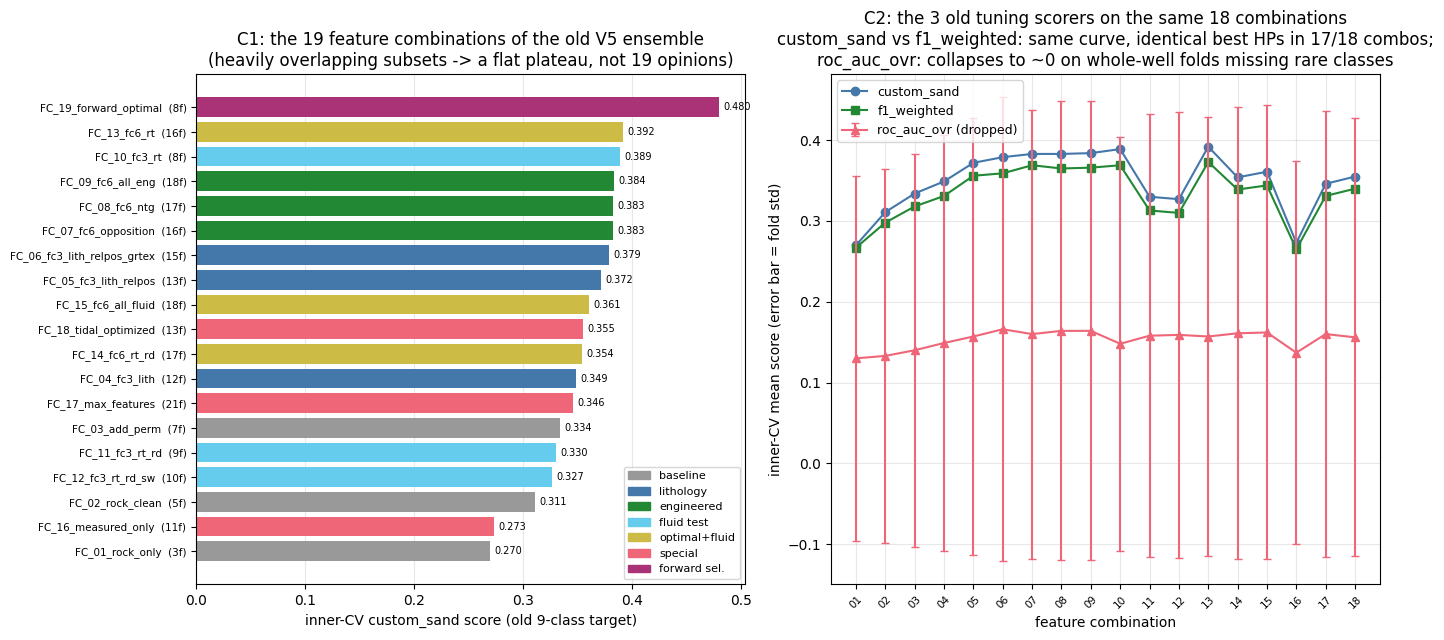

custom_sand and f1_weighted selected identical hyperparameters in 17/18 combinations (94%).
roc_auc_ovr inner-CV scores: mean 0.13-0.17 with fold std 0.23-0.29 -> selection driven by noise.


In [ ]:
# C1/C2: the recorded evidence from the old 57-model run (V5, Python_v6).
# Source: v5_full_progressive/results/model_ranking.csv — 18 feature combinations (FC_01..FC_18)
# x 3 tuning scorers, GroupKFold by well on the 4 training wells, blind well F-4 held out.
# FC_19 (forward-selection winner, 0.480 custom_sand) is quoted from the same run's config record.
# Values are embedded here so the notebook stays self-contained.

# (combo, n_features, custom_sand, f1_weighted, roc_auc_ovr mean, roc_auc_ovr std, HP cs==f1, category)
C1_RECORD = [
    ("FC_01_rock_only",            3,  0.270, 0.267, 0.130, 0.226, True,  "baseline"),
    ("FC_02_rock_clean",           5,  0.311, 0.298, 0.133, 0.231, True,  "baseline"),
    ("FC_03_add_perm",             7,  0.334, 0.318, 0.140, 0.243, True,  "baseline"),
    ("FC_04_fc3_lith",            12,  0.349, 0.331, 0.149, 0.258, True,  "lithology"),
    ("FC_05_fc3_lith_relpos",     13,  0.372, 0.356, 0.157, 0.271, True,  "lithology"),
    ("FC_06_fc3_lith_relpos_grtex", 15, 0.379, 0.359, 0.166, 0.287, False, "lithology"),
    ("FC_07_fc6_opposition",      16,  0.383, 0.369, 0.160, 0.278, True,  "engineered"),
    ("FC_08_fc6_ntg",             17,  0.383, 0.365, 0.164, 0.284, True,  "engineered"),
    ("FC_09_fc6_all_eng",         18,  0.384, 0.366, 0.164, 0.284, True,  "engineered"),
    ("FC_10_fc3_rt",               8,  0.389, 0.369, 0.148, 0.256, True,  "fluid test"),
    ("FC_11_fc3_rt_rd",            9,  0.330, 0.313, 0.158, 0.274, True,  "fluid test"),
    ("FC_12_fc3_rt_rd_sw",        10,  0.327, 0.310, 0.159, 0.276, True,  "fluid test"),
    ("FC_13_fc6_rt",              16,  0.392, 0.373, 0.157, 0.272, True,  "optimal+fluid"),
    ("FC_14_fc6_rt_rd",           17,  0.354, 0.339, 0.161, 0.280, True,  "optimal+fluid"),
    ("FC_15_fc6_all_fluid",       18,  0.361, 0.344, 0.162, 0.281, True,  "optimal+fluid"),
    ("FC_16_measured_only",       11,  0.273, 0.265, 0.137, 0.237, True,  "special"),
    ("FC_17_max_features",        21,  0.346, 0.331, 0.160, 0.276, True,  "special"),
    ("FC_18_tidal_optimized",     13,  0.355, 0.340, 0.156, 0.271, True,  "special"),
    ("FC_19_forward_optimal",      8,  0.480, np.nan, np.nan, np.nan, None, "forward sel."),
]
c1 = pd.DataFrame(C1_RECORD, columns=["combo", "n_features", "custom_sand", "f1_weighted",
                                      "roc_auc_ovr", "roc_auc_ovr_std", "hp_agree", "category"])

CAT_COLOR = {"baseline": "#999999", "lithology": "#4477aa", "engineered": "#228833",
             "fluid test": "#66ccee", "optimal+fluid": "#ccbb44", "special": "#ee6677",
             "forward sel.": "#aa3377"}

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

# (1) C1: the 19 combinations and their recorded scores
ax = axes[0]
o = c1.sort_values("custom_sand")
ax.barh(range(len(o)), o["custom_sand"], color=[CAT_COLOR[c] for c in o["category"]])
ax.set_yticks(range(len(o)))
ax.set_yticklabels([f"{r.combo}  ({r.n_features}f)" for r in o.itertuples()], fontsize=7.5)
for i, v in enumerate(o["custom_sand"]):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=7)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in CAT_COLOR.values()]
ax.legend(handles, CAT_COLOR.keys(), fontsize=8, loc="lower right")
ax.set_xlabel("inner-CV custom_sand score (old 9-class target)")
ax.set_title("C1: the 19 feature combinations of the old V5 ensemble\n"
             "(heavily overlapping subsets -> a flat plateau, not 19 opinions)")
ax.grid(axis="x", alpha=0.3); ax.set_axisbelow(True)

# (2) C2: the three tuning scorers across the same combinations
ax = axes[1]
c2 = c1.dropna(subset=["roc_auc_ovr"]).reset_index(drop=True)
xx = np.arange(len(c2))
ax.plot(xx, c2["custom_sand"], "o-", color="#4477aa", label="custom_sand")
ax.plot(xx, c2["f1_weighted"], "s-", color="#228833", label="f1_weighted")
ax.errorbar(xx, c2["roc_auc_ovr"], yerr=c2["roc_auc_ovr_std"], fmt="^-", color="#ee6677",
            capsize=3, label="roc_auc_ovr (dropped)")
ax.set_xticks(xx); ax.set_xticklabels([c.split("_")[1] for c in c2["combo"]], fontsize=7.5, rotation=45)
ax.set_xlabel("feature combination"); ax.set_ylabel("inner-CV mean score (error bar = fold std)")
agree = int(c2["hp_agree"].sum())
ax.set_title("C2: the 3 old tuning scorers on the same 18 combinations\n"
             f"custom_sand vs f1_weighted: same curve, identical best HPs in {agree}/18 combos;\n"
             "roc_auc_ovr: collapses to ~0 on whole-well folds missing rare classes")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

print(f"custom_sand and f1_weighted selected identical hyperparameters in {agree}/18 combinations (94%).")
print("roc_auc_ovr inner-CV scores: mean 0.13-0.17 with fold std 0.23-0.29 -> selection driven by noise.")

## D. Feature ablations

### D1. Rank vs z-score normalization

**Question.** Why per-well rank normalization instead of the standard per-well z-score?

**Setup.** Main rotation, all else equal, only the normalization swapped. Run with 3 seeds; checked with nested per-fold selection (training wells only) and a McNemar paired test on pooled blind predictions.

**Headline from Step 4:** rank wins, 0.577 vs ~0.552 pooled facies acc, consistent across seeds; McNemar p ≈ 1×10⁻⁵; nested selection prefers rank in 3/5 folds. Rank is distribution-free, which matters for the ~log-normal resistivity and permeability curves.

**Result.** Already in Step 4 (table with the per-seed numbers). *(placeholder if fuller tables from the ledger are wanted here)*

### D2. Rejected feature variants

**Question.** What else was tried in the feature set and didn't survive?

Tried blind, all rejected (each ran the full main rotation, all else equal):

| Variant | Outcome |
|---|---|
| Centered context windows (instead of trailing) | −5 pp pooled facies acc |
| Extra ~4 m context scale (4th window) | no improvement  |
| Rolling-range (max−min) stats per window | no improvement |
| Serration features on more logs than GR | no improvement |


### D3. Depth-smoothing window

**Question.** The probability smoothing uses a centered 9-sample (~1.4 m) window. How was that chosen, and how much does smoothing contribute at all?

**Setup.** The Step 6 rotation keeps the *unsmoothed* blind probabilities per well, so the sweep below is decode-only: re-smooth the same cached probabilities with windows {1, 5, 9, 15, 21, 31, 61} (no smoothing up to ~9 m) and re-score. The window is applied to probabilities, never labels, so every variant stays leakage-free.

**Result (measured below).** The landscape has exactly the expected shape and is *flat near the top*: no smoothing 0.576, a broad plateau 0.579–0.582 for ~0.8–3 m windows with the maximum at the main pipeline's w=9 (0.582), then degradation once the window over-smooths thin beds (0.575 at ~4.6 m, 0.567 at ~9 m). Smoothing is worth ~+0.6 pp; the precise window barely matters within the bed-scale range, which is why w=9 (~1.4 m, a typical Hugin bed) was kept without further tuning.

 window  approx_m  facies_acc  tier_acc
      1       0.1      0.5762    0.6447
      5       0.8      0.5792    0.6468
      9       1.3      0.5820    0.6494
     15       2.2      0.5809    0.6483
     21       3.1      0.5816    0.6485
     31       4.6      0.5751    0.6410
     61       9.2      0.5668    0.6308


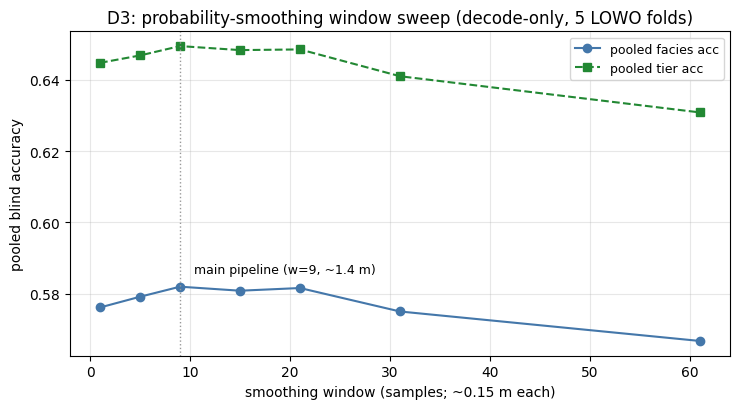

In [ ]:
# D3: depth-smoothing window sweep. Re-uses the raw (unsmoothed) blind probabilities
# cached by the Step 6 rotation, so no model is refit: only the decode step changes.
D3_WINDOWS = [1, 5, 9, 15, 21, 31, 61]

d3_rows = []
for w in D3_WINDOWS:
    yt, yp = [], []
    for well in LOGRICH:
        pw = per_well[well]
        proba = smooth(pw["proba_raw"], w) if w > 1 else pw["proba_raw"]
        yt.extend(pw["truth"]); yp.extend(pw["classes"][np.argmax(proba, axis=1)])
    yt, yp = np.array(yt), np.array(yp)
    d3_rows.append({"window": w, "approx_m": round(w * 0.15, 1),
                    "facies_acc": accuracy_score(yt, yp), "tier_acc": tier_acc(yt, yp)})
d3 = pd.DataFrame(d3_rows)
print(d3.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(d3["window"], d3["facies_acc"], "o-", color="#4477aa", label="pooled facies acc")
ax.plot(d3["window"], d3["tier_acc"], "s--", color="#228833", label="pooled tier acc")
ax.axvline(9, color="0.6", ls=":", lw=1)
ax.annotate("main pipeline (w=9, ~1.4 m)", (9, d3.loc[d3["window"] == 9, "facies_acc"].iloc[0]),
            textcoords="offset points", xytext=(10, 10), fontsize=9)
ax.set_xlabel("smoothing window (samples; ~0.15 m each)")
ax.set_ylabel("pooled blind accuracy")
ax.set_title("D3: probability-smoothing window sweep (decode-only, 5 LOWO folds)")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

## E. Validation and imbalance checks

### E1. Seal-recall knobs (rare-class trade-offs)

**Question.** Seal is ~4% of samples and under-detected (recall ~0.22, the "known weak spot" of the Summary). What was tried to fix it, and why is none of it enabled by default?

**Setup.** Two decode-level knobs, both originally documented in the v5 experiment ledger and re-measured below under the final configuration (rank normalization, RF-800). Both operate on the cached blind probabilities of Step 6, so the underlying model is untouched:

1. **Nested seal-probability threshold.** Multiply the seal column of the predicted probabilities by a factor from {1, 1.5, 2, 3, 5}, renormalize, smooth, argmax. The factor is chosen *per fold* on inner leave-one-train-well-out folds by macro-F1 — the blind well is never consulted, so the knob is leakage-free.
2. **HMM decoding.** Treat the facies column as a hidden Markov chain: transition matrix counted from the training wells' label sequences, emissions `p(y|x) / p(y)` (prior-corrected, because `class_weight="balanced"` already flattens the class prior inside the RF). Decoded two ways: Viterbi (best path) and forward–backward posterior.

**Result (measured below).** Under the final config the trade-off is:

| variant | facies acc | macro-F1 | seal recall | seal precision | pay↔seal err |
|---|---|---|---|---|---|
| baseline (smooth w9) | 0.582 | 0.501 | 0.221 | 0.413 | 0.042 |
| nested seal threshold | 0.580 | **0.510** | **0.338** | 0.319 | 0.053 |
| HMM Viterbi | 0.526 | 0.479 | **0.657** | 0.142 | 0.165 |
| HMM posterior | 0.509 | 0.462 | 0.652 | 0.143 | 0.163 |

**Verdict.** The nested threshold is the honest dial: +12 pp seal recall for −0.2 pp facies accuracy, and macro-F1 actually *improves* (0.501 → 0.510) — it stays off by default only because seal precision drops (0.41 → 0.32) and the critical pay↔seal error creeps up (4.2% → 5.3%). The HMM triples seal recall but collapses accuracy by ~6 pp and quadruples the catastrophic pay↔seal error: the transition matrix from 4 wells is too coarse a prior for a blind well with a different facies mix. If a use-case values catching seals over per-sample accuracy (e.g. cap-rock screening), enable the threshold knob; the HMM is not recommended.

fold 15_9-F-4: 4 inner fits done (20s)


fold 15_9-F-5: 4 inner fits done (38s)


fold 15_9-F-12: 4 inner fits done (57s)


fold 15_9-F-14: 4 inner fits done (76s)


fold 15_9-F-15_C: 4 inner fits done (100s)



              variant  facies_acc  tier_acc  macro_f1  seal_recall  seal_precision  payseal_err
 baseline (smooth w9)       0.582     0.649     0.501        0.221           0.413        0.042
nested seal threshold       0.580     0.646     0.510        0.338           0.319        0.053
          HMM Viterbi       0.526     0.584     0.479        0.657           0.142        0.165
        HMM posterior       0.509     0.575     0.462        0.652           0.143        0.163

nested seal factors chosen per fold: {'15_9-F-4': 1.0, '15_9-F-5': 1.5, '15_9-F-12': 2.0, '15_9-F-14': 1.5, '15_9-F-15_C': 2.0}


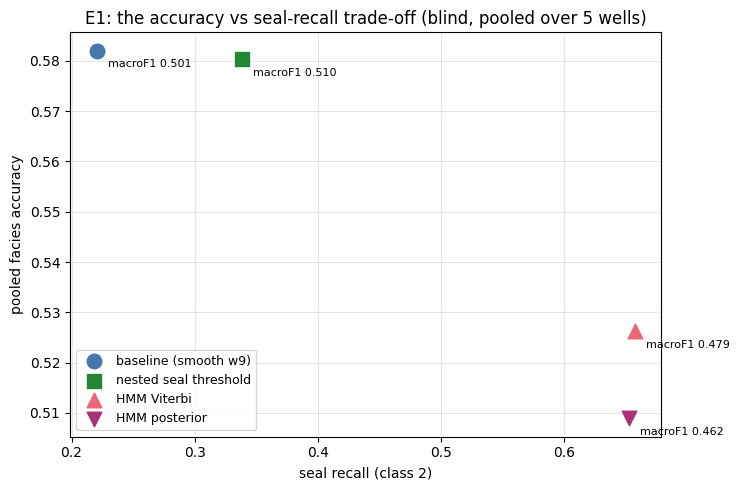

In [ ]:
# E1: seal-recall knobs, re-measured under the final config (rank features, RF-800).
# Step 6 cached the raw blind probabilities; here we additionally fit, per fold, the 4 inner
# leave-one-train-well-out models (20 extra RF fits, a few minutes) for the nested threshold.
import time as _time

SEAL_CLASS = 2
SI = CLASSES.index(SEAL_CLASS)
SEAL_FACTORS = (1.0, 1.5, 2.0, 3.0, 5.0)
_t0 = _time.time()

def _aligned(proba, classes):
    """Map predict_proba columns into the fixed CLASSES order."""
    out = np.zeros((proba.shape[0], len(CLASSES)))
    for j, c in enumerate(classes):
        out[:, CLASSES.index(c)] = proba[:, j]
    return out

def _fit_fold(train_wells, test_well):
    tr = df[WELL].isin(train_wells).values
    te = (df[WELL] == test_well).values
    valid = [c for c in FULL_COLS if X.loc[tr, c].nunique(dropna=True) >= 2]
    m = make_model()
    m.fit(np.asarray(X.loc[tr, valid]), y[tr])
    return _aligned(m.predict_proba(np.asarray(X.loc[te, valid])), m.steps[-1][1].classes_), y[te].values

e1_cache = {}
for blind in LOGRICH:
    train_wells = [w for w in LOGRICH if w != blind]
    inner = {}
    for held in train_wells:                                   # inner LOWO on the 4 training wells
        ip, it = _fit_fold([w for w in train_wells if w != held], held)
        inner[held] = {"proba": ip, "truth": it}
    e1_cache[blind] = {"proba": _aligned(per_well[blind]["proba_raw"], per_well[blind]["classes"]),
                       "truth": per_well[blind]["truth"], "inner": inner,
                       "train_labels": {w: y[(df[WELL] == w).values].values for w in train_wells}}
    print(f"fold {blind}: 4 inner fits done ({_time.time()-_t0:.0f}s)")

# ---------- decoders ----------

def _argmax_pred(proba):
    return np.array(CLASSES)[np.argmax(proba, axis=1)]

def _transition_matrix(label_seqs, alpha=1.0):
    k = len(CLASSES)
    ci = {c: i for i, c in enumerate(CLASSES)}
    T = np.full((k, k), alpha)                                  # Laplace smoothing
    for seq in label_seqs:
        a = np.array([ci[v] for v in seq])
        for i, j in zip(a[:-1], a[1:]):
            T[i, j] += 1
    return T / T.sum(axis=1, keepdims=True)

def _hmm_decode(proba, T, prior, mode="viterbi"):
    """Hybrid HMM: emission ~ p(y|x)/p(y) (prior-corrected, since the balanced RF
    already flattens the class prior)."""
    eps = 1e-12
    logB = np.log(proba + eps) - np.log(prior + eps)[None, :]
    logT = np.log(T + eps)
    n, k = proba.shape
    if mode == "viterbi":
        delta = np.log(prior + eps) + logB[0]
        psi = np.zeros((n, k), dtype=int)
        for t in range(1, n):
            m = delta[:, None] + logT
            psi[t] = np.argmax(m, axis=0)
            delta = m[psi[t], np.arange(k)] + logB[t]
        path = np.zeros(n, dtype=int)
        path[-1] = int(np.argmax(delta))
        for t in range(n - 2, -1, -1):
            path[t] = psi[t + 1][path[t + 1]]
        return np.array(CLASSES)[path]
    B = np.exp(logB - logB.max(axis=1, keepdims=True))          # forward-backward posterior
    alpha_f = np.zeros((n, k)); cnorm = np.zeros(n)
    alpha_f[0] = prior * B[0]; cnorm[0] = alpha_f[0].sum(); alpha_f[0] /= cnorm[0]
    for t in range(1, n):
        alpha_f[t] = (alpha_f[t - 1] @ T) * B[t]
        cnorm[t] = alpha_f[t].sum(); alpha_f[t] /= cnorm[t]
    beta = np.ones((n, k))
    for t in range(n - 2, -1, -1):
        beta[t] = (T @ (B[t + 1] * beta[t + 1])) / cnorm[t + 1]
    return np.array(CLASSES)[np.argmax(alpha_f * beta, axis=1)]

def _nested_seal_factor(dd):
    """Pick the seal multiplier on the inner folds only (macro-F1), never on the blind well."""
    best_f, best_v = 1.0, -1.0
    for f in SEAL_FACTORS:
        it, ip = [], []
        for held, inn in dd["inner"].items():
            p = inn["proba"].copy()
            p[:, SI] *= f
            p /= p.sum(axis=1, keepdims=True)
            it.append(inn["truth"]); ip.append(_argmax_pred(smooth(p)))
        v = f1_score(np.concatenate(it), np.concatenate(ip), average="macro", zero_division=0)
        if v > best_v:
            best_v, best_f = v, f
    return best_f

def _evaluate(decode_fn, tag):
    yt, yp = [], []
    for blind in LOGRICH:
        dd = e1_cache[blind]
        yt.append(dd["truth"]); yp.append(decode_fn(dd))
    yt, yp = np.concatenate(yt), np.concatenate(yp)
    er = economic_report(yt, yp)
    return {"variant": tag, "facies_acc": accuracy_score(yt, yp), "tier_acc": tier_acc(yt, yp),
            "macro_f1": er["macro_f1"], "seal_recall": er["seal_recall"],
            "seal_precision": er["seal_precision"], "payseal_err": er["critical_payseal_err"]}

e1_factors = {}
def _seal_decode(dd):
    f = _nested_seal_factor(dd)
    e1_factors[len(e1_factors)] = f
    p = dd["proba"].copy()
    p[:, SI] *= f
    p /= p.sum(axis=1, keepdims=True)
    return _argmax_pred(smooth(p))

def _make_hmm(mode):
    def f(dd):
        seqs = list(dd["train_labels"].values())
        T = _transition_matrix(seqs)
        prior = np.array([np.mean(np.concatenate(seqs) == c) for c in CLASSES])
        return _hmm_decode(dd["proba"], T, prior, mode=mode)
    return f

e1_out = pd.DataFrame([
    _evaluate(lambda dd: _argmax_pred(smooth(dd["proba"])), "baseline (smooth w9)"),
    _evaluate(_seal_decode, "nested seal threshold"),
    _evaluate(_make_hmm("viterbi"), "HMM Viterbi"),
    _evaluate(_make_hmm("posterior"), "HMM posterior"),
])
print()
print(e1_out.round(3).to_string(index=False))
print("\nnested seal factors chosen per fold:",
      {w: f for w, f in zip(LOGRICH, e1_factors.values())})

# ---------- accuracy vs seal-recall trade-off ----------
fig, ax = plt.subplots(figsize=(7.5, 5))
mk = {"baseline (smooth w9)": ("o", "#4477aa"), "nested seal threshold": ("s", "#228833"),
      "HMM Viterbi": ("^", "#ee6677"), "HMM posterior": ("v", "#aa3377")}
for _, r in e1_out.iterrows():
    m, c = mk[r["variant"]]
    ax.scatter(r["seal_recall"], r["facies_acc"], marker=m, s=110, color=c, zorder=3, label=r["variant"])
    ax.annotate(f"macroF1 {r['macro_f1']:.3f}", (r["seal_recall"], r["facies_acc"]),
                textcoords="offset points", xytext=(8, -12), fontsize=8)
ax.set_xlabel("seal recall (class 2)"); ax.set_ylabel("pooled facies accuracy")
ax.set_title("E1: the accuracy vs seal-recall trade-off (blind, pooled over 5 wells)")
ax.grid(alpha=0.3); ax.legend(fontsize=9, loc="lower left")
fig.tight_layout(); plt.show()

## References

- **Kieft, R.L., Jackson, C.A.-L., Hampson, G.J. & Larsen, E. (2011).** *Sedimentology and sequence stratigraphy of the Hugin Formation, Quadrant 15, Norwegian sector, South Viking Graben.* In: Vining, B.A. & Pickering, S.C. (eds) *Petroleum Geology: From Mature Basins to New Frontiers. Proceedings of the 7th Petroleum Geology Conference.* Geological Society, London, Petroleum Geology Conference Series, **7**, 157–176.

  This is the source of the Hugin Formation (Volve) facies scheme and the diagnostic log motifs used throughout this notebook: tide-dominated transgressive facies (tidal channels, tidal bars, tidal flats) and wave-/river-dominated regressive facies (prograding mouthbars, shoreface), with offshore mudstones as the distal/seal component. The Equinor facies labels and our merge groupings map directly onto Kieft et al.'s facies associations.